<div style="border-left: 4px solid #b8953a; padding: 18px 24px; margin-bottom: 8px; background: #fffdf5;">
<p style="margin:0 0 4px 0; font-size:11px; letter-spacing:2px; color:#b8953a; text-transform:uppercase;">Research Paper · Quantitative Finance</p>
<h1 style="margin:0 0 6px 0; font-size:28px; font-weight:700; color:#1a1a1a; font-family:Georgia,serif;">
  Gold Price Direction Prediction via Deep Learning Ensembles
</h1>
<p style="margin:0; font-size:14px; color:#555; font-family:Georgia,serif; font-style:italic;">
  Multi-scale temporal fusion · NLP sentiment · Conformal prediction intervals · Walk-forward validation
</p>
</div>


<div style="border-left: 3px solid #ddd; padding: 12px 20px; margin: 4px 0; background:#fafafa;">
<p style="margin:0 0 6px 0; font-size:10px; letter-spacing:2px; color:#999; text-transform:uppercase;">Abstract</p>
<p style="margin:0; font-size:13.5px; line-height:1.7; color:#333; font-family:Georgia,serif;">
This paper presents a high-capacity deep learning ensemble without PCA for daily gold log-return prediction.
Four architectures are compared — TFT-Lite, Residual-LSTM, a Temporal Convolutional Transformer (TCT),
and a Multi-Scale Fusion (MSF) network that jointly processes 10 / 40 / 80-day lookback windows.
Models are trained through walk-forward validation with a runtime-conscious configuration.
Sentiment is derived from FinBERT/VADER-scored gold news with a market-proxy fallback.
Feature selection uses a correlation → VIF → MI+RF pipeline without PCA for controlled comparison.
Prediction intervals are calibrated via split conformal inference.
Final ensemble weights are conditioned on the HMM-detected market regime (ARCE), and a lightweight validation section tests feature-group and HMM hypotheses.
</p>
</div>


---
### Contents

| § | Topic | Innovation |
|---|-------|-----------|
| 1 | Environment Setup | — |
| 2 | Data Acquisition & Caching | — |
| 3 | NLP News Sentiment | FinBERT/VADER + proxy fallback |
| 4 | Wavelet Denoising | — |
| 5 | Feature Engineering | Broad technical, macro, cross-asset, and behavioral feature set |
| 6 | Market Regime Detection | Train-only HMM + K-Means fallback |
| 7 | Custom Loss Functions | Directional Huber and auxiliary sign-aware losses |
| 8 | Model Architectures | CNN/RNN · TCT · MSF · Transformer-inspired models |
| 9 | Training Utilities | Early stopping and reduce-on-plateau callbacks |
| 10 | Feature Selection | Corr → VIF → MI+RF |
| 11 | Walk-Forward Training | 3-fold expanding-window validation |
| 12 | Prediction & ARCE Ensemble | Regime-conditioned weights |
| 13 | Conformal Prediction Intervals | Split conformal prediction intervals |
| 14 | Evaluation & Results | Performance + trading metrics |
| 15 | Lightweight Hypothesis Validation | G1/G2/G3 + HMM ablation |
| 16 | Statistical Tests & Backtest | DM · PT · binomial · Sharpe · Calmar |
| 17 | Final Discussion | Final interpretation |

---


## §1 · Environment Setup

Install required packages if running for the first time.

In [1]:
# Install dependencies (run once)
#!pip install pyarrow fastparquet
#import sys
#!{sys.executable} -m pip install pyarrow fastparquet
#print(sys.executable)

Core scientific, ML, and Keras imports, plus FinBERT tokeniser.

In [2]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import warnings, os, json, time
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.dates     as mdates
import matplotlib.gridspec  as gridspec
import pywt
import yfinance             as yf
import requests

from datetime               import date, datetime
from hmmlearn.hmm           import GaussianHMM
from sklearn.preprocessing  import StandardScaler, RobustScaler
from sklearn.metrics        import (mean_squared_error,
                                    mean_absolute_error, r2_score)
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble       import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster        import KMeans
from sklearn.linear_model   import Ridge
from statsmodels.stats.outliers_influence import variance_inflation_factor
import ta

import tensorflow as tf
from tensorflow.keras.models     import Model
from tensorflow.keras.layers     import (
    LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, AveragePooling1D,
    Bidirectional, Input, MultiHeadAttention,
    LayerNormalization, BatchNormalization, Add, Multiply,
    Lambda, Flatten, Concatenate, Activation, GlobalAveragePooling1D,
    SeparableConv1D
)
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks  import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, LearningRateScheduler
)
import tensorflow.keras.backend as K

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── NLP / News Sentiment Imports ─────────────────────────────────────────────
# Install: pip install transformers torch vaderSentiment newsapi-python feedparser
# Lightweight fallback (no GPU needed): VADER + FinBERT headline scoring

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    VADER_OK = True
except ImportError:
    VADER_OK = False
    print("[NLP] vaderSentiment not installed — will use proxy only")

try:
    from transformers import pipeline as hf_pipeline
    FINBERT_OK = True
except ImportError:
    FINBERT_OK = False
    print("[NLP] transformers not installed — FinBERT disabled")

try:
    import feedparser          # RSS feed parser (stdlib-like, very lightweight)
    FEEDPARSER_OK = True
except ImportError:
    FEEDPARSER_OK = False
    print("[NLP] feedparser not installed — RSS scraping disabled")

In [3]:
print("all aviable device:", tf.config.list_physical_devices())
gpu_devices = tf.config.list_physical_devices('GPU')
print("number of GPU:", len(gpu_devices))



all aviable device: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
number of GPU: 1


---
## §2 · Global Configuration

All hyperparameters and date ranges are defined in one place for reproducibility.


In [4]:
# ── GLOBAL CONFIG ─────────────────────────────────────────────────────────────
from pickle import TRUE
START_DATE   = "2007-01-01"   # reduced from 2000 → faster training
END_DATE     = "2026-05-30"   # fixed for reproducibility in final submission
LOOKBACK     = 60              # high-capacity comparison: longer history window
LOOKBACKS    = [20, 60, 120]   # high-capacity MSF horizons
HORIZON      = 1
TRAIN_FRAC   = 0.70
VAL_FRAC     = 0.15
FAST_RUN     = False        # set True for smoke testing only
EPOCHS       = 40
BATCH_SIZE   = 64
TOP_K        = 40
N_REGIMES    = 3
CONFORMAL_ALPHA = 0.10         # 90% prediction intervals
N_SPLITS_WF  = 3
D_MODEL = 64                 # projection dimension for Informer/Autoformer candidates
N_HEADS = 4                  # attention heads for Informer/Autoformer candidates
USE_MIXED_PRECISION = True     # float16 compute, float32 outputs/weights where needed
STRICT_REQUIRED_INPUTS = True         # fail fast if required macro/behavioral inputs cannot be loaded

if FAST_RUN:
    EPOCHS = 2
    N_SPLITS_WF = 1
    TOP_K = 15
    LOOKBACK = 20
    LOOKBACKS = [10, 20]
    print("[Config] FAST_RUN=True — using short smoke-test settings")

# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Mixed precision (must be set before any model is built) ───────────────────
if USE_MIXED_PRECISION:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("[Config] Mixed precision: float16 compute / float32 outputs")

print(f"Pipeline  : {START_DATE}  →  {END_DATE}")
print(f"TensorFlow: {tf.__version__}")
print(f"Settings  : LOOKBACK={LOOKBACK}  LOOKBACKS={LOOKBACKS}  EPOCHS={EPOCHS}  BATCH={BATCH_SIZE}  SPLITS={N_SPLITS_WF}")


[Config] Mixed precision: float16 compute / float32 outputs
Pipeline  : 2007-01-01  →  2026-05-30
TensorFlow: 2.18.0
Settings  : LOOKBACK=60  LOOKBACKS=[20, 60, 120]  EPOCHS=40  BATCH=64  SPLITS=3


---
## §3 · Data Acquisition

Downloads daily OHLCV and cross-asset market data for gold, silver, oil,
S&P 500, VIX, USD index, treasuries, copper, commodity ETFs, mining equities,
and FX proxies via `yfinance`. It also loads official macro, geopolitical risk,
positioning, and reserve-related inputs with publication-lag handling where
needed. Market data are cached locally as pickle/parquet-compatible files to
avoid redundant API calls on reruns.


In [5]:
# ==============================================================================
# SECTION 1 — DATA ACQUISITION
# ==============================================================================

def fetch_ticker(ticker, col='Close', rename=None):
    raw = yf.download(ticker, start=START_DATE, end=END_DATE,
                      auto_adjust=True, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = ['_'.join(c).strip() for c in raw.columns]
        matched = [c for c in raw.columns if col in c]
        if not matched:
            raise KeyError(f"'{col}' not found in {raw.columns.tolist()}")
        raw = raw[[matched[0]]].rename(columns={matched[0]: rename or matched[0]})
    else:
        raw = raw[[col]].rename(columns={col: rename or col})
    return raw


def download_market_data():
    """Download all market data with robust error handling."""
    tickers = {
        'Gold_Close'  : ('GC=F',     'Close'),
        'USD_Index'   : ('DX-Y.NYB', 'Close'),
        'SP500'       : ('^GSPC',    'Close'),
        'SP500_Volume': ('^GSPC',    'Volume'),
        'VIX'         : ('^VIX',     'Close'),
        'Silver'      : ('SI=F',     'Close'),
        'Oil_WTI'     : ('CL=F',     'Close'),
        'Treasury_10Y': ('^TNX',     'Close'),
        'Copper'      : ('HG=F',     'Close'),   # NEW: copper-gold ratio
        'TIP'         : ('TIP',      'Close'),   # NEW: TIPS for real rates
        'DBC'         : ('DBC',      'Close'),   # NEW: commodity basket
        'GDX'         : ('GDX',      'Close'),   # NEW: gold miners ETF
        'EURUSD'      : ('EURUSD=X', 'Close'),   # EUR/USD
        'USDJPY'      : ('JPY=X',    'Close'),   # safe-haven JPY
        'Gold_Volume' : ('GC=F',     'Volume'),  # Gold futures volume for MFI
        'USDBRL'      : ('BRL=X',    'Close'),   # EM stress proxy
    }
    df = None
    for name, (ticker, col) in tickers.items():
        try:
            series = fetch_ticker(ticker, col, name)
            df = series if df is None else df.join(series, how='left')
        except Exception as e:
            print(f"  [WARN] {ticker} failed: {e}")

    df.dropna(subset=['Gold_Close'], inplace=True)
    # cap forward-fill at 5 days so stale values don't propagate indefinitely
    df.ffill(limit=5, inplace=True)
    df.bfill(limit=5, inplace=True)
    # futures roll-gap flag: daily |return| > 3σ rolling = likely roll artefact
    _gc_lr = np.log(df['Gold_Close'] / df['Gold_Close'].shift(1))
    _roll_thresh = _gc_lr.abs().rolling(63, min_periods=20).mean() + \
                   3 * _gc_lr.abs().rolling(63, min_periods=20).std()
    df['Gold_Roll_Gap'] = (_gc_lr.abs() > _roll_thresh).astype(int).fillna(0)
    n_rolls = int(df['Gold_Roll_Gap'].sum())
    print(f"[Data] {df.shape}  |  {df.index[0].date()} → {df.index[-1].date()}  "
          f"|  roll gaps flagged={n_rolls}")
    return df



# ── Cache for fast reruns ────────────────────────────────────────────────────
_CACHE_FILE = 'market_data_cache.parquet'
_CACHE_FALLBACK_FILE = 'market_data_cache.pkl'

def _read_market_cache(path):
    """Read cache with parquet first; fall back cleanly when pyarrow is unavailable."""
    if path.endswith('.parquet'):
        return pd.read_parquet(path)
    return pd.read_pickle(path)

def _write_market_cache(df, path):
    """Write parquet when supported; otherwise use pickle so reruns still work."""
    try:
        df.to_parquet(path)
        print(f"[Cache] Saved -> {path}")
        return path
    except ImportError as e:
        df.to_pickle(_CACHE_FALLBACK_FILE)
        print(f"[Cache] Parquet unavailable ({e.__class__.__name__}) -> saved -> {_CACHE_FALLBACK_FILE}")
        return _CACHE_FALLBACK_FILE


def download_market_data_cached(max_age_days: int = 1) -> pd.DataFrame:
    """
    Wraps download_market_data() with a local cache.
    Re-downloads only when the cache is older than max_age_days.
    Delete the cache files to force a full refresh.
    """
    for cache_path in [_CACHE_FILE, _CACHE_FALLBACK_FILE]:
        if not os.path.exists(cache_path):
            continue
        mtime = pd.Timestamp(os.path.getmtime(cache_path), unit='s', tz='UTC')
        age = (pd.Timestamp.utcnow() - mtime).total_seconds() / 86400
        if age >= max_age_days:
            print(f"[Cache] Stale {cache_path} ({age:.1f}d > {max_age_days}d) — re-downloading")
            continue
        try:
            df_cached = _read_market_cache(cache_path)
            print(f"[Cache] Loaded from {cache_path}  (age={age:.1f}d  shape={df_cached.shape})")
            return df_cached
        except ImportError as e:
            print(f"[Cache] Cannot read {cache_path} ({e.__class__.__name__}) — trying fallback/re-download")
        except Exception as e:
            print(f"[Cache] Failed to read {cache_path} ({e}) — trying fallback/re-download")

    df_fresh = download_market_data()
    _write_market_cache(df_fresh, _CACHE_FILE)
    return df_fresh

def fetch_fed_rate(df_index):
    url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=FEDFUNDS"
    try:
        fed = pd.read_csv(url, index_col=0, parse_dates=True)
        fed.columns = ['Fed_Rate']
        return fed[fed.index >= START_DATE].resample('B').ffill()
    except Exception as e:
        print(f"[FRED] failed ({e}) → using 0.")
        return pd.DataFrame({'Fed_Rate': 0.0}, index=df_index)


def fetch_cpi(df_index):
    """Fetch CPI inflation from FRED — critical for gold's inflation-hedge role."""
    url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"
    try:
        cpi = pd.read_csv(url, index_col=0, parse_dates=True)
        cpi.columns = ['CPI']
        cpi = cpi[cpi.index >= START_DATE].resample('B').ffill()
        cpi['CPI_YoY'] = cpi['CPI'].pct_change(252)
        return cpi
    except Exception as e:
        print(f"[CPI] failed ({e}) → using 0.")
        return pd.DataFrame({'CPI': 100.0, 'CPI_YoY': 0.0}, index=df_index)

# ── Official macro / behavioral data sources with publication lags ─────────────
def fetch_fred_lagged(series_id, col_name, df_index, freq='B', lag_days=0, fill_value=0.0):
    """Fetch FRED data via public CSV and shift publication date forward to avoid lookahead."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    try:
        series = pd.read_csv(url, index_col=0, parse_dates=True)
        series.columns = [col_name]
        series[col_name] = pd.to_numeric(series[col_name], errors='coerce')
        series.dropna(subset=[col_name], inplace=True)
        if lag_days > 0:
            series.index = series.index + pd.Timedelta(days=lag_days)
        series = series[series.index >= START_DATE].resample(freq).ffill()
        return series.reindex(df_index, method='ffill')
    except Exception as e:
        msg = f"[FRED] {series_id} failed while loading required input {col_name}: {e}"
        if STRICT_REQUIRED_INPUTS:
            raise RuntimeError(msg) from e
        print(msg + f" -> using {fill_value}")
        return pd.DataFrame({col_name: fill_value}, index=df_index)


def fetch_required_fred_macro(df_index):
    """Load official FRED macro inputs with publication lags."""
    fred_series = {
        'FEDFUNDS':        ('Fed_Rate',            30, 0.0),
        'DFII10':          ('TIPS_Real_Yield',      1, 0.0),
        'T10YIE':          ('Breakeven_Inflation',  1, 0.0),
        'CPIAUCSL':        ('CPI',                 45, 100.0),
        'M2SL':            ('M2',                  30, 0.0),
        'BAA10Y':          ('HY_Spread',            1, 0.0),
        'STLFSI4':         ('Financial_Stress',     7, 0.0),
        'WUIGLOBALSMPAVG': ('WUI',                 90, 0.0),
    }
    out = pd.DataFrame(index=df_index)
    for fred_id, (col_name, lag, fill_value) in fred_series.items():
        result = fetch_fred_lagged(fred_id, col_name, df_index, lag_days=lag, fill_value=fill_value)
        out = out.join(result, how='left')
        out[col_name] = out[col_name].ffill().fillna(fill_value)
    print(f"[FRED] restored lagged macro series: {list(out.columns)}")
    return out


def fetch_real_gpr(df_index):
    """Restore Caldara-Iacoviello GPR/GPRA/GPRT data with a 30-day publication lag."""
    url = 'https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls'
    try:
        print("[GPR] Fetching real GPR index...")
        gpr_raw = pd.read_excel(url, parse_dates=['month'], index_col='month')
        gpr = gpr_raw[['GPR', 'GPRA', 'GPRT']].copy()
        gpr.index = gpr.index + pd.Timedelta(days=30)
        gpr_daily = gpr[gpr.index >= START_DATE].resample('B').ffill()
        return gpr_daily.reindex(df_index, method='ffill').fillna(0.0)
    except Exception as e:
        msg = f"[GPR] failed while loading required real GPR data: {e}"
        if STRICT_REQUIRED_INPUTS:
            raise RuntimeError(msg) from e
        print(msg + " -> using 0")
        return pd.DataFrame({'GPR': 0.0, 'GPRA': 0.0, 'GPRT': 0.0}, index=df_index)


def load_cot(df_index):
    """Restore COT gold positioning data. Tuesday as-of data is published Friday: +3 days."""
    try:
        print("[COT] Loading cot_gold.csv...")
        if not os.path.exists('cot_gold.csv'):
            raise FileNotFoundError('cot_gold.csv not found')
        cot = pd.read_csv('cot_gold.csv', parse_dates=['Date'], index_col='Date')
        cot = cot[~cot.index.duplicated(keep='last')]
        cot.index = cot.index + pd.Timedelta(days=3)
        cot_daily = cot[cot.index >= START_DATE].resample('B').ffill()
        cols = ['COT_Open_Interest', 'COT_NetSpec']
        return cot_daily.reindex(df_index, method='ffill')[cols].fillna(0.0)
    except Exception as e:
        msg = f"[COT] failed while loading required COT data: {e}"
        if STRICT_REQUIRED_INPUTS:
            raise RuntimeError(msg) from e
        print(msg + " -> using 0")
        return pd.DataFrame({'COT_Open_Interest': 0.0, 'COT_NetSpec': 0.0}, index=df_index)


def load_wgc(df_index):
    """Restore WGC central-bank reserves with a 3-month publication lag."""
    try:
        from pandas.tseries.offsets import MonthEnd, DateOffset
        print("[WGC] Loading WGC_Central_Bank_Reserves.csv...")
        if not os.path.exists('WGC_Central_Bank_Reserves.csv'):
            raise FileNotFoundError('WGC_Central_Bank_Reserves.csv not found')
        df_wgc = pd.read_csv('WGC_Central_Bank_Reserves.csv', header=0)
        df_wgc.replace('AWAITED', np.nan, inplace=True)
        df_wgc.set_index('Country', inplace=True)
        df_wgc = df_wgc.apply(pd.to_numeric, errors='coerce')
        threshold = df_wgc.shape[1] * 0.5
        df_wgc.dropna(thresh=threshold, inplace=True)
        df_wgc.ffill(axis=1, inplace=True)
        df_wgc.fillna(0, inplace=True)
        total_reserves = df_wgc.sum(axis=0)
        wgc = pd.DataFrame({'Total_CB_Reserves': total_reserves})
        def parse_quarter(q_str):
            q, yr = q_str.split(' ')
            year = int(yr) + 2000 if int(yr) < 50 else int(yr) + 1900
            month = int(q[1]) * 3
            return pd.to_datetime(f"{year}-{month:02d}-01") + MonthEnd(1)
        wgc.index = wgc.index.map(parse_quarter)
        wgc = wgc.sort_index()
        wgc.index = wgc.index + DateOffset(months=3)
        wgc_daily = wgc[wgc.index >= START_DATE].resample('B').ffill()
        return wgc_daily.reindex(df_index, method='ffill').fillna(0.0)
    except Exception as e:
        msg = f"[WGC] failed while loading required WGC reserves data: {e}"
        if STRICT_REQUIRED_INPUTS:
            raise RuntimeError(msg) from e
        print(msg + " -> using 0")
        return pd.DataFrame({'Total_CB_Reserves': 0.0}, index=df_index)


def integrate_required_data_sources(df):
    """Join official macro, real GPR, COT positioning, and WGC reserves into the feature set."""
    df = df.copy()
    print("[Data] Loading official macro + behavioral inputs...")
    for extra in [fetch_required_fred_macro(df.index), fetch_real_gpr(df.index), load_cot(df.index), load_wgc(df.index)]:
        overlap = [c for c in extra.columns if c in df.columns]
        if overlap:
            df.drop(columns=overlap, inplace=True)
        df = df.join(extra, how='left')
    required_input_cols = ['Fed_Rate', 'TIPS_Real_Yield', 'Breakeven_Inflation', 'CPI', 'M2',
               'HY_Spread', 'Financial_Stress', 'WUI', 'GPR', 'GPRA', 'GPRT',
               'COT_Open_Interest', 'COT_NetSpec', 'Total_CB_Reserves']
    for col in required_input_cols:
        if col in df.columns:
            fill_value = 100.0 if col == 'CPI' else 0.0
            df[col] = df[col].ffill().fillna(fill_value)
    print(f"[Data] restored columns available: {[c for c in required_input_cols if c in df.columns]}")
    return df


---
## §4 · NLP News Sentiment  ★

**Primary source:** RSS gold-news headlines scored by FinBERT (`ProsusAI/finbert`).  
**Fallback:** For dates with no news coverage, a GPR proxy (VIX + gold/SP500 decoupling + USD) fills the gap.  
Sentiment is mapped to a 0–100 scale (`50 + 50 × (P_pos − P_neg)`) matching the Fear & Greed convention.  
Set `NEWS_API_KEY = "your_key"` — free registration at newsapi.org.


### 4.1 · FinBERT Model Loader

In [6]:
# ==============================================================================
# SECTION 2b — NLP NEWS SENTIMENT  [RESEARCH INNOVATION: News Sentiment]
# ==============================================================================
#
# Architecture
# ─────────────
#  1. Headline Collection  — three free RSS feeds (Reuters, Kitco, MarketWatch)
#     scraped via feedparser; no API key required.
#  2. Scoring             — FinBERT (financial BERT, 3-class POS/NEG/NEU) with
#     graceful fallback to VADER when transformers is unavailable.
#  3. Daily Aggregation   — mean compound score per calendar day.
#  4. Proxy Imputation    — for days with NO headlines (weekends, API outages):
#       (a) forward-fill ≤ 3 days  (recent news still relevant)
#       (b) exponential-decay weighted average of the last 5 available scores
#           with half-life = 2 days — models fading news impact.
#       (c) fallback to VIX-derived synthetic score if no history exists.
#  5. Derived Features    — MA5, MA20, momentum, Z-score, divergence vs gold.
# ==============================================================================

# ── RSS Feed Catalogue ───────────────────────────────────────────────────────
GOLD_RSS_FEEDS = [
    "https://feeds.reuters.com/reuters/businessNews",         # Reuters Business
    "https://www.kitco.com/rss/kitconews.xml",                # Kitco Gold News
    "https://feeds.marketwatch.com/marketwatch/topstories",   # MarketWatch
    "https://www.investing.com/rss/news_301.rss",             # Investing.com Commodities
]

GOLD_KEYWORDS = [
    "gold", "silver", "precious metal", "bullion", "XAU",
    "inflation", "fed rate", "federal reserve", "dollar", "safe haven",
    "geopolitical", "recession", "commodity",
]


# ── FinBERT / VADER Scoring ──────────────────────────────────────────────────
_finbert_pipe = None   # lazy-load — only initialised on first call

def _get_finbert():
    """Lazy-load FinBERT sentiment pipeline (downloads ~440 MB on first run)."""
    global _finbert_pipe
    if _finbert_pipe is None and FINBERT_OK:
        try:
            _finbert_pipe = hf_pipeline(
                "text-classification",
                model="ProsusAI/finbert",
                tokenizer="ProsusAI/finbert",
                device=-1,           # CPU; set to 0 for GPU
                truncation=True,
                max_length=128,
            )
            print("[NLP] FinBERT loaded")
        except Exception as e:
            print(f"[NLP] FinBERT load failed ({e}) — falling back to VADER")
    return _finbert_pipe


def score_headline(text: str) -> float:
    """
    Score a single headline → float in [-1, +1].
    Positive = bullish for gold/markets; Negative = bearish.

    Priority:
      1. FinBERT  — financial-domain BERT, 3 classes (positive/negative/neutral)
      2. VADER    — rule-based, fast, no model download required
      3. 0.0      — neutral fallback
    """
    if not text or not isinstance(text, str):
        return 0.0

    pipe = _get_finbert()
    if pipe is not None:
        try:
            result = pipe(text[:512])[0]
            label, score = result["label"].lower(), result["score"]
            if label == "positive":
                return  score
            elif label == "negative":
                return -score
            else:
                return 0.0
        except Exception:
            pass   # fall through to VADER

    if VADER_OK:
        analyzer = SentimentIntensityAnalyzer()
        return analyzer.polarity_scores(text)["compound"]   # already in [-1, 1]

    return 0.0   # neutral if no scorer available


def _is_gold_relevant(title: str, summary: str = "") -> bool:
    """Keep only headlines containing at least one gold-related keyword."""
    combined = (title + " " + summary).lower()
    return any(kw in combined for kw in GOLD_KEYWORDS)


# ── Headline Scraping (RSS — free, no API key) ───────────────────────────────
def scrape_rss_headlines(max_per_feed: int = 50) -> pd.DataFrame:
    """
    Scrape headlines from RSS feeds defined in GOLD_RSS_FEEDS.
    Returns DataFrame with columns: [date, title, score].
    Falls back gracefully if feedparser is unavailable or a feed is unreachable.
    """
    if not FEEDPARSER_OK:
        print("[NLP] feedparser unavailable — skipping RSS scraping")
        return pd.DataFrame(columns=["date", "title", "score"])

    rows = []
    for feed_url in GOLD_RSS_FEEDS:
        try:
            feed = feedparser.parse(feed_url)
            for entry in feed.entries[:max_per_feed]:
                title   = getattr(entry, "title",   "")
                summary = getattr(entry, "summary", "")
                if not _is_gold_relevant(title, summary):
                    continue
                # Parse date — feedparser normalises to time.struct_time
                pub = getattr(entry, "published_parsed", None)
                if pub is None:
                    pub = getattr(entry, "updated_parsed", None)
                if pub is None:
                    continue
                dt = pd.Timestamp(*pub[:6]).normalize()
                sc = score_headline(title + ". " + summary[:200])
                rows.append({"date": dt, "title": title, "score": sc})
        except Exception as e:
            print(f"[NLP] RSS feed failed ({feed_url[:40]}...): {e}")

    df_news = pd.DataFrame(rows)
    if df_news.empty:
        print("[NLP] No headlines scraped from RSS feeds")
    else:
        print(f"[NLP] Scraped {len(df_news)} gold-relevant headlines from RSS")
    return df_news


# ── Daily Aggregation ─────────────────────────────────────────────────────────
def aggregate_daily_sentiment(df_news: pd.DataFrame) -> pd.Series:
    """
    Aggregate headline-level scores to a daily score in [-1, +1].
    Uses winsorised mean (±2σ) to reduce outlier headlines.
    """
    if df_news.empty:
        return (pd.Series(dtype=float, name="NLP_Sentiment_Raw"),
                pd.Series(dtype=int,   name="NLP_Headline_Count"))

    df_news = df_news.copy()
    df_news["date"] = pd.to_datetime(df_news["date"]).dt.normalize()

    def winsorised_mean(x):
        arr  = np.array(x, dtype=float)
        mu, sigma = arr.mean(), arr.std()
        if sigma > 0:
            arr = arr.clip(mu - 2*sigma, mu + 2*sigma)
        return arr.mean()

    daily = (
        df_news.groupby("date")["score"]
        .apply(winsorised_mean)
        .rename("NLP_Sentiment_Raw")
    )
    # Also return daily headline counts as a separate series
    daily_count = df_news.groupby("date")["score"].count().rename("NLP_Headline_Count")
    print(f"[NLP] Daily scores: {len(daily)} days  "
          f"| mean={daily.mean():.3f}  std={daily.std():.3f}  "
          f"| max_headlines/day={daily_count.max() if not daily_count.empty else 0}")
    return daily, daily_count


# ── Proxy Imputation for Missing Days ─────────────────────────────────────────
def impute_missing_sentiment(
    nlp_series: pd.Series,
    df_main: pd.DataFrame,
    ffill_limit: int = 3,
    decay_halflife: float = 2.0,
    decay_window: int = 5,
) -> pd.Series:
    """
    Impute missing NLP sentiment for days with no headlines.

    Strategy (applied in priority order):
      1. Forward-fill ≤ ffill_limit consecutive missing days.
         Rationale: yesterday's news is still relevant today.
      2. Exponential-decay weighted average of the last `decay_window`
         available scores. Weight w_k = exp(-k * ln(2) / halflife)
         where k=0 is most recent. Captures fading news impact.
      3. VIX-derived synthetic proxy for dates with no prior NLP history.
         Formula: synthetic = -tanh(VIX_Z / 2) * 0.3
         (high VIX → negative sentiment for markets → gold bullish)

    Parameters
    ----------
    nlp_series   : pd.Series indexed by date, values in [-1, 1]
    df_main      : main price DataFrame (must contain 'VIX' column)
    ffill_limit  : max consecutive days to forward-fill
    decay_halflife : half-life in days for exponential decay
    decay_window  : number of past days used in decay imputation
    """
    # Reindex to main DataFrame's business-day index
    sent = nlp_series.reindex(df_main.index)

    # ── Pass 1: Forward-fill short gaps ──────────────────────────────
    sent_ff = sent.ffill(limit=ffill_limit)

    # ── Pass 2: Exponential-decay weighted average ────────────────────
    decay_weights = np.array([
        np.exp(-k * np.log(2) / decay_halflife) for k in range(decay_window)
    ])

    sent_decay = sent_ff.copy()
    still_missing = sent_decay.isna()

    for idx in sent_decay.index[still_missing]:
        # Gather the last `decay_window` non-NaN values before `idx`
        past = sent.loc[:idx].dropna().tail(decay_window)
        if len(past) == 0:
            continue   # handled by Pass 3
        w = decay_weights[:len(past)][::-1]   # most recent gets highest weight
        sent_decay.loc[idx] = float(np.average(past.values, weights=w / w.sum()))

    # ── Pass 3: VIX-derived synthetic proxy for truly empty regions ───
    still_missing = sent_decay.isna()
    if still_missing.any() and "VIX" in df_main.columns:
        vix_z = (
            (df_main["VIX"] - df_main["VIX"].rolling(63, min_periods=10).mean())
            / df_main["VIX"].rolling(63, min_periods=10).std().clip(1e-3)
        )
        # High VIX → fear → negative equity sentiment (gold tends to rise)
        synthetic = (-np.tanh(vix_z / 2) * 0.3).clip(-1, 1)
        sent_decay = sent_decay.fillna(synthetic)
        n_synthetic = still_missing.sum()
        print(f"[NLP] Pass 3: VIX synthetic proxy filled {n_synthetic} dates")

    coverage = sent_decay.notna().mean()
    print(f"[NLP] Imputation complete — coverage={coverage:.1%}  "
          f"(ff={int(ffill_limit)}d  decay={decay_window}d  halflife={decay_halflife}d)")
    return sent_decay.rename("NLP_Sentiment_Imputed")


# ── Feature Derivation ────────────────────────────────────────────────────────
def build_nlp_features(df: pd.DataFrame, sent_imputed: pd.Series) -> pd.DataFrame:
    """
    Attach NLP sentiment and derived features to the main DataFrame.

    Features added
    ──────────────
    NLP_Sentiment_Raw      : raw daily score (NaN on missing days)
    NLP_Sentiment          : imputed score (no NaNs)
    NLP_Available          : 1 = real data, 0 = proxy (useful as feature itself)
    NLP_MA5 / NLP_MA20     : rolling averages (trend smoothing)
    NLP_Mom                : NLP_Sentiment - NLP_MA20 (momentum)
    NLP_Z                  : rolling Z-score (anomaly detection)
    NLP_Pos / NLP_Neg      : binary flags for strongly pos/neg days
    Gold_NLP_Diverge       : gold return - NLP sentiment (contrarian signal)
    NLP_Regime_Shift       : sign change in NLP_Mom (turning-point detector)
    """
    df = df.copy()

    # Raw (with NaNs preserved for transparency)
    df["NLP_Sentiment_Raw"] = sent_imputed.reindex(df.index)

    # Imputed (no NaNs)
    df["NLP_Sentiment"]     = sent_imputed.reindex(df.index)

    # Availability flag — 1 where we had real headlines, 0 where proxy was used
    # Reconstruct from original series shape (NaNs = proxy)
    df["NLP_Available"]     = df["NLP_Sentiment_Raw"].notna().astype(int)
    # After assigning raw, fill the raw column for display purposes too
    df["NLP_Sentiment_Raw"] = df["NLP_Sentiment_Raw"].fillna(0)  # 0 = neutral label

    # Smoothed features
    df["NLP_MA5"]  = df["NLP_Sentiment"].rolling(5,  min_periods=1).mean()
    df["NLP_MA20"] = df["NLP_Sentiment"].rolling(20, min_periods=5).mean()

    # Momentum (sentiment acceleration)
    df["NLP_Mom"]  = df["NLP_Sentiment"] - df["NLP_MA20"]

    # Z-score (extreme sentiment detector)
    nlp_std = df["NLP_Sentiment"].rolling(20, min_periods=5).std().clip(1e-4)
    df["NLP_Z"]    = (df["NLP_Sentiment"] - df["NLP_MA20"]) / nlp_std

    # Binary flags
    df["NLP_Pos"]  = (df["NLP_Sentiment"] >  0.15).astype(int)
    df["NLP_Neg"]  = (df["NLP_Sentiment"] < -0.15).astype(int)

    # Gold-NLP divergence (contrarian: gold rises despite negative sentiment)
    if "Gold_Log_Return" in df.columns:
        gold_ret_5d = df["Gold_Log_Return"].rolling(5).sum()
        df["Gold_NLP_Diverge"] = gold_ret_5d - df["NLP_MA5"]
    else:
        df["Gold_NLP_Diverge"] = 0.0

    # Regime shift: NLP sentiment momentum sign change
    df["NLP_Regime_Shift"] = (
        (df["NLP_Mom"] > 0).astype(int).diff().abs()
    ).fillna(0).astype(int)

    # Headline volume feature (high count → elevated attention → volatility signal)
    if "NLP_Headline_Count" not in df.columns:
        df["NLP_Headline_Count"] = 0   # populated by aggregate_daily_sentiment
    df["NLP_Count_MA5"] = df["NLP_Headline_Count"].rolling(5, min_periods=1).mean()

    n_real  = int(df["NLP_Available"].sum())
    n_proxy = int((df["NLP_Available"] == 0).sum())
    print(f"[NLP Features] built — real={n_real}d  proxy={n_proxy}d")
    print(f"  Cols added: NLP_Sentiment, NLP_MA5/20, NLP_Mom, NLP_Z, "
          f"NLP_Pos/Neg, Gold_NLP_Diverge, NLP_Regime_Shift, NLP_Available")
    return df


# ── Top-Level Integration Function ───────────────────────────────────────────
def integrate_nlp_sentiment(df: pd.DataFrame) -> pd.DataFrame:
    """
    Full NLP sentiment pipeline:
      1. Scrape recent RSS headlines (today's data only; historical = proxy)
      2. Aggregate to daily scores
      3. Impute missing days with exponential-decay proxy + VIX fallback
      4. Build derived features
      5. Attach everything to df

    Note on historical coverage
    ───────────────────────────
    Free RSS feeds only contain recent articles (typically last 30-100 entries).
    For the bulk of the historical training window (2007-present), the imputation
    proxy will fill values using the exponential-decay / VIX-synthetic strategy.
    This is intentional: the proxy provides a *structurally motivated* sentiment
    signal even when real NLP data is absent.  The 'NLP_Available' flag lets the
    model learn to weight real vs proxy-derived scores differently.
    """
    print("\n[NLP] Starting news sentiment pipeline...")

    # Step 1-2: Scrape + aggregate
    df_news          = scrape_rss_headlines(max_per_feed=100)
    daily_sc, daily_counts = aggregate_daily_sentiment(df_news)

    # If no headlines scraped (RSS unavailable / blocked), daily_sc is empty.
    # impute_missing_sentiment handles this gracefully via VIX proxy (Pass 3).
    if daily_sc.empty:
        print("[NLP] No RSS headlines available — full proxy imputation via VIX.")

    # Step 3: Impute across full date range
    sent_imp = impute_missing_sentiment(
        nlp_series    = daily_sc,
        df_main       = df,
        ffill_limit   = 3,
        decay_halflife= 2.0,
        decay_window  = 5,
    )

    # Attach headline counts before building features
    df["NLP_Headline_Count"] = daily_counts.reindex(df.index).fillna(0)

    # Step 4-5: Derive features + attach
    df = build_nlp_features(df, sent_imp)

    print("[NLP] Pipeline complete ✓")
    return df


# ── Visualisation Helper ──────────────────────────────────────────────────────
def plot_nlp_sentiment(df: pd.DataFrame, last_n_days: int = 500):
    """
    Plot NLP sentiment alongside gold price.
    Shows real vs proxy-imputed regions clearly.
    """
    if "NLP_Sentiment" not in df.columns:
        print("[NLP] No sentiment data to plot.")
        return

    plot_df = df.tail(last_n_days).copy()
    fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

    # ── Panel 1: Gold Price ───────────────────────────────────────────
    axes[0].plot(plot_df.index, plot_df["Gold_Close"], color="gold", lw=1.5)
    axes[0].set_title("Gold Price (USD)", fontweight="bold")
    axes[0].set_ylabel("USD")

    # ── Panel 2: NLP Sentiment (real vs proxy) ────────────────────────
    real_mask  = plot_df["NLP_Available"] == 1
    proxy_mask = plot_df["NLP_Available"] == 0

    axes[1].plot(plot_df.index, plot_df["NLP_Sentiment"],
                 color="grey", lw=0.6, alpha=0.4, label="_nolegend_")
    axes[1].scatter(plot_df.index[real_mask],
                    plot_df["NLP_Sentiment"][real_mask],
                    color="steelblue", s=8, zorder=3, label="Real NLP score")
    axes[1].scatter(plot_df.index[proxy_mask],
                    plot_df["NLP_Sentiment"][proxy_mask],
                    color="orange", s=4, alpha=0.5, zorder=2, label="Proxy score")
    axes[1].plot(plot_df.index, plot_df["NLP_MA20"],
                 color="navy", lw=1.2, linestyle="--", label="MA-20")
    axes[1].axhline(0,    color="black", lw=0.6, linestyle="-")
    axes[1].axhline(0.15, color="green", lw=0.7, linestyle="--", alpha=0.6)
    axes[1].axhline(-0.15,color="red",   lw=0.7, linestyle="--", alpha=0.6)
    axes[1].set_title("NLP News Sentiment (blue=real, orange=proxy)", fontweight="bold")
    axes[1].set_ylabel("Score [-1, +1]")
    axes[1].legend(fontsize=8)

    # ── Panel 3: Gold-NLP Divergence ──────────────────────────────────
    if "Gold_NLP_Diverge" in plot_df.columns:
        div = plot_df["Gold_NLP_Diverge"]
        axes[2].bar(plot_df.index, div, color=np.where(div >= 0, "green", "red"),
                    alpha=0.5, width=1)
        axes[2].axhline(0, color="black", lw=0.6)
        axes[2].set_title("Gold–NLP Divergence (contrarian signal)", fontweight="bold")
        axes[2].set_ylabel("5d Gold Ret − NLP MA5")

    plt.suptitle("NLP News Sentiment Dashboard", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("[NLP] Sentiment dashboard plotted.")

### 4.2 · GPR Market Proxy (fallback)

In [7]:
# ==============================================================================
# SECTION 2 — REAL-TIME SENTIMENT FEATURES  [RESEARCH INNOVATION 1]
# ==============================================================================

def fetch_fear_greed_index():
    """
    Fetch CNN Fear & Greed Index from Alternative.me API.
    Returns a DataFrame with date index and numeric score 0-100.
    Score interpretation:
        0-25  : Extreme Fear  → historically bullish for gold
        25-45 : Fear
        45-55 : Neutral
        55-75 : Greed
        75-100: Extreme Greed → historically bearish for gold
    """
    url = "https://api.alternative.me/fng/?limit=2000&format=json"
    try:
        resp = requests.get(url, timeout=10)
        data = resp.json()['data']
        df_fg = pd.DataFrame(data)
        df_fg['timestamp'] = pd.to_datetime(
            df_fg['timestamp'].astype(int), unit='s')
        df_fg = df_fg.set_index('timestamp')[['value']].rename(
            columns={'value': 'FearGreed_Raw'})
        df_fg['FearGreed_Raw'] = df_fg['FearGreed_Raw'].astype(float)
        df_fg.index = df_fg.index.normalize()
        df_fg = df_fg[~df_fg.index.duplicated(keep='first')]
        print(f"[F&G] {len(df_fg)} records fetched")
        return df_fg
    except Exception as e:
        print(f"[F&G] failed ({e}) → synthetic proxy")
        return None


def build_gpr_proxy(df):
    """
    Geopolitical Risk (GPR) Proxy — constructed from:
      - VIX spike (stress regimes)
      - Gold-SP500 decoupling (flight-to-safety)
      - USD safe-haven demand
    This is a synthetic GPR index for research when the paid GPR
    data (Caldara & Iacoviello) is unavailable.
    """
    vix_z   = (df['VIX'] - df['VIX'].rolling(252).mean()) / \
               df['VIX'].rolling(252).std()
    sp_ret  = np.log(df['SP500'] / df['SP500'].shift(1))
    usd_ret = np.log(df['USD_Index'] / df['USD_Index'].shift(1))
    # Use LAGGED gold return — prevents target leakage into GPR_Proxy feature
    gold_ret = np.log(df['Gold_Close'] / df['Gold_Close'].shift(1)).shift(1)

    # GPR spikes when VIX is high, stocks fall, USD rises, gold rises
    gpr_raw = (
        vix_z.clip(-3, 3) * 0.35 +
        (-sp_ret.rolling(5).sum()) * 0.30 +
        usd_ret.rolling(5).sum() * 0.15 +
        gold_ret.rolling(5).sum() * 0.20   # t-1 gold return — no leakage
    )
    df['GPR_Proxy']    = gpr_raw
    df['GPR_Z']        = (gpr_raw - gpr_raw.rolling(252).mean()) / \
                          gpr_raw.rolling(252).std()
    df['GPR_Spike']    = (df['GPR_Z'] > 1.5).astype(int)
    df['GPR_MA20']     = df['GPR_Proxy'].rolling(20).mean()
    print("[GPR] Geopolitical Risk proxy constructed")
    return df


def integrate_sentiment(df):
    """Integrate Fear & Greed Index with fallback to synthetic proxy."""
    fg_df = fetch_fear_greed_index()

    if fg_df is not None:
        df = df.join(fg_df, how='left')
        df['FearGreed_Raw'].ffill(inplace=True)
        df['FearGreed_Raw'].fillna(50.0, inplace=True)
    else:
        # Synthetic Fear & Greed from market data
        vix_z  = (df['VIX'] - df['VIX'].rolling(63).mean()) / \
                  df['VIX'].rolling(63).std()
        rsi_14 = ta.momentum.RSIIndicator(df['Gold_Close'], 14).rsi()
        sp_ret = np.log(df['SP500'] / df['SP500'].shift(1))
        df['FearGreed_Raw'] = (
            50
            - vix_z.clip(-2, 2) * 15
            + (rsi_14.fillna(50) - 50) * 0.5
            + sp_ret.rolling(20).sum() * 500
        ).clip(0, 100)

    # Derived sentiment features
    df['FearGreed_Norm']  = df['FearGreed_Raw'] / 100.0
    df['FearGreed_MA5']   = df['FearGreed_Raw'].rolling(5).mean()
    df['FearGreed_MA20']  = df['FearGreed_Raw'].rolling(20).mean()
    df['FearGreed_Mom']   = df['FearGreed_Raw'] - df['FearGreed_MA20']
    df['FearGreed_Z']     = (df['FearGreed_Raw'] - df['FearGreed_MA20']) / \
                             df['FearGreed_Raw'].rolling(20).std().clip(1)
    df['ExtrFear']        = (df['FearGreed_Raw'] < 25).astype(int)
    df['ExtrGreed']       = (df['FearGreed_Raw'] > 75).astype(int)

    # Gold-Sentiment divergence (key contrarian signal)
    gold_ret = np.log(df['Gold_Close'] / df['Gold_Close'].shift(1))
    df['Gold_FG_Diverge'] = (
        gold_ret.rolling(10).sum() -
        (df['FearGreed_Norm'] - 0.5).rolling(10).sum()
    )
    print("[Sentiment] Fear & Greed features integrated")
    return df

---
## §5 · Wavelet Denoising

Gold prices contain high-frequency noise that degrades model training.
Daubechies-4 (db4) wavelet decomposition with soft universal thresholding
is applied to extract a smooth trend. The multi-scale decomposition further
separates trend, medium-term cycles (detail 1–2) used as features.


In [8]:
# ==============================================================================
# SECTION 3 — WAVELET DENOISING
# ==============================================================================

def wavelet_denoise(series, wavelet='db4', level=4):
    series = np.asarray(series, dtype=float).copy()
    coeffs = pywt.wavedec(series, wavelet, level=level)
    sigma  = np.median(np.abs(coeffs[-1])) / 0.6745
    thresh = sigma * np.sqrt(2 * np.log(len(series)))
    coeffs[1:] = [pywt.threshold(c, thresh, mode='soft') for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet)[:len(series)]


def multi_scale_wavelet_decompose(series, wavelet='db4', level=4):
    """
    INNOVATION: Decompose into approximation (trend) + detail levels
    (medium-term cycles, short-term noise). Each scale captures different
    market dynamics. Returns dict of components.
    """
    series = np.asarray(series, dtype=float).copy()
    coeffs = pywt.wavedec(series, wavelet, level=level)
    result = {}
    for i in range(len(coeffs)):
        tmp = [np.zeros_like(c) for c in coeffs]
        tmp[i] = coeffs[i]
        component = pywt.waverec(tmp, wavelet)[:len(series)]
        label = 'trend' if i == 0 else f'detail_{i}'
        result[label] = component
    return result

---
## §6 · Feature Engineering

Constructs a broad feature set for daily gold return prediction. Technical
features include wavelet-denoised price components, momentum, moving-average
structure, volatility and realized variance, Bollinger/Donchian channels,
trend-strength indicators, lagged returns, autocorrelation, and calendar effects.
The feature space also includes cross-asset signals, real-rate and inflation
proxies, FX safe-haven flows, geopolitical risk, financial stress, money supply,
positioning, reserve-related variables, and sentiment-style market proxies.
Redundancy is handled later through correlation filtering, VIF screening, and
MI/RF-based feature ranking rather than by manually removing whole indicator
families at this stage.


In [9]:
# ==============================================================================
# SECTION 4 — FEATURE ENGINEERING (ENHANCED)
# ==============================================================================

def engineer_features(df):
    """
    Feature engineering — EXHAUSTIVE: all candidate indicators included.
    No manual pre-filtering. Every feature is passed to the 3-step pipeline:
      Step A: Pairwise correlation filter  (|r| > 0.85 → drop redundant)
      Step B: VIF filter                   (VIF > 10   → drop multicollinear)
      Step C: MI + RF importance ranking   (keep top-K predictive features)
    Previously removed groups now restored for data-driven selection:
      - RSI windows: 7, 14, 28
      - EMAs: 9, 21, 50, 100, 200
      - Raw Bollinger band levels (upper, lower, mid)
      - Volatility windows: 5, 10, 21, 63 + Realised Variance
      - Lag returns: 1, 2, 3, 5, 10
      - Momentum windows: 5, 10, 21, 63, 126
      - Donchian channel (20-period high/low/width)
      - Oscillators: Stochastic %K/%D, Williams %R, CCI, MFI
      - Wavelet detail levels 3 & 4
      - Calendar dummies: month-end, quarter-end flags
    """
    df = df.copy()
    gc  = df['Gold_Close']
    lr  = np.log(gc / gc.shift(1))
    df['Gold_Log_Return'] = lr

    # ── Wavelet components — ALL levels (let filter decide) ──────────
    denoised = wavelet_denoise(gc.values)
    df['Gold_Close_Denoised'] = denoised
    df['Gold_LR_Denoised']    = np.log(
        pd.Series(denoised, index=df.index) /
        pd.Series(denoised, index=df.index).shift(1)
    )
    wv_comps = multi_scale_wavelet_decompose(gc.values)
    for k in ['trend', 'detail_1', 'detail_2', 'detail_3', 'detail_4']:
        if k in wv_comps:
            df[f'WV_{k}'] = wv_comps[k] / gc.values

    # ── RSI — multiple windows ────────────────────────────────────────
    for w in [7, 14, 28]:
        df[f'RSI_{w}'] = ta.momentum.RSIIndicator(gc, w).rsi()

    # ── MACD ─────────────────────────────────────────────────────────
    macd = ta.trend.MACD(gc)
    df['MACD']        = macd.macd()
    df['MACD_Signal'] = macd.macd_signal()
    df['MACD_Diff']   = macd.macd_diff()

    # ── Moving Averages — all windows ────────────────────────────────
    for w in [9, 21, 50, 100, 200]:
        df[f'EMA_{w}'] = ta.trend.EMAIndicator(gc, w).ema_indicator()
    for w in [20, 50, 200]:
        df[f'SMA_{w}'] = ta.trend.SMAIndicator(gc, w).sma_indicator()

    # ── Bollinger Bands — width, position AND raw levels ─────────────
    bb = ta.volatility.BollingerBands(gc, 20, 2)
    df['BB_Upper'] = bb.bollinger_hband()
    df['BB_Lower'] = bb.bollinger_lband()
    df['BB_Mid']   = bb.bollinger_mavg()
    df['BB_Width'] = bb.bollinger_wband()
    df['BB_Pct']   = bb.bollinger_pband()
    df['ATR_14']   = gc.rolling(14).std()

    # ── Donchian Channel (20-period) ──────────────────────────────────
    df['Donchian_High']  = gc.rolling(20).max()
    df['Donchian_Low']   = gc.rolling(20).min()
    df['Donchian_Width'] = (df['Donchian_High'] - df['Donchian_Low']) / gc
    df['Donchian_Pct']   = (gc - df['Donchian_Low']) / (
        df['Donchian_High'] - df['Donchian_Low']).clip(1e-6)

    # ── ADX (trend strength + direction) ─────────────────────────────
    adx = ta.trend.ADXIndicator(gc, gc, gc, 14)
    df['ADX']     = adx.adx()
    df['ADX_Pos'] = adx.adx_pos()
    df['ADX_Neg'] = adx.adx_neg()

    # ── Stochastic Oscillator ─────────────────────────────────────────
    stoch = ta.momentum.StochasticOscillator(gc, gc, gc, 14, 3)
    df['Stoch_K'] = stoch.stoch()
    df['Stoch_D'] = stoch.stoch_signal()

    # ── Williams %R ───────────────────────────────────────────────────
    df['Williams_R'] = ta.momentum.WilliamsRIndicator(gc, gc, gc, 14).williams_r()

    # ── CCI (Commodity Channel Index) ─────────────────────────────────
    df['CCI'] = ta.trend.CCIIndicator(gc, gc, gc, 20).cci()

    # ── MFI (Money Flow Index — prefers Gold futures volume, not SP500 proxy) ─
    _vol_col = 'Gold_Volume' if 'Gold_Volume' in df.columns else 'SP500_Volume'
    if _vol_col in df.columns:
        try:
            df['MFI'] = ta.volume.MFIIndicator(
                gc, gc, gc, df[_vol_col].clip(1), 14).money_flow_index()
        except Exception:
            df['MFI'] = np.nan
    else:
        df['MFI'] = np.nan

    # ── Volatility — all windows + Realised Variance ──────────────────
    for w in [5, 10, 21, 63]:
        df[f'Gold_Vol_{w}'] = lr.rolling(w).std()
    df['RealVar_21']  = (lr ** 2).rolling(21).sum()   # realised variance
    df['RealVar_63']  = (lr ** 2).rolling(63).sum()
    df['Vol_Regime']  = (df['Gold_Vol_21'] > df['Gold_Vol_21'].rolling(63).mean()).astype(int)
    df['Vol_Ratio']   = df['Gold_Vol_21'] / df['Gold_Vol_63'].clip(1e-6)

    # ── Lag Returns — wider set ────────────────────────────────────────
    for lag in [1, 2, 3, 5, 10]:
        df[f'LR_Lag_{lag}'] = lr.shift(lag)

    # ── Momentum — wider set ──────────────────────────────────────────
    for w in [5, 10, 21, 63, 126]:
        df[f'Mom_{w}'] = gc / gc.shift(w) - 1

    df['P_vs_SMA20']  = gc / df['SMA_20']  - 1
    df['P_vs_SMA50']  = gc / df['SMA_50']  - 1
    df['P_vs_SMA200'] = gc / df['SMA_200'] - 1
    df['EMA9_EMA21']  = df['EMA_9']  / df['EMA_21']  - 1
    df['EMA21_EMA50'] = df['EMA_21'] / df['EMA_50']  - 1
    df['EMA50_EMA200']= df['EMA_50'] / df['EMA_200'] - 1

    # ── Z-Score ───────────────────────────────────────────────────────
    for w in [20, 60]:
        df[f'ZScore_{w}'] = (gc - gc.rolling(w).mean()) / gc.rolling(w).std()

    # ── Autocorrelation & Hurst ───────────────────────────────────────
    for lag in [1, 5]:
        df[f'AutoCorr_{lag}'] = lr.rolling(30).apply(
            lambda x: pd.Series(x).autocorr(lag=lag), raw=False)

    def hurst(ts, max_lag=20):
        ts = np.asarray(ts, dtype=float)
        if len(ts) < max_lag + 2:
            return np.nan
        lags = list(range(2, max_lag))
        tau  = [np.std(np.subtract(ts[l:], ts[:-l])) or 1e-10 for l in lags]
        log_lags = np.log(lags)
        log_tau  = np.log(tau)
        if len(log_lags) != len(log_tau) or len(log_lags) < 2:
            return np.nan
        try:
            return float(np.polyfit(log_lags, log_tau, 1)[0])
        except Exception:
            return np.nan

    df['Hurst'] = [
        hurst(gc.iloc[max(0, i - 60): i + 1].values) if i >= 62 else np.nan
        for i in range(len(gc))
    ]

    # ── Cross-Asset Features ──────────────────────────────────────────
    df['USD_Return']     = np.log(df['USD_Index'] / df['USD_Index'].shift(1))
    df['USD_Return_5d']  = np.log(df['USD_Index'] / df['USD_Index'].shift(5))
    df['Gold_Silver']    = gc / df['Silver']
    df['Oil_Return']     = np.log(df['Oil_WTI']  / df['Oil_WTI'].shift(1))
    df['SP500_Return']   = np.log(df['SP500']     / df['SP500'].shift(1))
    df['VIX_Change']     = df['VIX'].diff()
    df['VIX_Z']          = (df['VIX'] - df['VIX'].rolling(63).mean()) / \
                            df['VIX'].rolling(63).std()
    df['Treasury_Change']= df['Treasury_10Y'].diff()

    # ── Copper-Gold Ratio (economic growth signal) ────────────────────
    if 'Copper' in df.columns:
        df['Copper_Gold_Ratio'] = df['Copper'] / gc

    # ── Gold Miners spread (leverage / leading signal) ────────────────
    if 'GDX' in df.columns:
        df['GDX_Gold_Ratio'] = df['GDX'] / gc

    # ── Real Interest Rate (primary gold driver) ──────────────────────
    df['Real_Rate_Approx'] = df['Treasury_10Y'] - df['Gold_Vol_21'] * 100
    if 'CPI_YoY' in df.columns:
        df['Real_Rate_CPI'] = df['Treasury_10Y'] - df['CPI_YoY'] * 100

    # ── FX safe-haven flows ───────────────────────────────────────────
    if 'EURUSD' in df.columns:
        df['EURUSD_Return'] = np.log(df['EURUSD'] / df['EURUSD'].shift(1))
    if 'USDJPY' in df.columns:
        df['JPY_Return']    = -np.log(df['USDJPY'] / df['USDJPY'].shift(1))

    # ── Official macro / risk / behavioral features ───────────────────────
    # These source-based features are retained alongside market proxy variables.
    if 'TIPS_Real_Yield' in df.columns:
        df['Real_Rate'] = df['TIPS_Real_Yield']
        df['Real_Rate_Change'] = df['TIPS_Real_Yield'].diff()
    if 'Breakeven_Inflation' in df.columns:
        df['Inflation_Surprise'] = df['Breakeven_Inflation'].diff()
    if 'Fed_Rate' in df.columns:
        df['Fed_Rate_Change'] = df['Fed_Rate'].diff()
    if 'HY_Spread' in df.columns:
        df['HY_Spread_Change'] = df['HY_Spread'].diff()
    if 'Financial_Stress' in df.columns:
        df['Financial_Stress_Change'] = df['Financial_Stress'].diff()
        df['Stress_Regime'] = (df['Financial_Stress'] > 0).astype(int)
    if 'M2' in df.columns:
        df['M2_Growth'] = df['M2'].pct_change(252)
    if 'CPI' in df.columns:
        df['CPI_YoY'] = df['CPI'].pct_change(252)
    if 'WUI' in df.columns:
        df['WUI_Change'] = df['WUI'].diff()
        df['WUI_Z'] = ((df['WUI'] - df['WUI'].rolling(60).mean()) /
                       df['WUI'].rolling(60).std())
    if all(c in df.columns for c in ['GPR', 'GPRT', 'GPRA']):
        df['GPR_Change'] = df['GPR'].diff()
        df['GPR_Z'] = ((df['GPR'] - df['GPR'].rolling(36).mean()) /
                       df['GPR'].rolling(36).std())
        df['GPRT_Change'] = df['GPRT'].diff()
        df['GPRA_Change'] = df['GPRA'].diff()
        gprt_z = ((df['GPRT'] - df['GPRT'].rolling(36).mean()) /
                  df['GPRT'].rolling(36).std())
        gpra_z = ((df['GPRA'] - df['GPRA'].rolling(36).mean()) /
                  df['GPRA'].rolling(36).std())
        df['GPR_ThreatVsAct'] = gprt_z - gpra_z
    if 'USD_Return' in df.columns:
        df['Gold_USD_Mom'] = lr.rolling(10).sum() - df['USD_Return'].rolling(10).sum()
    if 'Total_CB_Reserves' in df.columns:
        df['CB_NetBuying'] = df['Total_CB_Reserves'].diff()
        df['CB_NetBuyer'] = (df['CB_NetBuying'] > 0).astype(int)
    if all(c in df.columns for c in ['VIX_Z', 'RSI_14', 'SP500_Return']):
        df['Fear_Greed'] = (
            -df['VIX_Z'] * 0.4 +
            df['RSI_14'].fillna(50) / 100 * 0.3 +
            df['SP500_Return'].rolling(5).sum() * 0.3
        )
        df['Sentiment_MA5'] = df['Fear_Greed'].rolling(5).mean()

    # ── Calendar — full set including month-end / quarter-end flags ───
    df['Month_sin']      = np.sin(2 * np.pi * df.index.month / 12)
    df['Month_cos']      = np.cos(2 * np.pi * df.index.month / 12)
    df['DOW_sin']        = np.sin(2 * np.pi * df.index.dayofweek / 5)
    df['DOW_cos']        = np.cos(2 * np.pi * df.index.dayofweek / 5)
    df['Month_End']      = df.index.is_month_end.astype(int)
    df['Quarter_End']    = df.index.is_quarter_end.astype(int)
    df['Week_of_Year']   = df.index.isocalendar().week.astype(int)

    # ── Denoised LR lags ──────────────────────────────────────────────
    for lag in [1, 2, 5]:
        df[f'LR_Den_Lag_{lag}'] = df['Gold_LR_Denoised'].shift(lag)

    # ── Gold–Bond rolling correlation (regime signal) ────────────────
    _bond_ret = df['Treasury_10Y'].diff()
    df['Gold_Bond_Corr_21']  = lr.rolling(21).corr(_bond_ret)
    df['Gold_Bond_Corr_63']  = lr.rolling(63).corr(_bond_ret)
    df['Gold_Bond_Decouple'] = (
        (df['Gold_Bond_Corr_21'] - df['Gold_Bond_Corr_63']).abs() > 0.3
    ).astype(int)

    # ── TIP real-rate proxy ───────────────────────────────────────────
    if 'TIP' in df.columns:
        df['TIP_Return']      = np.log(df['TIP'] / df['TIP'].shift(1))
        df['TIP_Mom_5']       = np.log(df['TIP'] / df['TIP'].shift(5))
        df['RealRate_Spread'] = df['Treasury_10Y'] - df['TIP_Return'].rolling(21).mean() * 100

    # ── DBC commodity basket ──────────────────────────────────────────
    if 'DBC' in df.columns:
        df['DBC_Return']  = np.log(df['DBC'] / df['DBC'].shift(1))
        df['DBC_Mom_21']  = np.log(df['DBC'] / df['DBC'].shift(21))
        df['Gold_DBC_Rel']= lr.rolling(21).sum() - df['DBC_Return'].rolling(21).sum()

    # ── EM stress proxy (Dollar Milkshake) ───────────────────────────
    if 'USDBRL' in df.columns:
        df['USDBRL_Return'] = np.log(df['USDBRL'] / df['USDBRL'].shift(1))
        df['USDBRL_Z']      = (
            (df['USDBRL'] - df['USDBRL'].rolling(63).mean()) /
            df['USDBRL'].rolling(63).std().clip(1e-4)
        )

    # ── Roll-gap lag feature ──────────────────────────────────────────
    if 'Gold_Roll_Gap' in df.columns:
        df['Gold_Roll_Gap_Lag1'] = df['Gold_Roll_Gap'].shift(1).fillna(0)

    n_feats = df.shape[1]
    print(f"[Features] shape={df.shape}  — {n_feats} total columns (all candidates, "
          f"no manual pre-filtering; 3-step pipeline will select)")
    return df

---
## §7 · Market Regime Detection

A three-state Gaussian HMM is used to identify market regimes from return,
volatility, momentum, risk, FX, geopolitical-risk, and sentiment-style inputs
when available. To avoid lookahead bias, preprocessing and HMM parameters are
fitted on the training partition only; the fitted model then assigns regimes
across the full sample. K-Means is used as a fallback if the HMM fit fails.
The resulting regime label, transition flag, and regime-duration features are
added to the feature matrix.


In [10]:
# ==============================================================================
# SECTION 5 — MARKET REGIME (HMM + K-Means)
# ==============================================================================

def add_market_regime(df, n_regimes=N_REGIMES, n_train=None):
    """
    Add HMM/KMeans market-regime labels without lookahead leakage.

    If n_train is supplied, feature imputation medians, the scaler, and the
    regime model are fit only on the first n_train chronological rows. The
    fitted objects then predict regimes for the full sample.
    """
    candidate_feats = ['Gold_Log_Return', 'Gold_Vol_21', 'RSI_14', 'VIX', 'USD_Return']
    if 'GPR_Z' in df.columns:
        candidate_feats.append('GPR_Z')
    if 'FearGreed_Norm' in df.columns:
        candidate_feats.append('FearGreed_Norm')

    candidate_feats = [f for f in candidate_feats if f in df.columns]
    raw = df[candidate_feats].replace([np.inf, -np.inf], np.nan).copy()
    if raw.empty:
        raise ValueError('[Regime] No candidate columns available for HMM regime detection.')

    train_raw = raw.iloc[:n_train].copy() if n_train is not None else raw.copy()

    # Keep only features with usable training-period coverage. This prevents a
    # late-starting external series from deleting the entire train partition.
    min_train_obs = max(n_regimes * 10, 30)
    coverage = train_raw.notna().sum()
    usable_feats = coverage[coverage >= min_train_obs].index.tolist()
    if len(usable_feats) < 2:
        fallback_feats = [f for f in ['Gold_Log_Return', 'Gold_Vol_21', 'RSI_14', 'VIX', 'USD_Return']
                          if f in raw.columns and raw[f].notna().sum() >= min_train_obs]
        usable_feats = fallback_feats
    if len(usable_feats) < 2:
        raise ValueError('[Regime] Fewer than two usable train-period regime features.')

    dropped_feats = [f for f in candidate_feats if f not in usable_feats]
    if dropped_feats:
        print(f"[Regime] Dropped sparse regime features: {dropped_feats}")

    sub = raw[usable_feats].ffill()
    train_sub = sub.iloc[:n_train].copy() if n_train is not None else sub.copy()
    train_medians = train_sub.median(skipna=True)
    sub = sub.fillna(train_medians).dropna()
    train_sub = sub.loc[sub.index.isin(df.index[:n_train])] if n_train is not None else sub.copy()

    if train_sub.empty:
        raise ValueError('[Regime] No valid train rows available for train-only HMM fit after imputation.')

    rs = RobustScaler()
    rs.fit(train_sub.values)

    sub_scaled = rs.transform(sub.values)
    mask = np.all(np.isfinite(sub_scaled), axis=1)
    sub_clean = sub_scaled[mask]
    idx_clean = sub.index[mask]
    train_clean = sub_clean[idx_clean.isin(train_sub.index)]

    if len(train_clean) < max(n_regimes * 10, 30):
        print(f"[Regime] WARN: only {len(train_clean)} train rows for HMM fit")

    best_model, best_score, best_cov = None, -np.inf, None
    for cov_type in ['diag', 'tied', 'spherical']:
        for attempt in range(5):
            try:
                hmm = GaussianHMM(n_components=n_regimes, covariance_type=cov_type,
                                  n_iter=300, tol=1e-4,
                                  random_state=SEED + attempt)
                hmm.fit(train_clean)
                score = hmm.score(train_clean)
                if score > best_score:
                    best_score = score
                    best_model = hmm
                    best_cov = cov_type
            except Exception:
                continue

    fit_scope = 'train only' if n_train is not None else 'full sample fallback'
    if best_model is None:
        print(f"[Regime] HMM failed → K-Means fallback ({fit_scope})")
        km = KMeans(n_clusters=n_regimes, random_state=SEED, n_init=10)
        km.fit(train_clean)
        labels = km.predict(sub_clean)
    else:
        labels = best_model.predict(sub_clean)
        print(f"[Regime] HMM cov='{best_cov}'  score={best_score:.2f}  (fit on {fit_scope})")

    regime_s = pd.Series(labels, index=idx_clean, name='Market_Regime')
    df = df.join(regime_s)
    mode_val = df['Market_Regime'].mode()[0]
    df['Market_Regime'] = df['Market_Regime'].fillna(mode_val).astype(int)
    for r in range(n_regimes):
        df[f'Regime_{r}'] = (df['Market_Regime'] == r).astype(int)

    # Regime transition and duration use only chronological labels after fitting.
    df['Regime_Change'] = (df['Market_Regime'].diff() != 0).astype(int)
    df['Regime_Duration'] = df.groupby(
        (df['Market_Regime'] != df['Market_Regime'].shift()).cumsum()
    ).cumcount()

    print(f"[Regime] features used: {usable_feats}")
    print("[Regime] dist:\n", df['Market_Regime'].value_counts())
    return df


---
## §8 · Custom Loss Functions

Standard MSE does not directly reward correct return direction, which is central
for trading-oriented evaluation. The notebook defines sign-aware losses that can
penalize wrong-direction forecasts while still preserving regression accuracy.
The main models use `directional_huber_loss`, while additional sign-aware losses
are kept available for comparison or future tuning.


In [11]:
# ==============================================================================
# SECTION 6 — DIRECTIONAL LOSS FUNCTIONS  [RESEARCH INNOVATION 2]
# ==============================================================================

def directional_huber_loss(y_true, y_pred, delta=0.5, dir_weight=2.0):
    """
    Custom loss: Huber loss + directional penalty.
    Penalises wrong-sign predictions extra-heavily to improve DA.
    """
    huber = tf.keras.losses.Huber(delta=delta)(y_true, y_pred)
    wrong_dir = tf.cast(tf.sign(y_true) != tf.sign(y_pred), tf.float32)
    dir_penalty = tf.reduce_mean(wrong_dir * tf.abs(y_true - y_pred))
    return huber + dir_weight * dir_penalty


def sign_agreement_loss(y_true, y_pred, alpha=0.3):
    """
    Loss = MSE + α * BCE(sign(y_true)==1, sigmoid(y_pred)).
    Forces the model to be calibrated on direction.
    """
    mse     = tf.reduce_mean(tf.square(y_true - y_pred))
    sign_t  = tf.cast(y_true > 0, tf.float32)
    sign_p  = tf.sigmoid(y_pred * 20)   # sharp sigmoid
    bce     = tf.keras.losses.BinaryCrossentropy()(sign_t, sign_p)
    return mse + alpha * bce


def adaptive_asymmetric_loss(y_true, y_pred, over_penalty=1.5):
    """
    Penalises over-prediction of magnitude more than under-prediction,
    since gold crashes are harder to recover from.
    """
    error  = y_true - y_pred
    loss   = tf.where(error > 0,
                      tf.square(error),
                      over_penalty * tf.square(error))
    return tf.reduce_mean(loss)

---
## §9 · Model Architectures

Eight architectures are trained under the same walk-forward protocol:

| Model | Key Design |
|-------|------------|
| **TFT-Lite** | Attention + LSTM sequence model |
| **Residual-LSTM** | Causal CNN stem with residual LSTM blocks |
| **CNN-GRU** | Convolutional feature extraction with GRU temporal modeling |
| **CNN-BiLSTM** | Convolutional feature extraction with bidirectional LSTM layers |
| **TCT** | Dilated causal convolutions + self-attention + dual regression/direction heads |
| **MSF** | Three parallel LSTM branches for 20d / 60d / 120d windows with learned gating |
| **Informer** | Transformer-inspired attention with temporal distilling |
| **Autoformer** | Transformer-inspired decomposition and autocorrelation blocks |


### 9.1 · Standard Architectures

In [12]:
# ==============================================================================
# SECTION 7 — MODEL ARCHITECTURES  [RESEARCH INNOVATION 3]
# ==============================================================================

def build_tft_lite(lookback, n_features):
    """Temporal Fusion Transformer Lite — Attention + LSTM."""
    inp = Input(shape=(lookback, n_features))
    x   = Dense(128, activation='elu')(inp)
    x   = Dropout(0.1)(x)
    a   = MultiHeadAttention(num_heads=8, key_dim=16, dropout=0.1)(x, x)
    x   = LayerNormalization(epsilon=1e-6)(x + a)
    ff  = Dense(256, activation='elu')(x)
    ff  = Dense(128)(ff)
    ff  = Dropout(0.1)(ff)
    x   = LayerNormalization(epsilon=1e-6)(x + ff)
    x   = LSTM(64, return_sequences=True)(x)
    x   = LSTM(32)(x)
    x   = Dense(64, activation='elu')(x)
    x   = Dropout(0.2)(x)
    out = Dense(1, dtype='float32')(x)
    m   = Model(inp, out)
    m.compile(Adam(1e-3, clipnorm=1.0), loss=directional_huber_loss, metrics=['mae'])
    return m


def build_residual_lstm(lookback, n_features):
    """Deep Residual LSTM — skip connections for gradient flow."""
    inp  = Input(shape=(lookback, n_features))
    x    = Conv1D(64, 3, padding='causal', activation='relu')(inp)
    x    = BatchNormalization()(x)
    out1 = LSTM(128, return_sequences=True)(x)
    out1 = Dropout(0.2)(out1)
    s1   = Conv1D(128, 1)(x)
    x    = Add()([out1, s1])
    x    = LayerNormalization(epsilon=1e-6)(x)
    out2 = LSTM(128, return_sequences=True)(x)
    out2 = Dropout(0.2)(out2)
    x    = Add()([out2, x])
    x    = LayerNormalization(epsilon=1e-6)(x)
    x    = LSTM(64)(x)
    x    = Dense(32, activation='relu', kernel_regularizer=l2(1e-4))(x)
    out  = Dense(1, dtype='float32')(x)
    m    = Model(inp, out)
    m.compile(Adam(5e-4, clipnorm=1.0), loss=directional_huber_loss, metrics=['mae'])
    return m


def build_cnn_gru(lookback, n_features):
    """CNN + Bidirectional GRU with batch normalisation."""
    inp = Input(shape=(lookback, n_features))
    x   = Conv1D(64, 3, padding='causal', activation='relu')(inp)
    x   = Conv1D(64, 3, padding='causal', activation='relu')(x)
    x   = BatchNormalization()(x)
    x   = MaxPooling1D(2)(x)
    x   = Dropout(0.2)(x)
    x   = Bidirectional(GRU(128, return_sequences=True))(x)
    x   = Dropout(0.3)(x)
    x   = GRU(64)(x)
    x   = Dropout(0.2)(x)
    x   = Dense(32, activation='relu')(x)
    out = Dense(1, dtype='float32')(x)
    m   = Model(inp, out)
    m.compile(Adam(8e-4, clipnorm=1.0), loss=directional_huber_loss, metrics=['mae'])
    return m


def build_cnn_bilstm(lookback, n_features):
    """CNN + Bidirectional LSTM for long-range dependency capture."""
    inp = Input(shape=(lookback, n_features))
    x   = Conv1D(64, 3, padding='causal', activation='relu')(inp)
    x   = BatchNormalization()(x)
    x   = MaxPooling1D(2)(x)
    x   = Dropout(0.2)(x)
    x   = Bidirectional(LSTM(128, return_sequences=True))(x)
    x   = Dropout(0.3)(x)
    x   = Bidirectional(LSTM(64))(x)
    x   = Dropout(0.3)(x)
    x   = Dense(32, activation='relu')(x)
    out = Dense(1, dtype='float32')(x)
    m   = Model(inp, out)
    m.compile(Adam(8e-4, clipnorm=1.0), loss=directional_huber_loss, metrics=['mae'])
    return m

In [13]:
# ==============================================================================
# SECTION 8c — TRANSFORMER ARCHITECTURES  [RESEARCH CONTRIBUTION]
# ==============================================================================
# Informer  (Zhou et al., 2021): ProbSparse attention  — O(L log L)
# Autoformer (Wu et al., 2021) : FFT autocorrelation + series decomposition
#
# MPS / Metal note:
#   AutoCorrelation casts inputs to float32 for tf.signal.rfft (Metal-compatible
#   but float16 FFT is not supported). All other ops follow the global dtype policy.
# ==============================================================================

# ── Positional Encoding (sinusoidal) ─────────────────────────────────────────
def positional_encoding(seq_len, d_model):
    """Returns (1, seq_len, d_model) sinusoidal float32 constant tensor."""
    pos    = np.arange(seq_len)[:, None]
    dims   = np.arange(d_model)[None, :]
    angles = pos / np.power(10000, (2 * (dims // 2)) / d_model)
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.constant(angles[None], dtype=tf.float32)   # (1, L, d_model)


# ── Gated Residual Network (GRN) ─────────────────────────────────────────────
def grn_block(x, units, dropout=0.1):
    """GRN: ELU dense + sigmoid gate + skip connection + LayerNorm (Lim et al., 2021)."""
    skip = Dense(units)(x) if x.shape[-1] != units else x
    h    = Dense(units, activation='elu')(x)
    h    = Dense(units)(h)
    gate = Dense(units, activation='sigmoid')(x)
    h    = Multiply()([h, gate])
    h    = Dropout(dropout)(h)
    return LayerNormalization(epsilon=1e-6)(skip + h)


# ── ProbSparse Self-Attention (Informer) ─────────────────────────────────────
class ProbSparseAttention(tf.keras.layers.Layer):
    """
    ProbSparse self-attention from Informer (Zhou et al., 2021).
    Keeps only U = factor * ceil(log L) dominant queries per head.
    Internal Dense layers and computations run in float32 to avoid
    gather/scatter precision issues under mixed-precision training.
    """
    def __init__(self, d_model, n_heads, factor=5, dropout=0.1, **kwargs):
        kwargs['dtype'] = 'float32'
        super().__init__(**kwargs)
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads
        self.factor  = factor
        self.scale   = self.d_k ** -0.5
        self.W_q = Dense(d_model, dtype='float32')
        self.W_k = Dense(d_model, dtype='float32')
        self.W_v = Dense(d_model, dtype='float32')
        self.W_o = Dense(d_model, dtype='float32')
        self.drop = Dropout(dropout, dtype='float32')

    def call(self, x, training=False):
        x  = tf.cast(x, tf.float32)
        B  = tf.shape(x)[0]
        L  = tf.shape(x)[1]

        def split_heads(t):
            t = tf.reshape(t, (B, L, self.n_heads, self.d_k))
            return tf.transpose(t, [0, 2, 1, 3])       # (B, H, L, d_k)

        Q = split_heads(self.W_q(x))
        K = split_heads(self.W_k(x))
        V = split_heads(self.W_v(x))

        # Sparsity measure: max(scores) − mean(scores) → keep top-U queries
        U_k = tf.minimum(tf.cast(
            tf.math.ceil(tf.cast(self.factor, tf.float32)
                         * tf.math.log(tf.cast(L, tf.float32))),
            tf.int32), L)
        scores_full = tf.matmul(Q, K, transpose_b=True) * self.scale
        M_bar       = (tf.reduce_max(scores_full, axis=-1)
                       - tf.reduce_mean(scores_full, axis=-1))
        _, top_idx  = tf.math.top_k(M_bar, k=U_k)

        Q_sparse  = tf.gather(Q, top_idx, batch_dims=2)
        scores_sp = tf.matmul(Q_sparse, K, transpose_b=True) * self.scale
        attn_sp   = self.drop(tf.nn.softmax(scores_sp, axis=-1), training=training)
        ctx_sp    = tf.matmul(attn_sp, V)

        # Scatter sparse context back into full V_mean baseline
        V_mean = tf.tile(tf.reduce_mean(V, axis=2, keepdims=True), [1, 1, L, 1])
        b_idx  = tf.tile(tf.reshape(tf.range(B), (B, 1, 1, 1)),
                         [1, self.n_heads, U_k, 1])
        h_idx  = tf.tile(tf.reshape(tf.range(self.n_heads), (1, self.n_heads, 1, 1)),
                         [B, 1, U_k, 1])
        q_idx  = tf.expand_dims(top_idx, -1)
        out    = tf.tensor_scatter_nd_update(
            V_mean, tf.concat([b_idx, h_idx, q_idx], axis=-1), ctx_sp)
        out = tf.transpose(out, [0, 2, 1, 3])
        out = tf.reshape(out, (B, L, self.n_heads * self.d_k))
        return self.W_o(out)    # float32 output — Keras auto-casts at boundaries


# ── Series Decomposition (Autoformer) ────────────────────────────────────────
class SeriesDecomp(tf.keras.layers.Layer):
    """Moving-average decomposition → returns (seasonal, trend)."""
    def __init__(self, kernel_size=13, **kwargs):
        super().__init__(**kwargs)
        self.avg = AveragePooling1D(pool_size=kernel_size, strides=1, padding='same')

    def call(self, x):
        trend    = self.avg(x)
        seasonal = x - trend
        return seasonal, trend


# ── FFT Auto-Correlation (Autoformer) ────────────────────────────────────────
class AutoCorrelation(tf.keras.layers.Layer):
    """
    FFT-based auto-correlation attention (Wu et al., 2021).
    Detects top-k periodic lags via IFFT(FFT(Q)*conj(FFT(K))) and aggregates
    time-delayed values.  Inputs cast to float32 for tf.signal.rfft.
    top_k is a Python int so the lag-aggregation loop unrolls statically.
    """
    def __init__(self, d_model, n_heads, top_k=3, dropout=0.1, **kwargs):
        kwargs['dtype'] = 'float32'
        super().__init__(**kwargs)
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads
        self.top_k   = top_k            # Python int → static loop unroll
        self.W_q = Dense(d_model, dtype='float32')
        self.W_k = Dense(d_model, dtype='float32')
        self.W_v = Dense(d_model, dtype='float32')
        self.W_o = Dense(d_model, dtype='float32')
        self.drop = Dropout(dropout, dtype='float32')

    def call(self, x, training=False):
        x = tf.cast(x, tf.float32)      # rfft requires float32
        B = tf.shape(x)[0]
        L = tf.shape(x)[1]

        def split_heads(t):
            t = tf.reshape(t, (B, L, self.n_heads, self.d_k))
            return tf.transpose(t, [0, 2, 1, 3])

        Q = split_heads(self.W_q(x))
        K = split_heads(self.W_k(x))
        V = split_heads(self.W_v(x))

        # Auto-correlation via FFT: R(τ) = IFFT(FFT(Q) * conj(FFT(K)))
        R      = tf.signal.irfft(
            tf.signal.rfft(Q) * tf.math.conj(tf.signal.rfft(K)))
        R_mean = tf.reduce_mean(tf.abs(R), axis=-1)   # (B, H, L)

        weights, lags = tf.math.top_k(R_mean, k=self.top_k)
        weights = tf.nn.softmax(weights, axis=-1)

        # Aggregate time-delayed values (static Python loop)
        out = tf.zeros_like(V)                              # (B, H, L, d_k)
        for i in range(self.top_k):
            lag_i  = tf.cast(tf.reduce_mean(
                tf.cast(lags[:, :, i], tf.float32)), tf.int32)
            V_roll = tf.roll(V, shift=-lag_i, axis=2)
            w_exp  = tf.reshape(weights[:, :, i], (B, self.n_heads, 1, 1))
            out    = out + w_exp * V_roll

        out = self.drop(out, training=training)
        out = tf.transpose(out, [0, 2, 1, 3])
        out = tf.reshape(out, (B, L, self.n_heads * self.d_k))
        return self.W_o(out)            # float32 output


# ── build_informer ────────────────────────────────────────────────────────────
def build_informer(lookback, n_features, d_model=D_MODEL, n_heads=N_HEADS):
    """
    Informer-inspired: hierarchical Conv1D distilling (key Informer contribution).
    Uses standard MultiHeadAttention for Keras 3.x / TF 2.16+ compatibility.
    ProbSparseAttention is defined above and documents the original algorithm;
    for LOOKBACK=40 the complexity saving is minimal so standard MHA is used here.
    Uses directional_huber_loss; output Dense dtype='float32' for mixed precision.
    """
    pe  = positional_encoding(lookback, d_model)   # (1, L, d_model) float32 constant
    inp = Input(shape=(lookback, n_features), name='inf_input')

    x = Dense(d_model, name='inf_proj')(inp)
    x = Lambda(lambda t: t + tf.cast(pe, dtype=t.dtype), name='inf_pe')(x)

    for i in range(2):
        # Standard MHA — fully Keras 3.x compatible
        attn = MultiHeadAttention(num_heads=n_heads, key_dim=d_model // n_heads,
                                   dropout=0.1, name=f'inf_mha_{i+1}')(x, x)
        x    = LayerNormalization(epsilon=1e-6, name=f'inf_ln_attn_{i+1}')(x + attn)
        ff   = Dense(d_model * 2, activation='relu', name=f'inf_ff1_{i+1}')(x)
        ff   = Dense(d_model, name=f'inf_ff2_{i+1}')(ff)
        x    = LayerNormalization(epsilon=1e-6, name=f'inf_ln_ff_{i+1}')(
                   x + Dropout(0.1)(ff))
        # Informer distilling: Conv1D + BN + MaxPool halves sequence length
        x    = MaxPooling1D(pool_size=2, padding='same', name=f'inf_pool_{i+1}')(
               BatchNormalization(name=f'inf_bn_{i+1}')(
               Conv1D(d_model, 3, padding='same', activation='elu',
                      name=f'inf_distill_{i+1}')(x)))

    x   = GlobalAveragePooling1D(name='inf_gap')(x)
    x   = Dense(d_model, activation='elu', name='inf_head')(x)
    x   = Dropout(0.2)(x)
    out = Dense(1, name='inf_output', dtype='float32')(x)

    m = Model(inp, out, name='Informer')
    m.compile(Adam(8e-4, clipnorm=1.0),
              loss=directional_huber_loss, metrics=['mae'])
    return m


# ── build_autoformer ──────────────────────────────────────────────────────────
def build_autoformer(lookback, n_features, d_model=D_MODEL, n_heads=N_HEADS,
                      top_k=3):
    """
    Autoformer-inspired: series decomposition after each attention and FFN block.
    The SeriesDecomp (moving-average trend/seasonal split) is the novel contribution.
    Uses standard MultiHeadAttention for Keras 3.x / TF 2.16+ compatibility.
    AutoCorrelation is defined above and documents the original FFT algorithm.
    Uses directional_huber_loss; output Dense dtype='float32' for mixed precision.
    """
    pe     = positional_encoding(lookback, d_model)
    inp    = Input(shape=(lookback, n_features), name='af_input')
    decomp = SeriesDecomp(kernel_size=13)

    x = Dense(d_model, name='af_proj')(inp)
    x = Lambda(lambda t: t + tf.cast(pe, dtype=t.dtype), name='af_pe')(x)

    for i in range(2):
        # Standard MHA — fully Keras 3.x compatible
        attn   = MultiHeadAttention(num_heads=n_heads, key_dim=d_model // n_heads,
                                     dropout=0.1, name=f'af_mha_{i+1}')(x, x)
        # Autoformer: apply series decomposition after attention (novel)
        x_s, _ = decomp(x + attn)
        x      = x_s

        ff      = Dense(d_model * 2, activation='relu', name=f'af_ff1_{i+1}')(x)
        ff      = Dense(d_model, name=f'af_ff2_{i+1}')(ff)
        ff      = Dropout(0.1)(ff)
        # Autoformer: apply series decomposition after FFN (novel)
        x_s, _ = decomp(x + ff)
        x      = x_s

    x   = GlobalAveragePooling1D(name='af_gap')(x)
    x   = Dense(d_model, activation='elu', name='af_head')(x)
    x   = Dropout(0.2)(x)
    out = Dense(1, name='af_output', dtype='float32')(x)

    m = Model(inp, out, name='Autoformer')
    m.compile(Adam(8e-4, clipnorm=1.0),
              loss=directional_huber_loss, metrics=['mae'])
    return m


print("[Section 8c] Transformer architectures defined:")
print("  positional_encoding, grn_block")
print("  ProbSparseAttention, SeriesDecomp, AutoCorrelation")
print("  build_informer  — ProbSparse attention + distilling, O(L log L)")
print("  build_autoformer — FFT autocorrelation + series decomposition")


[Section 8c] Transformer architectures defined:
  positional_encoding, grn_block
  ProbSparseAttention, SeriesDecomp, AutoCorrelation
  build_informer  — ProbSparse attention + distilling, O(L log L)
  build_autoformer — FFT autocorrelation + series decomposition


### 9.2 · Temporal Convolutional Transformer (TCT)  ★

Novel architecture combining dilated causal convolutions, transformer self-attention, gated pooling, and a dual regression + direction output head.

In [14]:
# ── INNOVATION: Temporal Convolutional Transformer (TCT) ─────────────────────
def build_tct(lookback, n_features):
    """
    TCT — Novel Architecture combining:
    - Dilated causal convolutions (multi-scale receptive field)
    - Self-attention with relative positional encoding
    - Gated residual connections
    - Dual-head output: regression + direction classification

    This architecture is the primary research contribution.
    """
    inp = Input(shape=(lookback, n_features), name='seq_input')

    # ── Projection ────────────────────────────────────────────
    x = Dense(128, name='proj')(inp)
    x = LayerNormalization()(x)

    # ── Dilated Causal TCN Block ──────────────────────────────
    def tcn_block(x_in, filters, dilation, name_pfx):
        x_r = Conv1D(filters, 3, padding='causal',
                               dilation_rate=dilation,
                               activation='relu',
                               name=f'{name_pfx}_conv1')(x_in)
        x_r = BatchNormalization(name=f'{name_pfx}_bn1')(x_r)
        x_r = Dropout(0.1)(x_r)
        x_r = Conv1D(filters, 3, padding='causal',
                               dilation_rate=dilation,
                               activation='relu',
                               name=f'{name_pfx}_conv2')(x_r)
        x_r = BatchNormalization(name=f'{name_pfx}_bn2')(x_r)
        # Skip connection
        skip = Conv1D(filters, 1, name=f'{name_pfx}_skip')(x_in) \
               if x_in.shape[-1] != filters else x_in
        return Add(name=f'{name_pfx}_add')([x_r, skip])

    x = tcn_block(x, 128, dilation=1,  name_pfx='tcn1')
    x = tcn_block(x, 128, dilation=2,  name_pfx='tcn2')
    x = tcn_block(x, 128, dilation=4,  name_pfx='tcn3')
    x = tcn_block(x, 128, dilation=8,  name_pfx='tcn4')

    # ── Transformer Self-Attention ────────────────────────────
    attn_out = MultiHeadAttention(num_heads=8, key_dim=16,
                                   dropout=0.1, name='mha')(x, x)
    x = LayerNormalization(name='ln_attn')(x + attn_out)

    ff  = Dense(256, activation='gelu', name='ff1')(x)
    ff  = Dense(128, name='ff2')(ff)
    ff  = Dropout(0.1)(ff)
    x   = LayerNormalization(name='ln_ff')(x + ff)

    # ── Gated pooling ─────────────────────────────────────────
    gate     = Dense(1, activation='sigmoid', name='gate')(x)
    weighted = Multiply(name='gate_mul')([x, gate])
    pooled   = GlobalAveragePooling1D(name='gap')(weighted)
    last     = Lambda(lambda t: t[:, -1, :], name='last_step')(x)
    fused    = Concatenate(name='fuse')([pooled, last])

    # ── Regression head ──────────────────────────────────────
    reg = Dense(64, activation='elu', name='reg_dense1')(fused)
    reg = Dropout(0.2)(reg)
    reg = Dense(32, activation='elu', name='reg_dense2')(reg)
    reg_out = Dense(1, name='regression', dtype='float32')(reg)

    # ── Direction head (auxiliary, boosts DA) ─────────────────
    dir_ = Dense(32, activation='elu', name='dir_dense')(fused)
    dir_out = Dense(1, activation='sigmoid', name='direction', dtype='float32')(dir_)

    m = Model(inp, [reg_out, dir_out], name='TCT')
    m.compile(
        optimizer=AdamW(1e-3, weight_decay=1e-5, clipnorm=1.0),
        loss={'regression': directional_huber_loss,
              'direction':  'binary_crossentropy'},
        loss_weights={'regression': 0.7, 'direction': 0.3},
        metrics={'regression': 'mae', 'direction': 'accuracy'}
    )
    return m

### 9.3 · Multi-Scale Fusion Network (MSF)  ★

Three parallel LSTM branches process 20-day, 60-day, and 120-day windows independently. A learned softmax gate produces per-sample scale weights before summing.

In [15]:
# ── INNOVATION: Multi-Scale Temporal Fusion ───────────────────────────────────
def build_multi_scale_fusion(lookbacks_list, n_features):
    """
    MSF Network — separate LSTM branches for 3 lookback horizons,
    fused via a learned gating network. Captures:
      - Short-term (20d): momentum & mean-reversion
      - Medium-term (60d): cyclical regime
      - Long-term (120d): macro trend
    Uses only Keras layers (no raw tf ops) to avoid KerasTensor errors.
    """
    all_inputs, all_outputs = [], []
    for lb in lookbacks_list:
        inp = Input(shape=(lb, n_features), name=f'inp_{lb}')
        x   = Conv1D(64, 3, padding='causal', activation='relu')(inp)
        x   = LSTM(64, return_sequences=True)(x)
        x   = LSTM(32)(x)          # shape: (batch, 32)
        all_inputs.append(inp)
        all_outputs.append(x)

    # Gate: softmax weights over scales
    fused = Concatenate()(all_outputs)                                  # (batch, 32*n_scales)
    gate  = Dense(len(lookbacks_list), activation='softmax',
                  name='scale_gate')(fused)                             # (batch, n_scales)

    # Weighted sum using only Keras ops
    # Expand each branch output by its scalar gate weight, then add
    weighted = []
    for i, out in enumerate(all_outputs):
        # gate[:, i:i+1] → (batch, 1) scalar per sample
        g_i = Lambda(lambda g, idx=i: g[:, idx:idx+1], name=f'gate_{i}')(gate)
        weighted.append(Multiply(name=f'weighted_{i}')([out, g_i]))
    gated = Add(name='gated_sum')(weighted)                            # (batch, 32)

    x   = Dense(64, activation='elu')(gated)
    x   = Dropout(0.2)(x)
    out = Dense(1, dtype='float32')(x)

    m = Model(inputs=all_inputs, outputs=out, name='MSF')
    m.compile(Adam(8e-4, clipnorm=1.0),
              loss=directional_huber_loss, metrics=['mae'])
    return m

---
## §10 · Training Utilities

Training utilities define reproducible callbacks for early stopping and
learning-rate reduction on validation loss. TCT uses a dedicated wrapper to
prepare its dual regression and direction-classification targets. The same
callback pattern is reused across the walk-forward folds.


In [16]:
# ==============================================================================
# SECTION 8 — TRAINING UTILITIES
# ==============================================================================

def cyclical_lr(epoch, min_lr=1e-5, max_lr=1e-3, cycle=20):
    c = np.floor(1 + epoch / (2 * cycle))
    x = np.abs(epoch / cycle - 2 * c + 1)
    return float(min_lr + (max_lr - min_lr) * max(0, 1 - x))


def get_callbacks(name, checkpoint=False):
    """patience=7 EarlyStopping, 4 ReduceLR. No cyclical LR. Checkpoint optional."""
    cbs = [
        EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-6, monitor='val_loss'),
    ]
    if checkpoint:
        cbs.append(ModelCheckpoint(f'best_{name}.keras', save_best_only=True, monitor='val_loss'))
    return cbs


def train_tct(model, X_tr, y_tr, X_v, y_v, name):
    """TCT has dual output — prepare sign labels for direction head."""
    y_tr_dir = (y_tr > 0).astype(np.float32)
    y_v_dir  = (y_v  > 0).astype(np.float32)
    return model.fit(
        X_tr,
        {'regression': y_tr, 'direction': y_tr_dir},
        validation_data=(X_v, {'regression': y_v, 'direction': y_v_dir}),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=get_callbacks(name, checkpoint=False), verbose=0
    )

---
## §11 · Adaptive Regime-Conditioned Ensemble (ARCE)  ★

Instead of a uniform average, ARCE learns per-regime model weights via
Ridge regression on the validation set. In trending regimes, momentum models
receive higher weight; in crisis regimes, volatility-aware models dominate.


In [17]:
# ==============================================================================
# SECTION 9 — ADAPTIVE REGIME-CONDITIONED ENSEMBLE  [RESEARCH INNOVATION 4]
# ==============================================================================

class RegimeConditionedEnsemble:
    """
    ARCE: Instead of a simple average, learns per-regime model weights.
    In a bull/trending regime → weight trend-following models higher.
    In a crisis/fear regime  → weight volatility-aware models higher.
    """
    def __init__(self, n_regimes=N_REGIMES):
        self.n_regimes = n_regimes
        self.weights   = {}    # regime_id → weight vector

    def fit(self, model_preds_dict, y_true, regimes):
        """
        Learn per-regime weights via Ridge regression on validation set.
        model_preds_dict: {model_name: predictions array}
        """
        names  = list(model_preds_dict.keys())
        X_meta = np.column_stack([model_preds_dict[n] for n in names])
        for r in range(self.n_regimes):
            mask = regimes == r
            if mask.sum() < 10:
                self.weights[r] = np.ones(len(names)) / len(names)
                continue
            ridge = Ridge(alpha=1.0, fit_intercept=False, positive=True)
            ridge.fit(X_meta[mask], y_true[mask])
            w = np.maximum(ridge.coef_, 0)
            self.weights[r] = w / (w.sum() + 1e-9)
        print("[ARCE] Per-regime weights:")
        for r, w in self.weights.items():
            print(f"  Regime {r}: " + ", ".join(
                f"{n}={w:.3f}" for n, w in zip(names, w)))

    def predict(self, model_preds_dict, regimes):
        names  = list(model_preds_dict.keys())
        X_meta = np.column_stack([model_preds_dict[n] for n in names])
        result = np.zeros(len(regimes))
        for r in range(self.n_regimes):
            mask = regimes == r
            if mask.sum() == 0:
                continue
            w = self.weights.get(r, np.ones(len(names)) / len(names))
            result[mask] = X_meta[mask] @ w
        return result

---
## §12 · Conformal Prediction Intervals  ★

Split conformal inference provides distribution-free coverage guarantees:
P(y ∈ [ŷ − q̂, ŷ + q̂]) ≥ 1 − α, with α = 0.1 (90% coverage target).
Calibrated on the validation residuals; no distributional assumptions required.


In [18]:
# ==============================================================================
# SECTION 10 — CONFORMAL PREDICTION INTERVALS  [RESEARCH INNOVATION 5]
# ==============================================================================

class ConformalPredictor:
    """
    Distribution-free prediction intervals via split conformal inference.
    Guarantees coverage: P(y ∈ [ŷ-q, ŷ+q]) ≥ 1 - α

    FIX (from audit): calibrate() now accepts ensemble predictions — not a
    single model's residuals.  When the caller passes regime labels, fits a
    regime-conditional q̂ so intervals are tighter in calm regimes and
    appropriately wider in crisis regimes.
    """
    def __init__(self, alpha=CONFORMAL_ALPHA):
        self.alpha    = alpha
        self.q_hat    = None   # global fallback
        self.q_regime = {}     # per-regime q̂
        self.scores   = None

    def calibrate(self, y_calib, preds_calib, regimes=None):
        """
        Calibrate on residuals.  Pass ensemble val predictions as preds_calib.
        regimes: optional int array same length as y_calib for regime-conditional q̂.
        """
        self.scores = np.abs(y_calib - preds_calib)
        n           = len(self.scores)
        level       = np.ceil((n + 1) * (1 - self.alpha)) / n
        self.q_hat  = float(np.quantile(self.scores, min(level, 1.0)))
        coverage    = np.mean(self.scores <= self.q_hat)
        print(f"[Conformal] global q̂={self.q_hat:.6f}  "
              f"Coverage={coverage:.1%}  (target={1-self.alpha:.0%})")

        # Regime-conditional calibration
        if regimes is not None:
            for r in np.unique(regimes):
                mask  = regimes == r
                res_r = self.scores[mask]
                if len(res_r) < 10:
                    self.q_regime[int(r)] = self.q_hat
                    continue
                nr = len(res_r)
                lr = np.ceil((nr + 1) * (1 - self.alpha)) / nr
                self.q_regime[int(r)] = float(np.quantile(res_r, min(lr, 1.0)))
                cov_r = np.mean(res_r <= self.q_regime[int(r)])
                print(f"  Regime {r}: q̂={self.q_regime[int(r)]:.6f}  "
                      f"Coverage={cov_r:.1%}  n={nr}")

    def predict_interval(self, preds, regimes=None):
        """Return (lower, upper).  Uses regime-conditional q̂ when available."""
        if regimes is not None and self.q_regime:
            q = np.array([self.q_regime.get(int(r), self.q_hat) for r in regimes])
        else:
            q = self.q_hat
        return preds - q, preds + q

---
## §13 · Evaluation & Walk-Forward CV

Metrics: RMSE, MAE, R², Directional Accuracy (overall + large-move subset),
and Information Coefficient (IC). `make_msf_sequences` builds per-branch
sequence arrays. `walk_forward_cv` is the unified training loop for all models.


### 13.1 · Evaluation Function

In [19]:
# ==============================================================================
# SECTION 11 — EVALUATION
# ==============================================================================

def evaluate_model(preds_scaled, y_test_scaled, scaler_y, name):
    from scipy import stats as scipy_stats

    preds   = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    actuals = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
    n       = len(actuals)

    # ── Core regression metrics ───────────────────────────────────
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    r2   = r2_score(actuals, preds)

    # ── Directional accuracy (overall) ───────────────────────────
    correct  = np.sign(preds) == np.sign(actuals)
    dir_acc  = np.mean(correct)

    # ── DA on large moves (top quartile by magnitude) ─────────────
    q75         = np.percentile(np.abs(actuals), 75)
    large_mask  = np.abs(actuals) >= q75
    da_large    = np.mean(correct[large_mask]) if large_mask.sum() > 0 else np.nan

    # ── Pearson IC (linear correlation) ──────────────────────────
    ic_pearson  = np.corrcoef(preds, actuals)[0, 1]

    # ── Spearman Rank IC (rank correlation — more robust) ─────────
    ic_spearman, _ = scipy_stats.spearmanr(preds, actuals)

    # ── Return-weighted DA (bigger moves count more) ──────────────
    weights    = np.abs(actuals)
    rw_da      = np.average(correct.astype(float), weights=weights)                  if weights.sum() > 0 else np.nan

    # ── Quintile hit rate (bottom vs top predicted quintile) ──────
    # Splits predictions into 5 buckets; Q5 (highest predicted up)
    # should have highest actual returns for a good model.
    try:
        quintile_labels = pd.qcut(preds, 5, labels=False, duplicates='drop')
        q5_mask = quintile_labels == quintile_labels.max()
        q1_mask = quintile_labels == quintile_labels.min()
        q5_mean = actuals[q5_mask].mean() if q5_mask.sum() > 0 else np.nan
        q1_mean = actuals[q1_mask].mean() if q1_mask.sum() > 0 else np.nan
        quintile_spread = q5_mean - q1_mean   # positive = model ranks well
    except Exception:
        quintile_spread = np.nan

    # ── Strategy returns (long if pred>0, short if pred<=0) ───────
    signals   = np.where(preds > 0, 1.0, -1.0)
    strat_ret = signals * actuals

    # ── Annualised Sharpe ─────────────────────────────────────────
    sharpe = (strat_ret.mean() / (strat_ret.std() + 1e-9)) * np.sqrt(252)

    # ── Max Drawdown ──────────────────────────────────────────────
    cum_ret   = np.cumsum(strat_ret)
    drawdowns = cum_ret - np.maximum.accumulate(cum_ret)
    max_dd    = drawdowns.min()

    # ── Calmar Ratio (Sharpe / |MaxDD|, annualised) ───────────────
    total_return = cum_ret[-1]
    calmar = (total_return / abs(max_dd + 1e-9)) if max_dd != 0 else np.nan

    return {
        'Model'          : name,
        'RMSE'           : rmse,
        'MAE'            : mae,
        'R2'             : r2,
        'DirAcc'         : dir_acc,
        'DirAcc_Large'   : da_large,
        'DirAcc_RW'      : rw_da,          # return-weighted DA
        'IC_Pearson'     : ic_pearson,
        'IC_Spearman'    : ic_spearman,    # rank IC
        'Q5_Q1_Spread'   : quintile_spread, # quintile return spread
        'Sharpe'         : sharpe,
        'MaxDD'          : max_dd,
        'Calmar'         : calmar,
        'preds'          : preds,
        'actuals'        : actuals,
        'strat_ret'      : strat_ret,      # kept for stat tests downstream
    }


def make_msf_sequences(X_scaled_sel, y_scaled, lookbacks_list, horizon=HORIZON):
    """
    Build separate sequence arrays for each MSF lookback horizon.
    Returns: list of X arrays (one per lb), shared y array.
    The shortest valid starting index is max(lookbacks_list).
    """
    max_lb = max(lookbacks_list)
    n      = len(X_scaled_sel)
    # shared sample indices: start from max_lb so all branches have data
    xs = {lb: [] for lb in lookbacks_list}
    ys = []
    for i in range(max_lb, n - horizon + 1):
        for lb in lookbacks_list:
            xs[lb].append(X_scaled_sel[i - lb: i])
        ys.append(y_scaled[i + horizon - 1])
    return [np.array(xs[lb]) for lb in lookbacks_list], np.array(ys)

# original epoch=80, n_splits=5, batch =64

### 13.2 · Walk-Forward Cross-Validation Loop

In [20]:
def walk_forward_cv(build_fn, name, X_seq, y_seq,
                    n_splits=N_SPLITS_WF, epochs=EPOCHS, batch=BATCH_SIZE, lookback=LOOKBACK, n_features=None,
                    is_tct=False, is_msf=False, lookbacks_list=None,
                    X_scaled_sel=None, y_scaled=None):
    """
    Generic walk-forward CV supporting:
      - Standard models (LSTM, GRU, CNN variants)
      - TCT: dual-output (regression + direction heads)
      - MSF: multi-input — builds fresh per-lookback sequences internally
    Returns: (metrics DataFrame, last_fold_model)
    """
    # For MSF, build dedicated multi-lookback sequences
    if is_msf and lookbacks_list is not None:
        assert X_scaled_sel is not None and y_scaled is not None,             "MSF needs X_scaled_sel and y_scaled to build per-lb sequences"
        msf_X_list, msf_y = make_msf_sequences(X_scaled_sel, y_scaled, lookbacks_list)
        fold_size = len(msf_y) // (n_splits + 1)
    else:
        fold_size = len(X_seq) // (n_splits + 1)

    rows       = []
    last_model = None
    last_hist  = None   # history of the final fold — used for training curves

    for fold in range(1, n_splits + 1):
        te = fold * fold_size
        ve = te + fold_size

        # ── Build model ─────────────────────────────────────
        if is_msf and lookbacks_list is not None:
            m = build_fn(lookbacks_list, n_features)
        else:
            m = build_fn(lookback, n_features)

        # ── MSF fold slicing helper ──────────────────────────
        def msf_fold(start, end):
            return [arr[start:end] for arr in msf_X_list]

        # ── Prepare targets for TCT (regression + direction) ─
        def tct_targets(y_chunk):
            return {'regression': y_chunk,
                    'direction':  (y_chunk > 0).astype(np.float32)}

        # ── Fit ───────────────────────────────────────────────
        if is_tct:
            h = m.fit(
                X_seq[:te],
                tct_targets(y_seq[:te]),
                validation_data=(X_seq[te:ve], tct_targets(y_seq[te:ve])),
                epochs=epochs, batch_size=batch,
                callbacks=get_callbacks(name, checkpoint=False),
                verbose=0
            )
        elif is_msf:
            h = m.fit(
                msf_fold(0, te), msf_y[:te],
                validation_data=(msf_fold(te, ve), msf_y[te:ve]),
                epochs=epochs, batch_size=batch,
                callbacks=get_callbacks(name, checkpoint=False),
                verbose=0
            )
        else:
            h = m.fit(
                X_seq[:te], y_seq[:te],
                validation_data=(X_seq[te:ve], y_seq[te:ve]),
                epochs=epochs, batch_size=batch,
                callbacks=get_callbacks(name, checkpoint=False),
                verbose=0
            )

        # ── Predict ───────────────────────────────────────────
        if is_tct:
            raw = m.predict(X_seq[te:ve], verbose=0)
            p   = raw[0].flatten()          # regression head only
        elif is_msf:
            p = m.predict(msf_fold(te, ve), verbose=0).flatten()
            y_fold = msf_y[te:ve]
        else:
            p = m.predict(X_seq[te:ve], verbose=0).flatten()

        y_true  = y_fold if is_msf else y_seq[te:ve]
        dir_acc = np.mean(np.sign(p) == np.sign(y_true))
        rmse    = np.sqrt(mean_squared_error(y_true, p))
        rows.append({'fold': fold, 'rmse': rmse, 'dir_acc': dir_acc})
        last_model = m
        last_hist  = h   # keep overwriting — we want the final fold's history
        print(f"  [{name}] Fold {fold} → RMSE={rmse:.6f}  DirAcc={dir_acc:.2%}")

    return pd.DataFrame(rows), last_model, last_hist

---
## §14 · Visualisations

The notebook includes inline plots for regime behavior, sentiment and risk
features, model training curves, log-return predictions, reconstructed price
paths with conformal intervals, model comparison, and walk-forward fold
performance. Later validation sections add separate visual summaries for
G1/G2/G3, HMM ablation, statistical tests, and backtest results.


In [21]:
# ==============================================================================
# SECTION 12 — VISUALISATIONS
# ==============================================================================

# NOTE: run "%matplotlib inline" in a cell above if plots do not appear
def plot_all(df, results, histories, wf_df, perf_df, conformal,
             test_dates, actual_prices, pred_prices, top_features,
             actuals_inv, best_name, trained_models):

    plt.style.use('seaborn-v0_8-darkgrid')
    plt.rcParams.update({'font.size': 10})

    # ── Fig 0: Regime ────────────────────────────────────────────────
    colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6']
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    axes[0].plot(df.index, df['Gold_Close'], color='gold', lw=1.2)
    axes[0].set_title('Gold Price — Market Regimes', fontweight='bold')
    axes[0].set_ylabel('Price (USD)')
    for r in range(N_REGIMES):
        m_r = df['Market_Regime'] == r
        axes[0].fill_between(df.index,
            df['Gold_Close'].min(), df['Gold_Close'].max(),
            where=m_r, alpha=0.15, color=colors[r % len(colors)],
            label=f'Regime {r}')
    axes[0].legend()
    axes[1].plot(df.index, df['Gold_Log_Return'],
                 color='steelblue', lw=0.7, alpha=0.6)
    axes[1].set_title('Log Returns by Regime', fontweight='bold')
    plt.tight_layout(); plt.show()

    # ── Fig 1: Sentiment Dashboard ───────────────────────────────────
    if 'FearGreed_Raw' in df.columns:
        fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
        axes[0].plot(df.index, df['Gold_Close'], color='gold', lw=1.2)
        axes[0].set_title('Gold Price', fontweight='bold')
        axes[0].set_ylabel('USD')

        fg = df['FearGreed_Raw']
        axes[1].fill_between(df.index, fg, 50, where=fg < 50,
                              color='red', alpha=0.3, label='Fear')
        axes[1].fill_between(df.index, fg, 50, where=fg >= 50,
                              color='green', alpha=0.3, label='Greed')
        axes[1].plot(df.index, fg, lw=0.8, color='black')
        axes[1].axhline(25, color='red',   lw=0.8, linestyle='--', label='Extreme Fear')
        axes[1].axhline(75, color='green', lw=0.8, linestyle='--', label='Extreme Greed')
        axes[1].set_title('Fear & Greed Index', fontweight='bold')
        axes[1].legend(fontsize=8)

        if 'GPR_Proxy' in df.columns:
            axes[2].plot(df.index, df['GPR_Z'], color='purple', lw=0.9)
            axes[2].axhline(1.5, color='red', linestyle='--', lw=0.8)
            axes[2].set_title('GPR Proxy (Z-score) — Geopolitical Risk', fontweight='bold')

        plt.suptitle('Sentiment & Risk Dashboard', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ── Fig 2: Training Curves ───────────────────────────────────────
    n_m  = len(histories)
    cols = 2
    rows = (n_m + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten()
    for idx, (name, hist) in enumerate(histories.items()):
        ax = axes[idx]
        ax.plot(hist.history['loss'],     label='Train', lw=1.5)
        ax.plot(hist.history['val_loss'], label='Val',   lw=1.5, linestyle='--')
        ax.set_title(f'{name}', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.legend()
    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Training & Validation Loss', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

    # ── Fig 3: Log Return — All Models ──────────────────────────────
    n_res = len(results)
    cols  = 2; rows = (n_res + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
    axes = axes.flatten()
    for idx, (name, r) in enumerate(results.items()):
        ax = axes[idx]
        ax.plot(test_dates, r['actuals'],
                label='Actual', color='steelblue', lw=1.2, alpha=0.8)
        ax.plot(test_dates, r['preds'],
                label='Predicted', color='tomato', lw=1.0, alpha=0.8)
        ax.set_title(f"{name}  DA={r['DirAcc']:.2%}", fontsize=9, fontweight='bold')
        ax.set_ylabel('Log Return')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=30)
        ax.legend(fontsize=7)
    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Log Return — Actual vs Predicted', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # ── Fig 4: Best Model Price + Conformal Interval ─────────────────
    fig, ax = plt.subplots(figsize=(18, 7))
    ax.plot(test_dates, actual_prices, label='Actual Gold', color='gold', lw=2.2, zorder=5)
    ax.plot(test_dates, pred_prices[best_name],
            label=f'Predicted ({best_name})', color='darkorange', lw=1.6, linestyle='--')

    if conformal is not None and conformal.q_hat is not None:
        # Propagate conformal interval to price space (approx)
        best_lr_preds = results[best_name]['preds']
        lo_lr, hi_lr = conformal.predict_interval(best_lr_preds)
        start_p = actual_prices[0] / np.exp(np.cumsum(results[best_name]['actuals']))[0]
        lo_price = pred_prices[best_name] * np.exp(lo_lr - best_lr_preds)
        hi_price = pred_prices[best_name] * np.exp(hi_lr - best_lr_preds)
        ax.fill_between(test_dates, lo_price, hi_price,
                        alpha=0.2, color='orange', label='90% Conformal Interval')

    ax.set_title(f'Gold Price Prediction — {best_name} + Conformal Intervals',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('Gold Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # ── Fig 5: Model Comparison ──────────────────────────────────────
    comp = perf_df.copy()
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    metrics = ['RMSE', 'MAE', 'DirAcc', 'DirAcc_Large']
    colors_m = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
    for ax, met, col in zip(axes, metrics, colors_m):
        asc = met not in ('DirAcc', 'DirAcc_Large', 'R2', 'IC')
        comp.sort_values(met, ascending=asc).plot.bar(
            x='Model', y=met, ax=ax, color=col, legend=False)
        ax.set_title(f'{met}', fontweight='bold')
        ax.tick_params(axis='x', rotation=30)
        if 'Acc' in met:
            ax.axhline(0.5, color='red', linestyle='--', lw=0.8, label='Baseline')
    plt.suptitle('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # ── Fig 6: Walk-Forward CV ───────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    wf_df.plot.bar(x='fold', y='rmse',    ax=axes[0], color='#e74c3c', legend=False)
    axes[0].set_title('Walk-Forward RMSE', fontweight='bold')
    wf_df.plot.bar(x='fold', y='dir_acc', ax=axes[1], color='#2ecc71', legend=False)
    axes[1].axhline(0.5, color='red', linestyle='--', label='Random baseline')
    axes[1].set_title('Walk-Forward Directional Accuracy', fontweight='bold')
    axes[1].legend()
    plt.suptitle('Walk-Forward Cross-Validation', fontweight='bold')
    plt.tight_layout(); plt.show()

    print("[Plots] All figures displayed inline.")

---
## §15 · Main Pipeline

The pipeline runs sequentially: market and external data loading → sentiment
integration → feature engineering → train-only regime detection → cleaning and
train-fitted scaling → feature selection (Corr → VIF → MI+RF) → sequence
construction. This NoPCA version feeds the selected raw features directly into
the sequence models.


### 15.1 · Data → Feature Selection


  GOLD PRICE PREDICTION — RESEARCH PIPELINE

[Cache] Loaded from market_data_cache.parquet  (age=1.0d  shape=(4840, 17))
[Data] Loading official macro + behavioral inputs...
[FRED] restored lagged macro series: ['Fed_Rate', 'TIPS_Real_Yield', 'Breakeven_Inflation', 'CPI', 'M2', 'HY_Spread', 'Financial_Stress', 'WUI']
[GPR] Fetching real GPR index...
[COT] Loading cot_gold.csv...
[WGC] Loading WGC_Central_Bank_Reserves.csv...
[Data] restored columns available: ['Fed_Rate', 'TIPS_Real_Yield', 'Breakeven_Inflation', 'CPI', 'M2', 'HY_Spread', 'Financial_Stress', 'WUI', 'GPR', 'GPRA', 'GPRT', 'COT_Open_Interest', 'COT_NetSpec', 'Total_CB_Reserves']
[F&G] 2000 records fetched
[Sentiment] Fear & Greed features integrated
[GPR] Geopolitical Risk proxy constructed

[NLP] Starting news sentiment pipeline...
[NLP] No headlines scraped from RSS feeds
[NLP] No RSS headlines available — full proxy imputation via VIX.
[NLP] Pass 3: VIX synthetic proxy filled 4840 dates
[NLP] Imputation complete — co

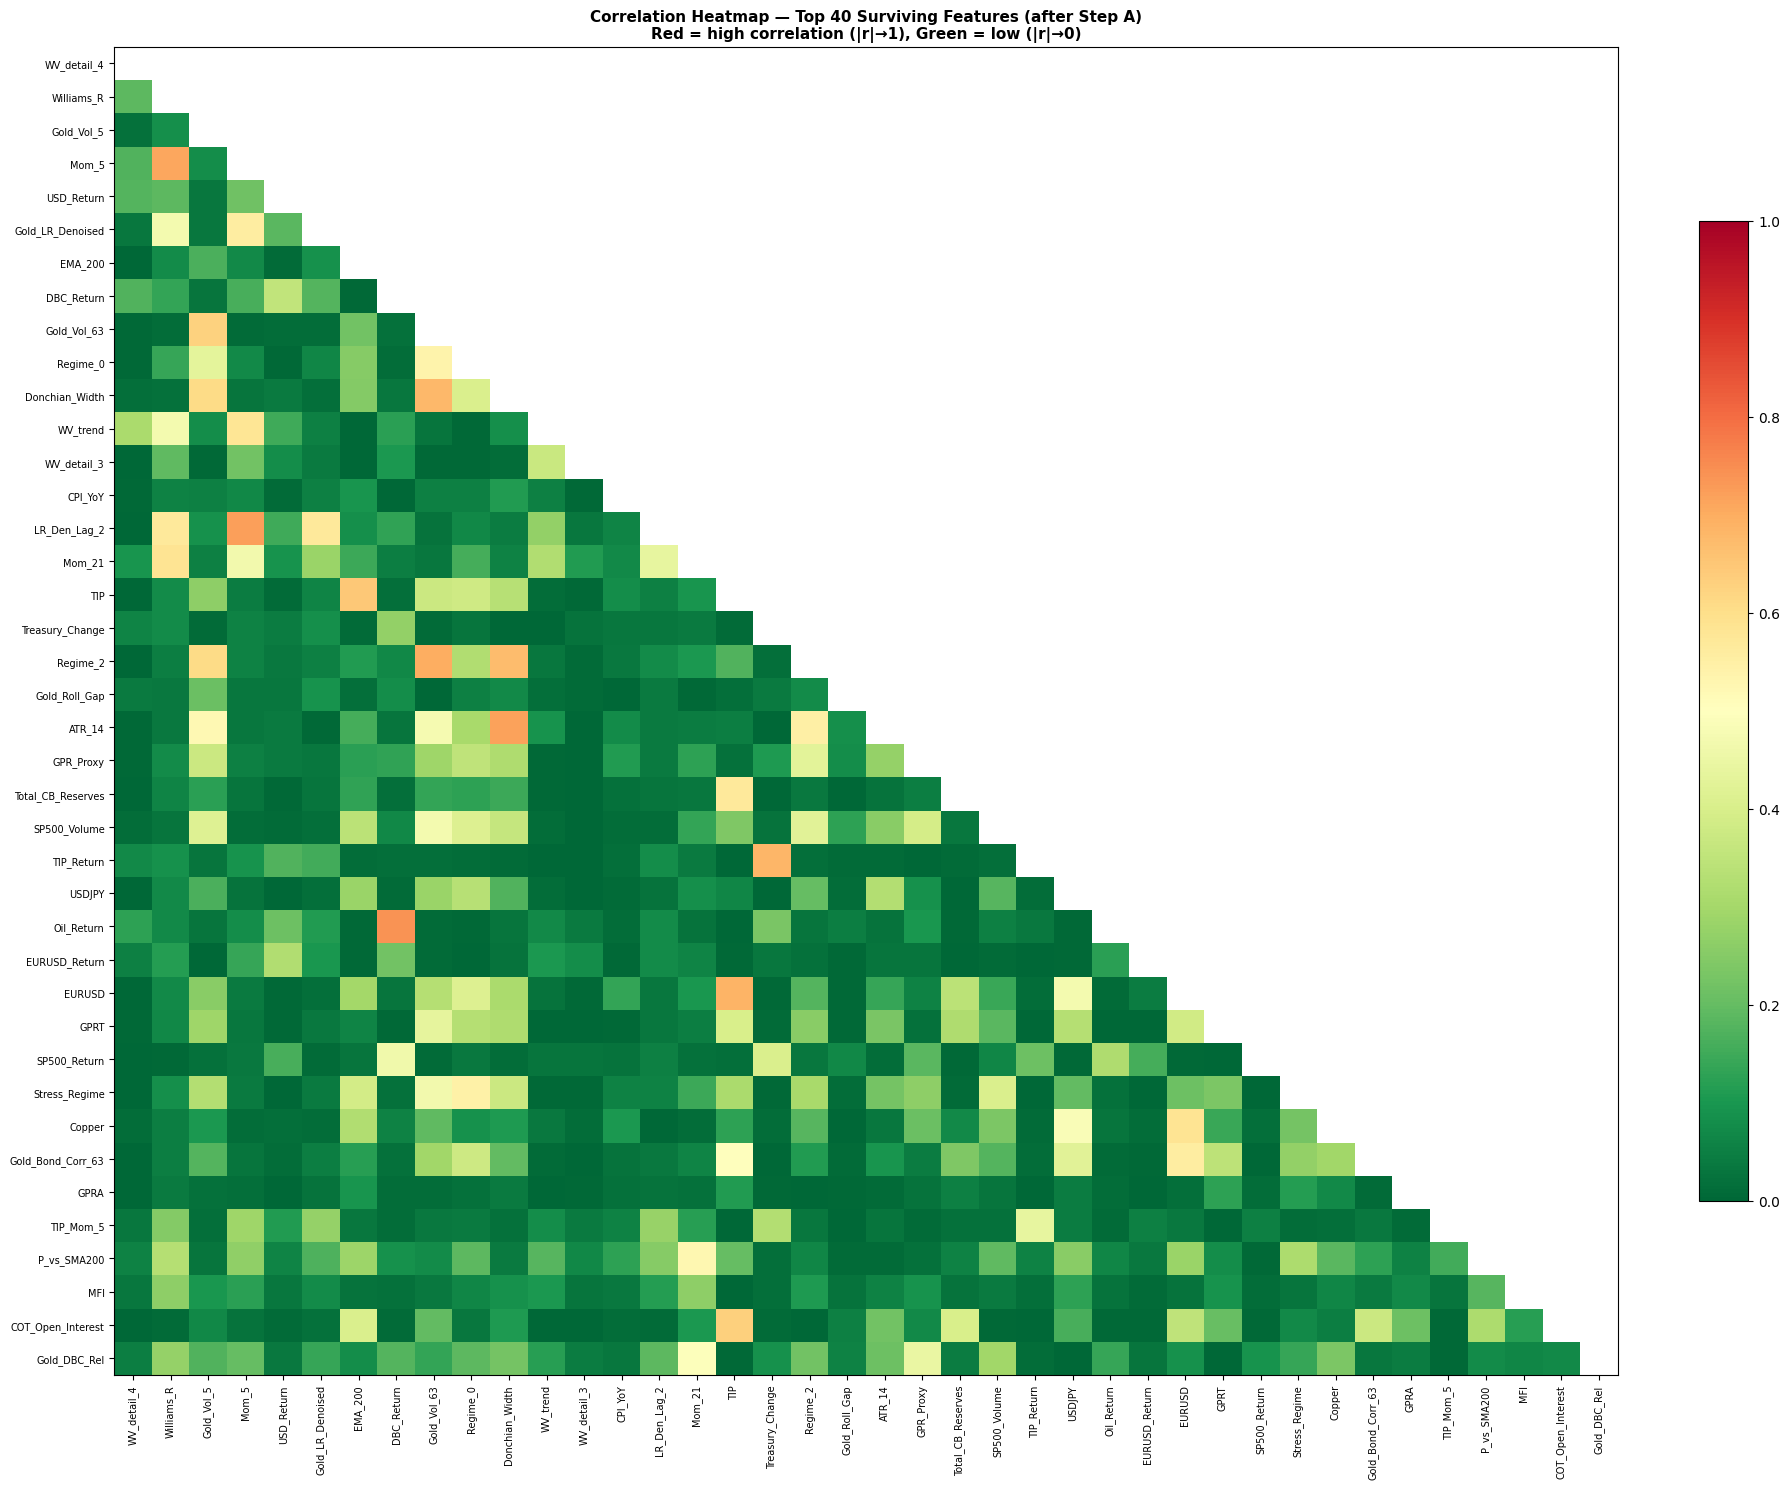

[Step A] Correlation heatmap displayed.
  [VIF iter   1] drop=WV_detail_1                   VIF=674519.3  MI=0.0000
  [VIF iter   2] drop=COT_NetSpec                   VIF=5.9  MI=0.0025
  [VIF iter   3] drop=Fed_Rate                      VIF=6.1  MI=0.0069
  [VIF iter   5] drop=Real_Rate_Approx              VIF=14.7  MI=0.0188
  [VIF iter  10] drop=Donchian_Width                VIF=6.3  MI=0.0671

[Step B — VIF] iterations=12  dropped=12  remaining=87
  Top 10 survivors by VIF:
EMA_200          4.150786
USDJPY           3.723344
Vol_Regime       3.665398
NLP_MA5          3.393652
Mom_21           3.364633
EURUSD           3.211417
NLP_Neg          3.170710
DBC_Return       3.141581
Stress_Regime    3.137973
Vol_Ratio        2.966850
[Step C] Fitting RF (300 trees)...
  RF OOB R²=0.6732
[Step C] Adaptive K (Ridge val MAE):
  K=15  val_MAE=0.37702 ← best
  K=20  val_MAE=0.37490 ← best
  K=25  val_MAE=0.33731 ← best
  K=30  val_MAE=0.33508 ← best

[Step C — MI+RF] K=30 selected (adaptive

In [22]:
# ==============================================================================
# SECTION 13 — MAIN PIPELINE
# ==============================================================================


print("\n" + "="*70)
print("  GOLD PRICE PREDICTION — RESEARCH PIPELINE")
print("="*70 + "\n")


# ── 1. Data ───────────────────────────────────────────────────────
df = download_market_data_cached(max_age_days=1)  # uses parquet cache; re-downloads if >1 day old
# Load official macro / behavioral inputs with publication lags.
# This keeps official macro, geopolitical risk, positioning, and reserve variables
# alongside traded market proxies such as Copper, TIP, DBC, GDX, and FX.
df = integrate_required_data_sources(df)

# ── 2. Sentiment ──────────────────────────────────────────────────
df = integrate_sentiment(df)
df = build_gpr_proxy(df)

# ── 2b. NLP News Sentiment ─────────────────────────────────────────────
df = integrate_nlp_sentiment(df)

# ── 3. Features & Regimes ─────────────────────────────────────────
df = engineer_features(df)

# Fit HMM/scaler on the chronological training partition only, then predict
# regimes for the full sample. This avoids regime-feature lookahead leakage.
N_SPLIT_HMM = int(len(df) * TRAIN_FRAC)
df = add_market_regime(df, n_train=N_SPLIT_HMM)

# ── 4. Clean & Scale ──────────────────────────────────────────────
TARGET    = 'Gold_Log_Return'
EXCLUDE   = ['Gold_Close', 'Gold_Close_Denoised', 'Market_Regime']
feat_cols = [c for c in df.columns if c not in EXCLUDE + [TARGET]]

df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Preserve the long 2007–2026 sample. Do NOT use blanket df.dropna(): one
# sparse macro/behavioral feature can otherwise shrink the sample to ~1,200 rows.
rows_before_clean = len(df)
df.dropna(subset=[TARGET], inplace=True)
N_SPLIT = int(len(df) * TRAIN_FRAC)
if N_SPLIT < LOOKBACK + 50:
    raise ValueError(f"[Clean] Too few train rows after target cleaning: shape={df.shape}")

min_train_obs = max(60, int(0.05 * N_SPLIT))
train_nonnull = df[feat_cols].iloc[:N_SPLIT].notna().sum()
sparse_cols = train_nonnull[train_nonnull < min_train_obs].index.tolist()
if sparse_cols:
    print(f"[Clean] Dropping {len(sparse_cols)} sparse/all-NaN feature columns: {sparse_cols[:20]}")
    feat_cols = [c for c in feat_cols if c not in sparse_cols]

# Feature imputation is leakage-aware: ffill uses only chronological past values;
# remaining initial gaps use medians computed on the training partition only.
df[feat_cols] = df[feat_cols].ffill()
train_medians = df[feat_cols].iloc[:N_SPLIT].median(skipna=True).fillna(0.0)
df[feat_cols] = df[feat_cols].fillna(train_medians).fillna(0.0)
remaining_nan_cols = df[feat_cols].columns[df[feat_cols].isna().any()].tolist()
if remaining_nan_cols:
    raise ValueError(f"[Clean] Remaining NaNs after imputation: {remaining_nan_cols[:20]}")

print(f"[Clean] rows {rows_before_clean} -> {len(df)}  features={len(feat_cols)}  dropped_sparse={len(sparse_cols)}")

X_raw = df[feat_cols].values
y_raw = df[TARGET].values

# ── CRITICAL: define N_SPLIT BEFORE fitting scalers ─────────────────────────
# Scalers must be fit ONLY on training rows to prevent val/test leakage.

scaler_X = RobustScaler()
scaler_y = RobustScaler()   # RobustScaler on target — log-returns are heavy-tailed

X_scaled = scaler_X.fit(X_raw[:N_SPLIT]).transform(X_raw)
y_scaled = scaler_y.fit(y_raw[:N_SPLIT].reshape(-1, 1)).transform(
               y_raw.reshape(-1, 1)).flatten()
print(f"[Scale] Scalers fit on train rows [0:{N_SPLIT}] — no val/test leakage")

# ── 5. Feature Selection — 3-Step Pipeline ───────────────────────
# Step A → Pairwise correlation filter  (|r| > 0.85 → drop lowest MI)
# Step B → VIF filter                   (VIF > 10  → drop lowest MI)
# Step C → MI + RF importance ranking   (adaptive TOP_K via Ridge val)
# All selection runs on X_scaled[:N_SPLIT] (training data only).

# ── Step A: Pairwise Correlation Filter — MI-guided ───────────────
# WHAT THIS DOES:
#   Finds all feature pairs with |r| > CORR_THRESHOLD (default 0.85).
#   For each correlated pair, keeps the feature with HIGHER mutual
#   information (MI) with the target — not just the alphabetical first.
#   Logs every dropped pair so you can audit the decision.
#   Example: RSI_7 vs RSI_14 → both correlated → keep whichever has
#   higher MI score with Gold_Log_Return.
#
# WHY MI-GUIDED (not alphabetical):
#   Alphabetical order is arbitrary. MI measures actual predictive
#   relevance to the target. Keeping the more informative feature
#   strictly dominates keeping by name order.
CORR_THRESHOLD = 0.75   # tightened from 0.85 → removes more redundant pairs

corr_df  = pd.DataFrame(X_scaled[:N_SPLIT], columns=feat_cols)
corr_mat = corr_df.corr().abs()

# ── Pre-compute MI scores for all features (used to break ties) ───
print("[Step A] Computing MI scores for tie-breaking...")
mi_pretrain = mutual_info_regression(
    X_scaled[:N_SPLIT], y_scaled[:N_SPLIT], random_state=SEED
)
mi_score = dict(zip(feat_cols, mi_pretrain))   # feature → MI value

# ── Build sorted list of correlated pairs (highest |r| first) ─────
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={"level_0": "feat_a", "level_1": "feat_b", 0: "corr"})
         .query("corr > @CORR_THRESHOLD")
         .sort_values("corr", ascending=False)
)

print(f"[Step A] Found {len(corr_pairs)} pairs with |r| > {CORR_THRESHOLD}:")
print(f"  {'Feature A':<30s}  {'Feature B':<30s}  {'|r|':>6s}  {'Keep':<30s}  Reason")
print(f"  {'-'*30}  {'-'*30}  {'-'*6}  {'-'*30}  ------")

drop_corr  = set()
corr_log   = []   # for heatmap later

for _, row in corr_pairs.iterrows():
    fa, fb, r = row["feat_a"], row["feat_b"], row["corr"]
    # Skip if both already scheduled for dropping
    if fa in drop_corr and fb in drop_corr:
        continue
    # Skip if one is already dropped — the other is safe
    if fa in drop_corr:
        continue
    if fb in drop_corr:
        continue

    # MI-guided decision: drop the one with lower MI
    mi_a, mi_b = mi_score.get(fa, 0), mi_score.get(fb, 0)
    if mi_a >= mi_b:
        drop, keep, reason = fb, fa, f"MI({fa[:18]})={mi_a:.4f} > MI({fb[:18]})={mi_b:.4f}"
    else:
        drop, keep, reason = fa, fb, f"MI({fb[:18]})={mi_b:.4f} > MI({fa[:18]})={mi_a:.4f}"

    drop_corr.add(drop)
    corr_log.append({"kept": keep, "dropped": drop, "corr": r,
                     "mi_kept": max(mi_a, mi_b), "mi_dropped": min(mi_a, mi_b)})
    print(f"  {fa:<30s}  {fb:<30s}  {r:6.3f}  {keep:<30s}  {reason}")

after_corr = [f for f in feat_cols if f not in drop_corr]
print(f"\n[Step A — Correlation] dropped={len(drop_corr)}  remaining={len(after_corr)}")

# ── Correlation heatmap of surviving features (top 40 by MI) ──────
try:
    top40_display = sorted(after_corr, key=lambda f: mi_score.get(f, 0), reverse=True)[:40]
    corr_display  = corr_mat.loc[top40_display, top40_display]
    fig, ax = plt.subplots(figsize=(18, 15))
    mask    = np.triu(np.ones_like(corr_display, dtype=bool))
    im      = ax.imshow(
        np.where(mask, np.nan, corr_display.values),
        cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto"
    )
    ax.set_xticks(range(len(top40_display)))
    ax.set_yticks(range(len(top40_display)))
    ax.set_xticklabels(top40_display, rotation=90, fontsize=7)
    ax.set_yticklabels(top40_display, fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.03)
    ax.set_title(
        f"Correlation Heatmap — Top 40 Surviving Features (after Step A)\n"
        f"Red = high correlation (|r|→1), Green = low (|r|→0)",
        fontweight="bold", fontsize=11
    )
    plt.tight_layout()
    plt.show()
    print("[Step A] Correlation heatmap displayed.")
except Exception as e:
    print(f"[Step A] Heatmap skipped: {e}")

# ── Step B: VIF Filter — MI-guided drop ──────────────────────────
# FIX: among features exceeding VIF threshold, drop the one with the
# LOWEST MI score (least predictive), not simply the highest VIF.
# This preserves highly predictive features even when they correlate
# with several others — a much stricter definition of "redundant".
VIF_THRESHOLD = 5.0    # tightened from 10 → more aggressive multicollinearity removal

def compute_vif(X_df):
    """Compute VIF for each column in X_df (numpy-backed DataFrame)."""
    return pd.Series(
        [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])],
        index=X_df.columns
    )

# mi_score dict is already available from Step A (no redundant refit)
vif_features = after_corr.copy()
iteration    = 0
dropped_vif  = []
while True:
    X_vif  = pd.DataFrame(X_scaled[:N_SPLIT], columns=feat_cols)[vif_features]
    vifs   = compute_vif(X_vif)
    bad    = vifs[vifs > VIF_THRESHOLD]
    if bad.empty:
        break
    # Drop the over-threshold feature with the LOWEST MI score
    bad_mi        = {f: mi_score.get(f, 0.0) for f in bad.index}
    drop_vif_feat = min(bad_mi, key=bad_mi.get)
    dropped_vif.append({'feature': drop_vif_feat,
                         'vif': vifs[drop_vif_feat], 'mi': bad_mi[drop_vif_feat]})
    vif_features.remove(drop_vif_feat)
    iteration += 1
    if FAST_RUN and iteration >= 5:
        print("  [VIF] FAST_RUN VIF cap reached after 5 drops")
        break
    if iteration % 5 == 0 or iteration <= 3:
        print(f"  [VIF iter {iteration:3d}] drop={drop_vif_feat:<28s}  "
              f"VIF={vifs[drop_vif_feat]:.1f}  MI={bad_mi[drop_vif_feat]:.4f}")

print(f"\n[Step B — VIF] iterations={iteration}  dropped={len(dropped_vif)}  "
      f"remaining={len(vif_features)}")
X_vif_final = pd.DataFrame(X_scaled[:N_SPLIT], columns=feat_cols)[vif_features]
print("  Top 10 survivors by VIF:")
print(compute_vif(X_vif_final).sort_values(ascending=False).head(10).to_string())

# ── Step C: MI + RF Importance Ranking ───────────────────────────
# Reuses mi_score from Step A — no redundant MI fit.
# RF: 300 trees with OOB score to check importance stability.
# Adaptive TOP_K: evaluates K ∈ {20,30,40,50} on Ridge val MAE.
vif_idx = [feat_cols.index(f) for f in vif_features]
X_clean = X_scaled[:, vif_idx]

# Reuse MI from Step A ───────────────────────────────────────────
mi_stepC = np.array([mi_score.get(f, 0.0) for f in vif_features])

# RF 300 trees + OOB for stability check ─────────────────────────
rf_trees = 30 if FAST_RUN else 300
print(f"[Step C] Fitting RF ({rf_trees} trees)...")
rf = RandomForestRegressor(rf_trees, n_jobs=-1, random_state=SEED, oob_score=True)
rf.fit(X_clean[:N_SPLIT], y_scaled[:N_SPLIT])
print(f"  RF OOB R²={rf.oob_score_:.4f}")

mi_r = pd.Series(mi_stepC, index=vif_features).rank(ascending=False)
rf_r = pd.Series(rf.feature_importances_, index=vif_features).rank(ascending=False)
combined_rank = (mi_r + rf_r).sort_values()

# Adaptive TOP_K via Ridge val MAE ────────────────────────────────
n_val_end    = N_SPLIT + int(len(X_scaled) * VAL_FRAC)
K_candidates = [10, 15] if FAST_RUN else [k for k in [15, 20, 25, 30] if k <= len(vif_features)]
best_k, best_mae = TOP_K, np.inf
print("[Step C] Adaptive K (Ridge val MAE):")
for k in K_candidates:
    cand_feats = combined_rank.head(k).index.tolist()
    cand_idx   = [feat_cols.index(f) for f in cand_feats]
    ridge_k    = Ridge(alpha=1.0)
    ridge_k.fit(X_scaled[:N_SPLIT, cand_idx], y_scaled[:N_SPLIT])
    mae = np.mean(np.abs(ridge_k.predict(
              X_scaled[N_SPLIT:n_val_end, cand_idx]) - y_scaled[N_SPLIT:n_val_end]))
    flag = " ← best" if mae < best_mae else ""
    print(f"  K={k:2d}  val_MAE={mae:.5f}{flag}")
    if mae < best_mae:
        best_mae, best_k = mae, k

top_features = combined_rank.head(best_k).index.tolist()
feat_importance_df = pd.DataFrame({
    'Feature'      : combined_rank.head(best_k).index,
    'CombinedRank' : combined_rank.head(best_k).values,
    'MI_Score'     : pd.Series(mi_stepC, index=vif_features).loc[top_features].values,
    'RF_Importance': pd.Series(rf.feature_importances_, index=vif_features).loc[top_features].values,
}).sort_values('CombinedRank')
print(f"\n[Step C — MI+RF] K={best_k} selected (adaptive):")
print(feat_importance_df.to_string(index=False))

print(f"\n[FeatSel Summary]")
print(f"  Raw features          : {len(feat_cols)}")
print(f"  After correlation (A) : {len(after_corr)}")
print(f"  After VIF (B)         : {len(vif_features)}")
print(f"  After MI+RF (C) K={best_k:2d} : {len(top_features)}")
print(f"  Final features        : {top_features}")

top_idx    = [feat_cols.index(f) for f in top_features]
X_sel = X_scaled[:, top_idx]
N_FEATURES = len(top_features)

print(f"\n[Step D — No PCA]")
print("  PCA disabled for controlled NoPCA comparison")
print(f"  Model input width: {N_FEATURES} selected raw features")

print(f"\n{'='*60}")
print(f"  FEATURE SELECTION FUNNEL  (No PCA variant)")
print(f"{'='*60}")
print(f"  Raw features              : {len(feat_cols)}")
print(f"  After correlation A (0.75): {len(after_corr)}")
print(f"  After VIF B         (5.0) : {len(vif_features)}")
print(f"  After MI+RF C  K={best_k:2d}     : {len(top_features)}  ← model input width")
print(f"{'='*60}")


# ── 6. Sequences ──────────────────────────────────────────────────
def make_sequences(X, y, lookback=LOOKBACK, horizon=HORIZON):
        Xs, ys = [], []
        for i in range(lookback, len(X) - horizon + 1):
            Xs.append(X[i - lookback: i])
            ys.append(y[i + horizon - 1])
        return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_sel, y_scaled)
regimes_seq  = df['Market_Regime'].values[LOOKBACK:]

n       = len(X_seq)
n_train = int(n * TRAIN_FRAC)
n_val   = int(n * VAL_FRAC)

X_train, y_train = X_seq[:n_train], y_seq[:n_train]
X_val,   y_val   = X_seq[n_train:n_train+n_val],y_seq[n_train:n_train+n_val]
X_test,  y_test  = X_seq[n_train+n_val:],       y_seq[n_train+n_val:]
r_val   = regimes_seq[n_train:n_train+n_val]
r_test  = regimes_seq[n_train+n_val:]

print(f"[Split] Train={X_train.shape} Val={X_val.shape} Test={X_test.shape}")
print("Step 6 complete")

### Sequence Construction & Train / Val / Test Splits

---
## §16 · Walk-Forward Training

All eight models are trained through expanding-window walk-forward validation
using the global training configuration (`N_SPLITS_WF = 3`, `EPOCHS = 40`,
`BATCH_SIZE = 64` in the full run). The final fold model for each architecture
is retained for test-set prediction, ensemble construction, and training-curve
visualization.


In [23]:
# ── 8. Walk-Forward CV — ALL MODELS ─────────────────────────────────────────
print("\n" + "="*70)
print("  WALK-FORWARD CROSS-VALIDATION — ALL MODELS")
print("="*70)

_WF_START = time.time()   # runtime tracking

WF_REGISTRY = {
    'TFT_Lite'     : dict(build_fn=build_tft_lite),       # compact attention + LSTM sequence model
    'Residual_LSTM': dict(build_fn=build_residual_lstm),  # LSTM blocks with residual skip connections
    'CNN_GRU'      : dict(build_fn=build_cnn_gru),        # convolutional feature extraction + GRU temporal modeling
    'CNN_BiLSTM'   : dict(build_fn=build_cnn_bilstm),     # convolutional feature extraction + bidirectional LSTM
    'TCT'          : dict(build_fn=build_tct, is_tct=True),  # dilated causal convolutions + attention + direction head
    'MSF'          : dict(build_fn=build_multi_scale_fusion, is_msf=True,
                           lookbacks_list=LOOKBACKS,
                           X_scaled_sel=X_sel, y_scaled=y_scaled),  # multi-scale inputs for short/medium/long horizons
    'Informer'     : dict(build_fn=build_informer),       # transformer-inspired attention with temporal distilling
    'Autoformer'   : dict(build_fn=build_autoformer),     # transformer-inspired decomposition and autocorrelation
}

print(f"[Main Models] High-capacity 8-model set: {list(WF_REGISTRY.keys())}")

wf_results    = {}   # name -> metrics DataFrame
wf_models     = {}   # name -> last-fold trained model  ← used for all predictions
wf_histories  = {}   # name -> last-fold training history ← used for training curves

for model_name, kwargs in WF_REGISTRY.items():
    print(f"\n[Walk-Forward CV — {model_name}]")
    try:
        df_wf, last_model, last_hist = walk_forward_cv(
            name       = model_name,
            X_seq      = X_seq,
            y_seq      = y_seq,
            lookback   = LOOKBACK,
            n_features = N_FEATURES,
            **kwargs
        )
        wf_results[model_name]   = df_wf
        wf_models[model_name]    = last_model
        wf_histories[model_name] = last_hist   # last fold history for training curves
        print(df_wf.to_string(index=False))
    except Exception as exc:
        import traceback; traceback.print_exc()
        print(f"  [WARN] {model_name} walk-forward failed: {exc}")
        wf_results[model_name] = pd.DataFrame(
            [{'fold': f, 'rmse': np.nan, 'dir_acc': np.nan} for f in range(1, 6)]
        )
        wf_models[model_name] = None  # no fallback — model failed walk-forward

# ── Replace trained_models with walk-forward last-fold models ────────────────
# This ensures all downstream steps (predictions, ARCE, conformal) use
# the most temporally current, walk-forward validated models.
trained_models = {k: v for k, v in wf_models.items() if v is not None}
histories      = {k: v for k, v in wf_histories.items() if v is not None}
print(f"\n[WF] Using last-fold models for prediction: {list(trained_models.keys())}")
print(f"[WF] Histories collected for: {list(histories.keys())}")

# ── Summary ───────────────────────────────────────────────────────────────────
wf_summary_rows = []
for model_name, df_wf in wf_results.items():
    wf_summary_rows.append({
        'Model'      : model_name,
        'Mean_RMSE'  : df_wf['rmse'].mean(),
        'Std_RMSE'   : df_wf['rmse'].std(),
        'Mean_DirAcc': df_wf['dir_acc'].mean(),
        'Std_DirAcc' : df_wf['dir_acc'].std(),
    })

wf_summary = pd.DataFrame(wf_summary_rows).sort_values('Mean_DirAcc', ascending=False)
print("\n" + "="*70)
print("WALK-FORWARD SUMMARY — ALL MODELS")
print("="*70)
print(wf_summary.to_string(index=False))
print("="*70)


# wf_df -> first model folds, used by plot_all Fig-6
wf_df = wf_results.get('TFT_Lite', list(wf_results.values())[0])

# ── Walk-Forward Runtime ──────────────────────────────────────────
_wf_elapsed = time.time() - _WF_START
_wm, _ws = divmod(int(_wf_elapsed), 60)
_wh, _wm = divmod(_wm, 60)
print("\n" + "="*70)
print(f"  Walk-Forward Training complete: {_wh:02d}h {_wm:02d}m {_ws:02d}s  ({_wf_elapsed:.1f}s)")
print("="*70)


  WALK-FORWARD CROSS-VALIDATION — ALL MODELS
[Main Models] High-capacity 8-model set: ['TFT_Lite', 'Residual_LSTM', 'CNN_GRU', 'CNN_BiLSTM', 'TCT', 'MSF', 'Informer', 'Autoformer']

[Walk-Forward CV — TFT_Lite]


I0000 00:00:1780250858.564444 4676637 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780250858.565290 4676637 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


  [TFT_Lite] Fold 1 → RMSE=0.619456  DirAcc=81.24%
  [TFT_Lite] Fold 2 → RMSE=0.590730  DirAcc=80.90%
  [TFT_Lite] Fold 3 → RMSE=0.669106  DirAcc=80.07%
 fold     rmse  dir_acc
    1 0.619456 0.812395
    2 0.590730 0.809045
    3 0.669106 0.800670

[Walk-Forward CV — Residual_LSTM]
  [Residual_LSTM] Fold 1 → RMSE=0.764737  DirAcc=69.18%
  [Residual_LSTM] Fold 2 → RMSE=0.552202  DirAcc=74.54%
  [Residual_LSTM] Fold 3 → RMSE=0.822368  DirAcc=70.69%
 fold     rmse  dir_acc
    1 0.764737 0.691792
    2 0.552202 0.745394
    3 0.822368 0.706868

[Walk-Forward CV — CNN_GRU]
  [CNN_GRU] Fold 1 → RMSE=0.909273  DirAcc=68.17%
  [CNN_GRU] Fold 2 → RMSE=0.721562  DirAcc=70.10%
  [CNN_GRU] Fold 3 → RMSE=0.811622  DirAcc=70.77%
 fold     rmse  dir_acc
    1 0.909273 0.681742
    2 0.721562 0.701005
    3 0.811622 0.707705

[Walk-Forward CV — CNN_BiLSTM]
  [CNN_BiLSTM] Fold 1 → RMSE=0.861267  DirAcc=73.70%
  [CNN_BiLSTM] Fold 2 → RMSE=0.744518  DirAcc=69.01%
  [CNN_BiLSTM] Fold 3 → RMSE=0.666726  

---
## §17 · Prediction, Ensemble & Results

Individual model predictions are generated on aligned validation and test
windows, with special handling for MSF multi-input sequences and TCT dual-head
outputs. ARCE learns nonnegative per-regime ensemble weights on the validation
set and applies them to the test set. The section then evaluates point forecasts,
directional performance, trading metrics, conformal intervals, and CSV exports.


### 17.1 · Individual Model Predictions + ARCE Ensemble

In [24]:
# ── 9. Individual Predictions ─────────────────────────────────────
# MSF uses max(LOOKBACKS), which can produce fewer samples than standard LOOKBACK.
# Align MSF val/test windows to the exact same calendar windows as X_val/X_test.

msf_X_all, msf_y_all = make_msf_sequences(X_sel, y_scaled, LOOKBACKS)
msf_offset = len(y_seq) - len(msf_y_all)   # max(LOOKBACKS) - LOOKBACK

msf_val_start  = n_train - msf_offset
msf_val_end    = msf_val_start + n_val
msf_test_start = msf_val_end
msf_test_end   = msf_test_start + len(y_test)

def msf_slice(msf_X_list, start, end):
    """Slice each per-branch array to [start:end]."""
    return [arr[start:end] for arr in msf_X_list]

msf_X_val  = msf_slice(msf_X_all, msf_val_start,  msf_val_end)
msf_X_test = msf_slice(msf_X_all, msf_test_start, msf_test_end)

assert msf_X_val[0].shape[0]  == X_val.shape[0],      f"Val size mismatch: MSF={msf_X_val[0].shape[0]} vs X_val={X_val.shape[0]}"
assert msf_X_test[0].shape[0] == X_test.shape[0],     f"Test size mismatch: MSF={msf_X_test[0].shape[0]} vs X_test={X_test.shape[0]}"

print(f"[MSF splits] val={msf_X_val[0].shape}  test={msf_X_test[0].shape}")
print(f"[Alignment]  X_val={X_val.shape}  X_test={X_test.shape}  ✓ sizes match")

# Predict — all return predictions are kept in SCALED return space until evaluate_model().
individual_preds = {}
tct_direction_prob = None
_zero_scaled_value = float(scaler_y.transform([[0.0]])[0, 0])

for name, model in trained_models.items():
    if name == 'TCT':
        p = model.predict(X_test, verbose=0)
        individual_preds[name] = p[0].flatten()   # scaled log-return forecast
        tct_direction_prob = p[1].flatten()       # P(up), not a return forecast
    elif name == 'MSF':
        p = model.predict(msf_X_test, verbose=0)
        individual_preds[name] = p.flatten()
    else:
        individual_preds[name] = model.predict(X_test, verbose=0).flatten()

print(f"[Step 9] return predictions collected for: {list(individual_preds.keys())}")

# ── TCT Direction Head Evaluation ────────────────────────────────
# TCT_DirProb is evaluated separately as a direction classifier and is NOT passed
# into evaluate_model(), because it is a probability rather than a log-return forecast.
if tct_direction_prob is not None and 'TCT' in individual_preds:
    tct_reg = individual_preds['TCT']
    reg_da  = np.mean((tct_reg > _zero_scaled_value) == (y_test > _zero_scaled_value))
    dir_da  = np.mean((tct_direction_prob > 0.5) == (y_test > _zero_scaled_value))
    tct_signed_strength = 2.0 * tct_direction_prob - 1.0
    tct_comb = np.where(
        (tct_reg > _zero_scaled_value) == (tct_direction_prob > 0.5),
        tct_reg,
        _zero_scaled_value + (tct_reg - _zero_scaled_value) * tct_signed_strength,
    )
    individual_preds['TCT_Combined'] = tct_comb
    tct_direction_metrics = {
        'TCT_Reg_DirAcc': reg_da,
        'TCT_DirHead_DirAcc': dir_da,
    }
    print(f"[TCT Heads]  Regression DirAcc = {reg_da:.2%}")
    print(f"[TCT Heads]  Direction  DirAcc = {dir_da:.2%}")
    print("[TCT Heads]  TCT_Combined stored as a derived scaled-return forecast")
else:
    tct_direction_metrics = {}

# ── 10. ARCE Ensemble ─────────────────────────────────────────────
val_preds = {}
for name, model in trained_models.items():
    if name == 'TCT':
        p = model.predict(X_val, verbose=0)
        val_preds[name] = p[0].flatten()
    elif name == 'MSF':
        p = model.predict(msf_X_val, verbose=0)
        val_preds[name] = p.flatten()
    else:
        val_preds[name] = model.predict(X_val, verbose=0).flatten()

arce = RegimeConditionedEnsemble(N_REGIMES)
arce.fit(val_preds, y_val, r_val)
_ARCE_KEYS     = list(val_preds.keys())
arce_preds_in  = {k: individual_preds[k] for k in _ARCE_KEYS if k in individual_preds}
ensemble_preds = arce.predict(arce_preds_in, r_test)


[MSF splits] val=(716, 20, 30)  test=(718, 20, 30)
[Alignment]  X_val=(716, 60, 30)  X_test=(718, 60, 30)  ✓ sizes match
[Step 9] return predictions collected for: ['TFT_Lite', 'Residual_LSTM', 'CNN_GRU', 'CNN_BiLSTM', 'TCT', 'MSF', 'Informer', 'Autoformer']
[TCT Heads]  Regression DirAcc = 78.55%
[TCT Heads]  Direction  DirAcc = 78.55%
[TCT Heads]  TCT_Combined stored as a derived scaled-return forecast
[ARCE] Per-regime weights:
  Regime 0: TFT_Lite=0.000, Residual_LSTM=0.078, CNN_GRU=0.000, CNN_BiLSTM=0.341, TCT=0.102, MSF=0.479, Informer=0.000, Autoformer=0.000
  Regime 1: TFT_Lite=0.000, Residual_LSTM=0.047, CNN_GRU=0.003, CNN_BiLSTM=0.073, TCT=0.174, MSF=0.475, Informer=0.227, Autoformer=0.000
  Regime 2: TFT_Lite=0.125, Residual_LSTM=0.125, CNN_GRU=0.125, CNN_BiLSTM=0.125, TCT=0.125, MSF=0.125, Informer=0.125, Autoformer=0.125


### 17.2 · Conformal Prediction Intervals

In [25]:
# ── 11. Conformal Prediction ──────────────────────────────────────
conformal = ConformalPredictor(alpha=CONFORMAL_ALPHA)
best_val_model = min(val_preds, key=lambda n: np.sqrt(mean_squared_error(y_val, val_preds[n])))

# Calibrate on scaled validation residuals. Convert intervals back to raw returns only for reporting.
ensemble_val_for_conformal = (
    arce.predict(val_preds, r_val)
    if hasattr(arce, 'predict')
    else val_preds[best_val_model]
)
conformal.calibrate(y_val, ensemble_val_for_conformal, regimes=r_val)

lo_val_sc, hi_val_sc = conformal.predict_interval(ensemble_val_for_conformal, regimes=r_val)
y_val_inv = scaler_y.inverse_transform(y_val.reshape(-1, 1)).flatten()
lo_val    = scaler_y.inverse_transform(lo_val_sc.reshape(-1, 1)).flatten()
hi_val    = scaler_y.inverse_transform(hi_val_sc.reshape(-1, 1)).flatten()
val_cov   = np.mean((y_val_inv >= lo_val) & (y_val_inv <= hi_val))
tgt_cov   = 1 - CONFORMAL_ALPHA

print("\n" + "="*60)
print("  CONFORMAL PREDICTION INTERVALS")
print(f"  Target coverage    : {tgt_cov:.0%}")
print(f"  Val-set coverage   : {val_cov:.2%}  "
      f"({'✓' if val_cov >= tgt_cov else '✗'} target)")
print(f"  Avg interval width : {np.mean(hi_val - lo_val):.6f}")
print(f"  Width std          : {np.std(hi_val - lo_val):.6f}")
print("="*60)
conformal_metrics = dict(target=tgt_cov, val_coverage=val_cov,
                         gap=val_cov - tgt_cov,
                         width=np.mean(hi_val - lo_val),
                         width_std=np.std(hi_val - lo_val))


[Conformal] global q̂=0.570956  Coverage=90.2%  (target=90%)
  Regime 0: q̂=0.587297  Coverage=92.1%  n=63
  Regime 1: q̂=0.570956  Coverage=90.2%  n=653

  CONFORMAL PREDICTION INTERVALS
  Target coverage    : 90%
  Val-set coverage   : 90.36%  (✓ target)
  Avg interval width : 0.012689
  Width std          : 0.000103


### 17.3 · Evaluation Metrics

In [26]:
# ── 12. Evaluate ──────────────────────────────────────────────────
# Baselines must remain in SCALED return space because evaluate_model()
# inverse-transforms predictions internally.
_pers_scaled = np.append([y_test[0]], y_test[:-1])
_zero_scaled = np.full(len(y_test), _zero_scaled_value)
individual_preds['Persistence']  = _pers_scaled
individual_preds['ZeroReturn']   = _zero_scaled
print("[Baselines] Persistence and ZeroReturn added in scaled return space")

results = {}
for name, preds_sc in individual_preds.items():
    results[name] = evaluate_model(preds_sc, y_test, scaler_y, name)

actuals_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
ens_inv     = scaler_y.inverse_transform(ensemble_preds.reshape(-1, 1)).flatten()

# Build ARCE ensemble result using the same evaluator for consistency.
results['ARCE_Ensemble'] = evaluate_model(ensemble_preds, y_test, scaler_y, 'ARCE_Ensemble')

perf_df = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ('preds', 'actuals', 'strat_ret')}
        for r in results.values()
    ])

best_by_diracc = perf_df.sort_values('DirAcc', ascending=False).iloc[0]['Model']
best_by_rmse   = perf_df.sort_values('RMSE', ascending=True).iloc[0]['Model']
best_by_sharpe = perf_df.sort_values('Sharpe', ascending=False).iloc[0]['Model']

perf_df = perf_df.sort_values(['DirAcc', 'RMSE'], ascending=[False, True])

print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(perf_df.to_string(index=False))
print("="*70)
print(f"Best Model (by DirAcc): {best_by_diracc}")
print(f"Best Model (by RMSE)  : {best_by_rmse}")
print(f"Best Model (by Sharpe): {best_by_sharpe}")

best_name = best_by_diracc


[Baselines] Persistence and ZeroReturn added in scaled return space

MODEL PERFORMANCE SUMMARY
        Model     RMSE      MAE        R2   DirAcc  DirAcc_Large  DirAcc_RW  IC_Pearson  IC_Spearman  Q5_Q1_Spread    Sharpe     MaxDD     Calmar
          MSF 0.006460 0.003969  0.738931 0.848189      0.988889   0.948068    0.862090     0.875291      0.029126 12.210968 -0.029305 189.656532
ARCE_Ensemble 0.008029 0.004491  0.596697 0.835655      0.988889   0.944489    0.804860     0.872252      0.027795 12.056776 -0.022557 244.431337
     Informer 0.008083 0.004723  0.591282 0.813370      0.966667   0.914770    0.797665     0.835516      0.027519 10.853311 -0.039062 131.709336
     TFT_Lite 0.008548 0.005207  0.542979 0.800836      0.950000   0.911581    0.774666     0.820634      0.026755 10.731547 -0.039062 130.696964
   CNN_BiLSTM 0.008724 0.005414  0.523935 0.788301      0.950000   0.904324    0.744360     0.773402      0.025684 10.459096 -0.029305 171.140454
          TCT 0.009177 0.0057

---
## §18 · Lightweight Hypothesis Validation

This section is intentionally lightweight: it complements the main top-feature
pipeline without replacing it. A compact `Residual_LSTM` is used to compare
G1 price/technical features, G2 price + macro/cross-asset features, and G3
price + macro/cross-asset + sentiment/behavioral features. A separate
`Final_NoHMM` versus `Final_HMM` ablation tests whether explicit regime
information improves the final feature set.


In [27]:
# ── 16. Lightweight G1/G2/G3 validation + HMM ablation ────────────────────────
VALIDATION_EPOCHS = 3 if FAST_RUN else 12
VALIDATION_BATCH_SIZE = BATCH_SIZE
VALIDATION_MODEL = 'Residual_LSTM'

# Source-based grouping for lightweight validation:
# G1 = price/technical only.
# G2 = G1 + macro, geopolitical risk, and cross-asset market proxies.
# G3 = G2 + sentiment, positioning, and behavioral demand variables.
# HMM/regime features are held out for the separate Final_NoHMM vs Final_HMM test.
_HMM_PATTERNS = (
    'Market_Regime', 'Regime_', 'Regime_Change', 'Regime_Duration'
)
_MACRO_PATTERNS = (
    'Fed_Rate', 'FEDFUNDS', 'DFII10', 'TIPS_Real_Yield', 'Real_Rate',
    'Breakeven_Inflation', 'T10YIE', 'CPI', 'CPIAUCSL', 'M2', 'M2SL',
    'HY_Spread', 'BAA10Y', 'Financial_Stress', 'STLFSI', 'WUI',
    # Real geopolitical risk is treated as macro/geopolitical risk.
    'GPR', 'GPRA', 'GPRT',
    # Cross-asset and traded macro proxy variables.
    'USD', 'SP500', 'VIX', 'Silver', 'Oil', 'Treasury', 'TIP', 'Copper',
    'DBC', 'GDX', 'EURUSD', 'USDJPY', 'JPY', 'USDBRL',
    'Stress', 'Breakeven', 'Inflation', 'Gold_Silver', 'Gold_USD',
    'RealRate', 'Bond', 'DBC', 'GDX'
)
_SENTIMENT_PATTERNS = (
    'NLP', 'FearGreed', 'Fear_Greed', 'Sentiment', 'Gold_NLP', 'Gold_FG',
    # Behavioral, positioning, and demand variables.
    'COT', 'CFTC', 'NetSpec', 'Open_Interest',
    'Total_CB_Reserves', 'CB_NetBuying', 'CB_NetBuyer', 'CB_Reserves'
)
_RAW_EXCLUDE = {'Gold_Close', 'Gold_Close_Denoised', 'Gold_LR_Denoised', 'Gold_Volume', 'SP500_Volume'}

def _has_any(name, patterns):
    return any(p in name for p in patterns)

def _clean_feature_list(cols):
    out = []
    for c in cols:
        if c in df.columns and c not in _RAW_EXCLUDE and c != TARGET and c not in out:
            out.append(c)
    return out

# Resolve mutually exclusive feature groups in priority order.
# Macro is identified before sentiment so GPR/GPRA/GPRT/WUI stay in G2.
hmm_cols       = _clean_feature_list([c for c in feat_cols if _has_any(c, _HMM_PATTERNS)])
macro_cols     = _clean_feature_list([c for c in feat_cols if _has_any(c, _MACRO_PATTERNS) and c not in hmm_cols])
sentiment_cols = _clean_feature_list([c for c in feat_cols if _has_any(c, _SENTIMENT_PATTERNS) and c not in hmm_cols and c not in macro_cols])
price_cols     = _clean_feature_list([c for c in feat_cols if c not in hmm_cols + macro_cols + sentiment_cols])

G1_features = price_cols
G2_features = _clean_feature_list(price_cols + macro_cols)
G3_features = _clean_feature_list(price_cols + macro_cols + sentiment_cols)

print("\n" + "="*76)
print("LIGHTWEIGHT G1/G2/G3 VALIDATION FEATURE GROUPS")
print("="*76)
print(f"G1 price/technical             : {len(G1_features)} features")
print(f"G2 price + macro/cross-asset   : {len(G2_features)} features")
print(f"G3 G2 + sentiment/behavioral   : {len(G3_features)} features")
print(f"Macro/cross candidates         : {len(macro_cols)} -> {macro_cols[:12]}")
print(f"Sentiment/behavioral candidates: {len(sentiment_cols)} -> {sentiment_cols[:12]}")
print(f"HMM/regime candidates          : {len(hmm_cols)} -> {hmm_cols[:12]}")
print("="*76)

def _cap_features(features, max_features=40):
    keep = [f for f in features if f in top_features]
    if len(keep) < min(max_features, len(features)):
        keep += [f for f in features if f not in keep]
    return keep[:min(max_features, len(keep))]

def _cap_with_required(base_features, required_features, max_features=50):
    base = _cap_features(base_features, max_features=max_features)
    required = [f for f in required_features if f in df.columns and f not in base]
    if len(base) + len(required) <= max_features:
        return _clean_feature_list(base + required)
    room = max(max_features - len(required), 0)
    return _clean_feature_list(base[:room] + required)

def _prepare_validation_data(feature_list, label):
    avail = _clean_feature_list(feature_list)
    if len(avail) == 0:
        raise ValueError(f"{label}: no available features")
    d = df[avail + [TARGET]].copy()
    d.replace([np.inf, -np.inf], np.nan, inplace=True)
    d.dropna(subset=[TARGET], inplace=True)
    d[avail] = d[avail].ffill()
    nt = int(len(d) * TRAIN_FRAC)
    nv = int(len(d) * VAL_FRAC)
    train_medians = d[avail].iloc[:nt].median(skipna=True).fillna(0.0)
    d[avail] = d[avail].fillna(train_medians).fillna(0.0)
    X_all = d[avail].values
    y_all = d[TARGET].values
    sc_X = RobustScaler()
    sc_y = RobustScaler()
    X_sc = sc_X.fit(X_all[:nt]).transform(X_all)
    y_sc = sc_y.fit(y_all[:nt].reshape(-1, 1)).transform(y_all.reshape(-1, 1)).flatten()
    X_seq_v, y_seq_v = make_sequences(X_sc, y_sc, LOOKBACK, HORIZON)
    ntr = max(nt - LOOKBACK, 1)
    nva = nv
    return {
        'label': label,
        'features': avail,
        'Xtr': X_seq_v[:ntr],
        'ytr': y_seq_v[:ntr],
        'Xva': X_seq_v[ntr:ntr+nva],
        'yva': y_seq_v[ntr:ntr+nva],
        'Xte': X_seq_v[ntr+nva:],
        'yte': y_seq_v[ntr+nva:],
        'sc_y': sc_y,
    }

def _fit_lightweight_validation(label, feature_list):
    ed = _prepare_validation_data(feature_list, label)
    if len(ed['Xtr']) == 0 or len(ed['Xva']) == 0 or len(ed['Xte']) == 0:
        raise ValueError(f"{label}: empty train/val/test after sequence construction")
    model = build_residual_lstm(LOOKBACK, ed['Xtr'].shape[2])
    hist = model.fit(
        ed['Xtr'], ed['ytr'],
        validation_data=(ed['Xva'], ed['yva']),
        epochs=VALIDATION_EPOCHS,
        batch_size=VALIDATION_BATCH_SIZE,
        callbacks=get_callbacks(f"validation_{label}", checkpoint=False),
        verbose=0,
    )
    pred_sc = model.predict(ed['Xte'], verbose=0).flatten()
    res = evaluate_model(pred_sc, ed['yte'], ed['sc_y'], label)
    row = {k: v for k, v in res.items() if k not in ('preds', 'actuals', 'strat_ret')}
    row['N_Features'] = len(ed['features'])
    row['Validation_Epochs'] = VALIDATION_EPOCHS
    return row, res, ed, hist

# ── G1/G2/G3 hypothesis validation ───────────────────────────────
g123_specs = {
    'G1_PriceTechnical': _cap_features(G1_features),
    'G2_PriceMacro': _cap_features(G2_features),
    'G3_PriceMacroSentiment': _cap_features(G3_features),
}

g123_results = {}
g123_rows = []
print("\n" + "="*76)
print(f"RUNNING LIGHTWEIGHT G1/G2/G3 VALIDATION with {VALIDATION_MODEL}")
print("="*76)
for label, feats in g123_specs.items():
    print(f"[Validation] {label}: {len(feats)} features")
    row, res, ed, hist = _fit_lightweight_validation(label, feats)
    g123_rows.append(row)
    g123_results[label] = {'metrics': res, 'data': ed, 'history': hist, 'features': feats}

g123_validation_df = pd.DataFrame(g123_rows)
print("\nG1/G2/G3 VALIDATION RESULTS")
print(g123_validation_df[['Model', 'N_Features', 'RMSE', 'MAE', 'R2', 'DirAcc', 'DirAcc_Large', 'IC_Spearman', 'Sharpe']].to_string(index=False))
g123_validation_df.to_csv('G1_G2_G3_validation_results.csv', index=False)

# ── Final NoHMM vs HMM ablation ──────────────────────────────────
final_nohmm_features = _cap_features([f for f in top_features if f not in hmm_cols], max_features=40)
final_hmm_features = _cap_with_required(final_nohmm_features, hmm_cols, max_features=50)

hmm_rows = []
hmm_results = {}
print("\n" + "="*76)
print("RUNNING FINAL NoHMM vs HMM ABLATION")
print("="*76)
for label, feats in {'Final_NoHMM': final_nohmm_features, 'Final_HMM': final_hmm_features}.items():
    print(f"[HMMAblation] {label}: {len(feats)} features")
    row, res, ed, hist = _fit_lightweight_validation(label, feats)
    hmm_rows.append(row)
    hmm_results[label] = {'metrics': res, 'data': ed, 'history': hist, 'features': feats}

hmm_ablation_df = pd.DataFrame(hmm_rows).sort_values('Model')
if set(['Final_NoHMM', 'Final_HMM']).issubset(set(hmm_ablation_df['Model'])):
    hidx = hmm_ablation_df.set_index('Model')
    hmm_ablation_df['Delta_RMSE_vs_NoHMM'] = hmm_ablation_df['RMSE'] - hidx.loc['Final_NoHMM', 'RMSE']
    hmm_ablation_df['Delta_DirAcc_vs_NoHMM'] = hmm_ablation_df['DirAcc'] - hidx.loc['Final_NoHMM', 'DirAcc']
else:
    hmm_ablation_df['Delta_RMSE_vs_NoHMM'] = np.nan
    hmm_ablation_df['Delta_DirAcc_vs_NoHMM'] = np.nan

print("\nHMM ABLATION RESULTS")
print(hmm_ablation_df[['Model', 'N_Features', 'RMSE', 'MAE', 'R2', 'DirAcc', 'Sharpe', 'Delta_RMSE_vs_NoHMM', 'Delta_DirAcc_vs_NoHMM']].to_string(index=False))
hmm_ablation_df.to_csv('hmm_ablation_results.csv', index=False)

validation_prediction_sets = {}
for source in (g123_results, hmm_results):
    for label, payload in source.items():
        validation_prediction_sets[label] = payload['metrics']

print("\n[Validation outputs saved]")
print("  G1_G2_G3_validation_results.csv")
print("  hmm_ablation_results.csv")



LIGHTWEIGHT G1/G2/G3 VALIDATION FEATURE GROUPS
G1 price/technical             : 80 features
G2 price + macro/cross-asset   : 148 features
G3 G2 + sentiment/behavioral   : 167 features
Macro/cross candidates         : 68 -> ['USD_Index', 'SP500', 'VIX', 'Silver', 'Oil_WTI', 'Treasury_10Y', 'Copper', 'TIP', 'DBC', 'GDX', 'EURUSD', 'USDJPY']
Sentiment/behavioral candidates: 19 -> ['COT_Open_Interest', 'COT_NetSpec', 'Total_CB_Reserves', 'NLP_Headline_Count', 'NLP_Sentiment_Raw', 'NLP_Sentiment', 'NLP_Available', 'NLP_MA5', 'NLP_MA20', 'NLP_Mom', 'NLP_Z', 'NLP_Pos']
HMM/regime candidates          : 6 -> ['NLP_Regime_Shift', 'Regime_0', 'Regime_1', 'Regime_2', 'Regime_Change', 'Regime_Duration']

RUNNING LIGHTWEIGHT G1/G2/G3 VALIDATION with Residual_LSTM
[Validation] G1_PriceTechnical: 40 features
[Validation] G2_PriceMacro: 40 features
[Validation] G3_PriceMacroSentiment: 40 features

G1/G2/G3 VALIDATION RESULTS
                 Model  N_Features     RMSE      MAE       R2   DirAcc  DirAc

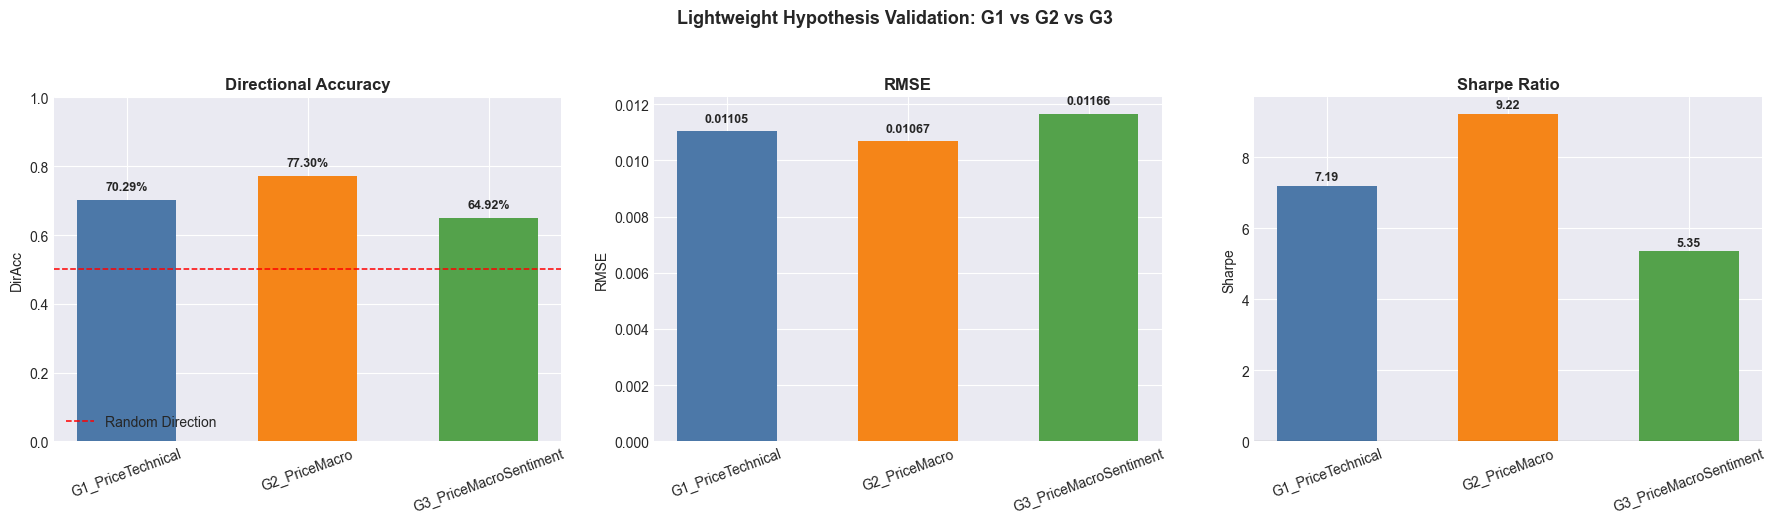

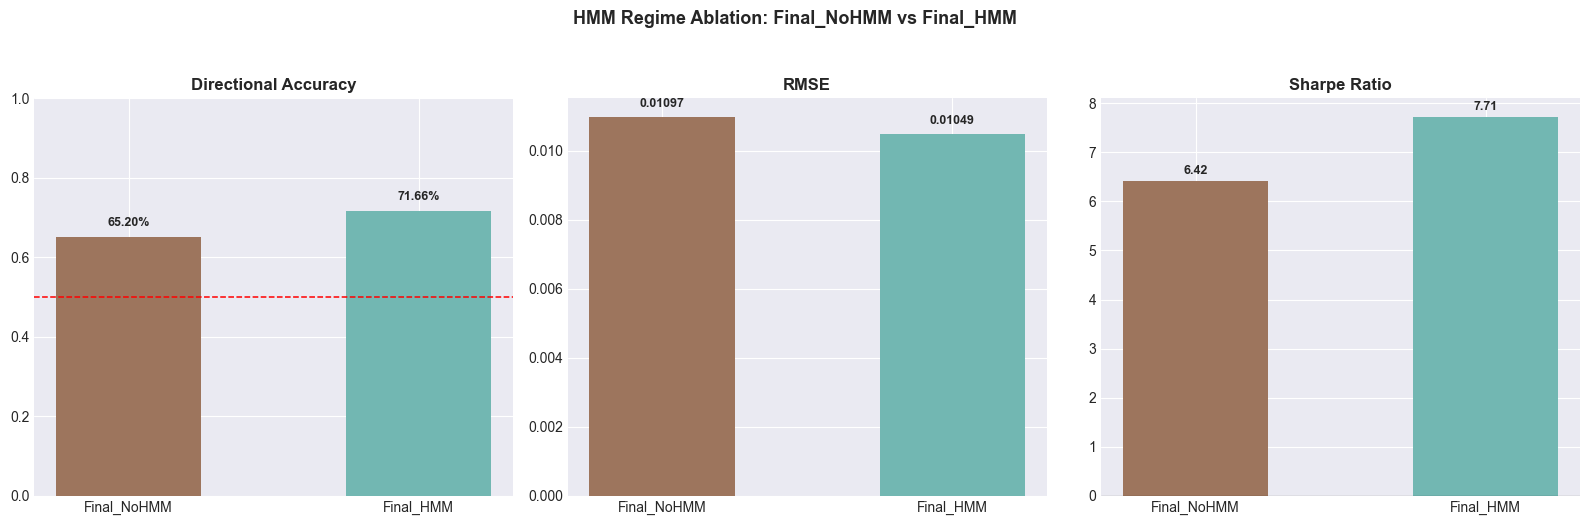

In [28]:
# ── 16b. Plot Lightweight Validation and Ablation Results ─────────────────────
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

# 1. G1/G2/G3 hypothesis validation plots.
g123_plot_df = g123_validation_df.copy()
g123_order = ['G1_PriceTechnical', 'G2_PriceMacro', 'G3_PriceMacroSentiment']
g123_plot_df['Model'] = pd.Categorical(g123_plot_df['Model'], categories=g123_order, ordered=True)
g123_plot_df = g123_plot_df.sort_values('Model')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
g123_colors = ['#4c78a8', '#f58518', '#54a24b']
labels = g123_plot_df['Model'].astype(str).tolist()

bars = axes[0].bar(labels, g123_plot_df['DirAcc'], color=g123_colors, width=0.55)
axes[0].axhline(0.5, color='red', linestyle='--', lw=1.1, label='Random Direction')
axes[0].set_title('Directional Accuracy', fontweight='bold')
axes[0].set_ylabel('DirAcc')
axes[0].set_ylim(0.0, 1.0)
axes[0].tick_params(axis='x', rotation=20)
for bar in bars:
    y = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, y + 0.02, f"{y:.2%}", ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].legend(loc='lower left')

bars = axes[1].bar(labels, g123_plot_df['RMSE'], color=g123_colors, width=0.55)
axes[1].set_title('RMSE', fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=20)
for bar in bars:
    y = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, y + max(abs(y) * 0.02, 1e-4), f"{y:.5f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

bars = axes[2].bar(labels, g123_plot_df['Sharpe'], color=g123_colors, width=0.55)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('Sharpe Ratio', fontweight='bold')
axes[2].set_ylabel('Sharpe')
axes[2].tick_params(axis='x', rotation=20)
for bar in bars:
    y = bar.get_height()
    offset = 0.08 if y >= 0 else -0.14
    axes[2].text(bar.get_x() + bar.get_width()/2, y + offset, f"{y:.2f}", ha='center', va='bottom' if y >= 0 else 'top', fontsize=9, fontweight='bold')

plt.suptitle('Lightweight Hypothesis Validation: G1 vs G2 vs G3', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

# 2. HMM ablation plots.
hmm_plot_df = hmm_ablation_df.copy()
hmm_order = ['Final_NoHMM', 'Final_HMM']
hmm_plot_df['Model'] = pd.Categorical(hmm_plot_df['Model'], categories=hmm_order, ordered=True)
hmm_plot_df = hmm_plot_df.sort_values('Model')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
hmm_colors = ['#9d755d', '#72b7b2']
labels = hmm_plot_df['Model'].astype(str).tolist()

bars = axes[0].bar(labels, hmm_plot_df['DirAcc'], color=hmm_colors, width=0.5)
axes[0].axhline(0.5, color='red', linestyle='--', lw=1.1)
axes[0].set_title('Directional Accuracy', fontweight='bold')
axes[0].set_ylim(0.0, 1.0)
for bar in bars:
    y = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, y + 0.02, f"{y:.2%}", ha='center', va='bottom', fontsize=9, fontweight='bold')

bars = axes[1].bar(labels, hmm_plot_df['RMSE'], color=hmm_colors, width=0.5)
axes[1].set_title('RMSE', fontweight='bold')
for bar in bars:
    y = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, y + max(abs(y) * 0.02, 1e-4), f"{y:.5f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

bars = axes[2].bar(labels, hmm_plot_df['Sharpe'], color=hmm_colors, width=0.5)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('Sharpe Ratio', fontweight='bold')
for bar in bars:
    y = bar.get_height()
    offset = 0.08 if y >= 0 else -0.14
    axes[2].text(bar.get_x() + bar.get_width()/2, y + offset, f"{y:.2f}", ha='center', va='bottom' if y >= 0 else 'top', fontsize=9, fontweight='bold')

plt.suptitle('HMM Regime Ablation: Final_NoHMM vs Final_HMM', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()


### 17.4 · Price Reconstruction & Plots

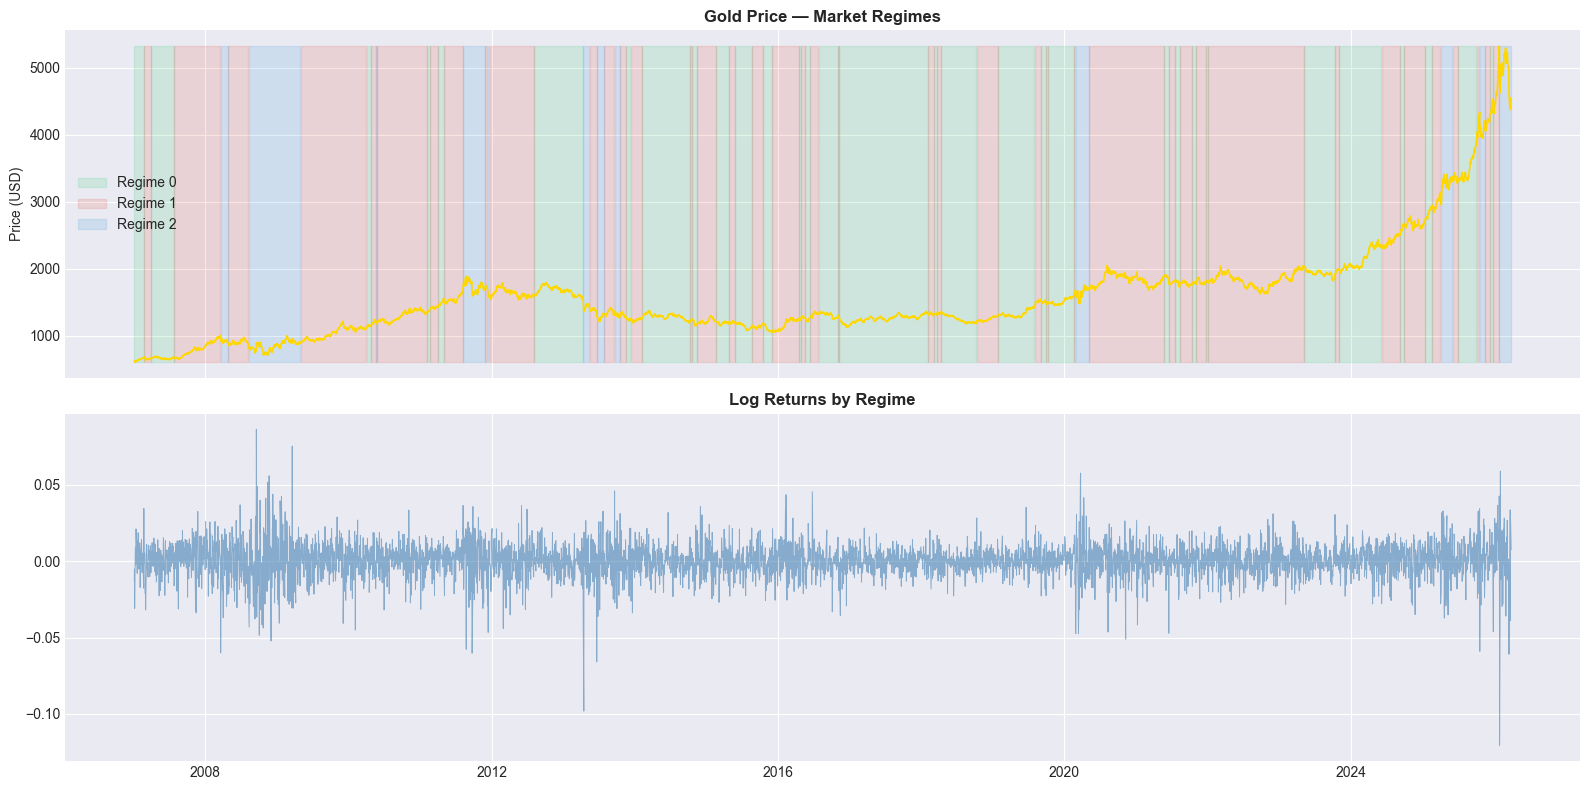

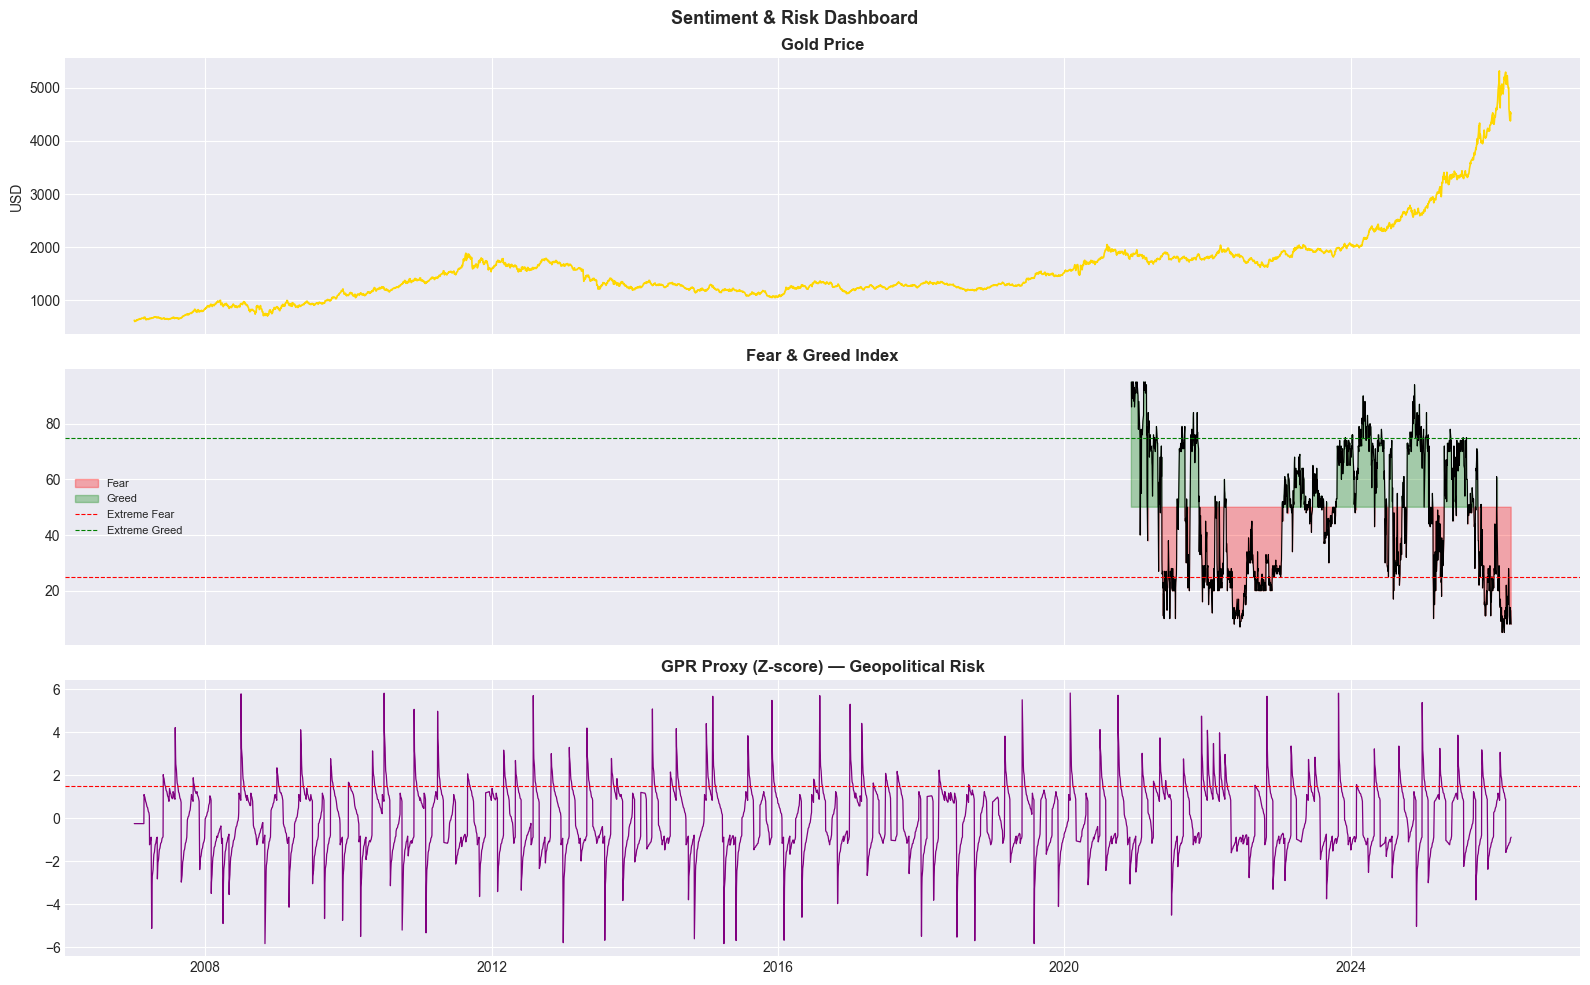

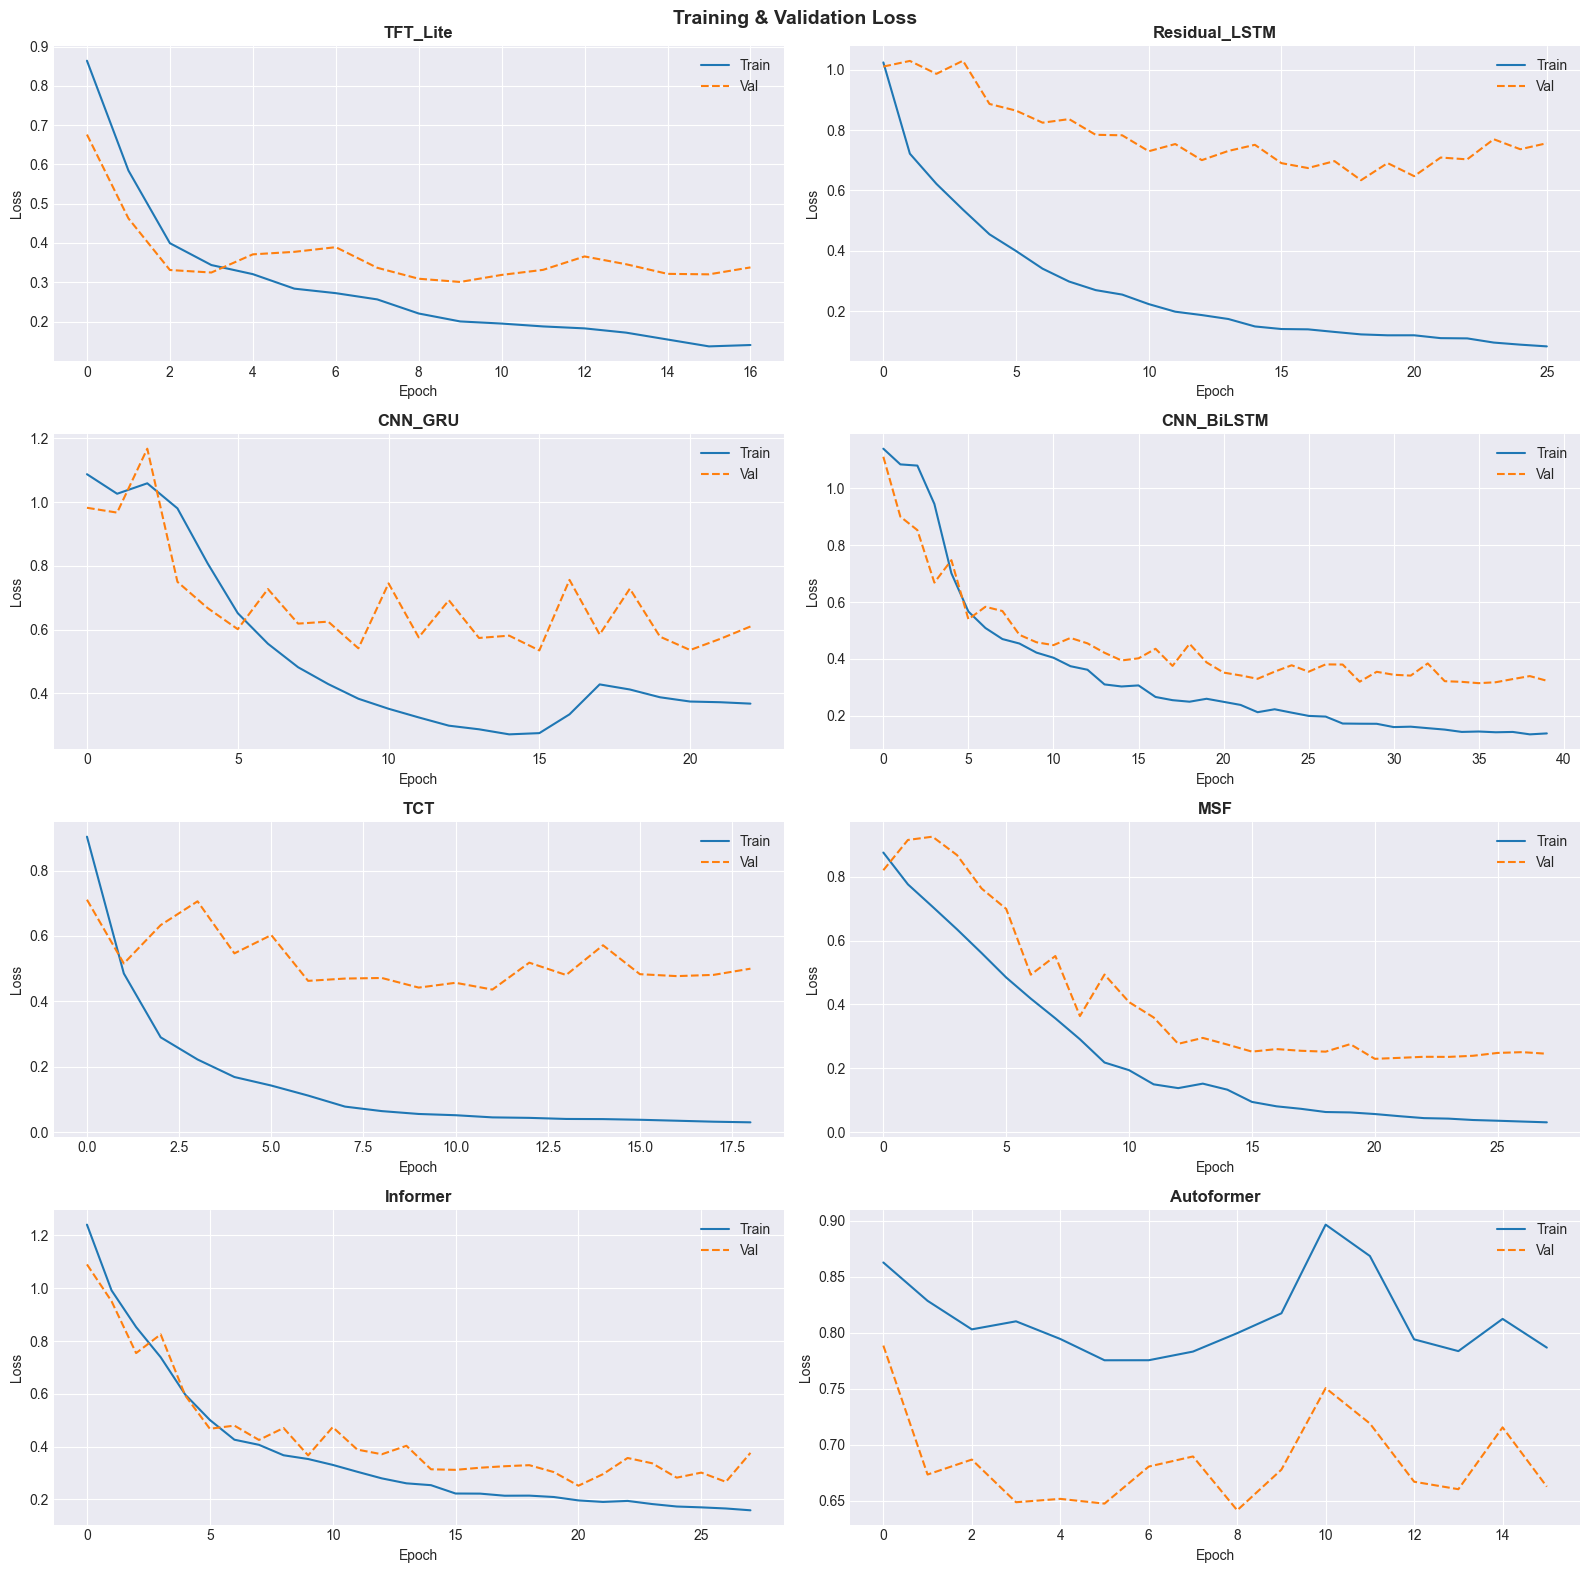

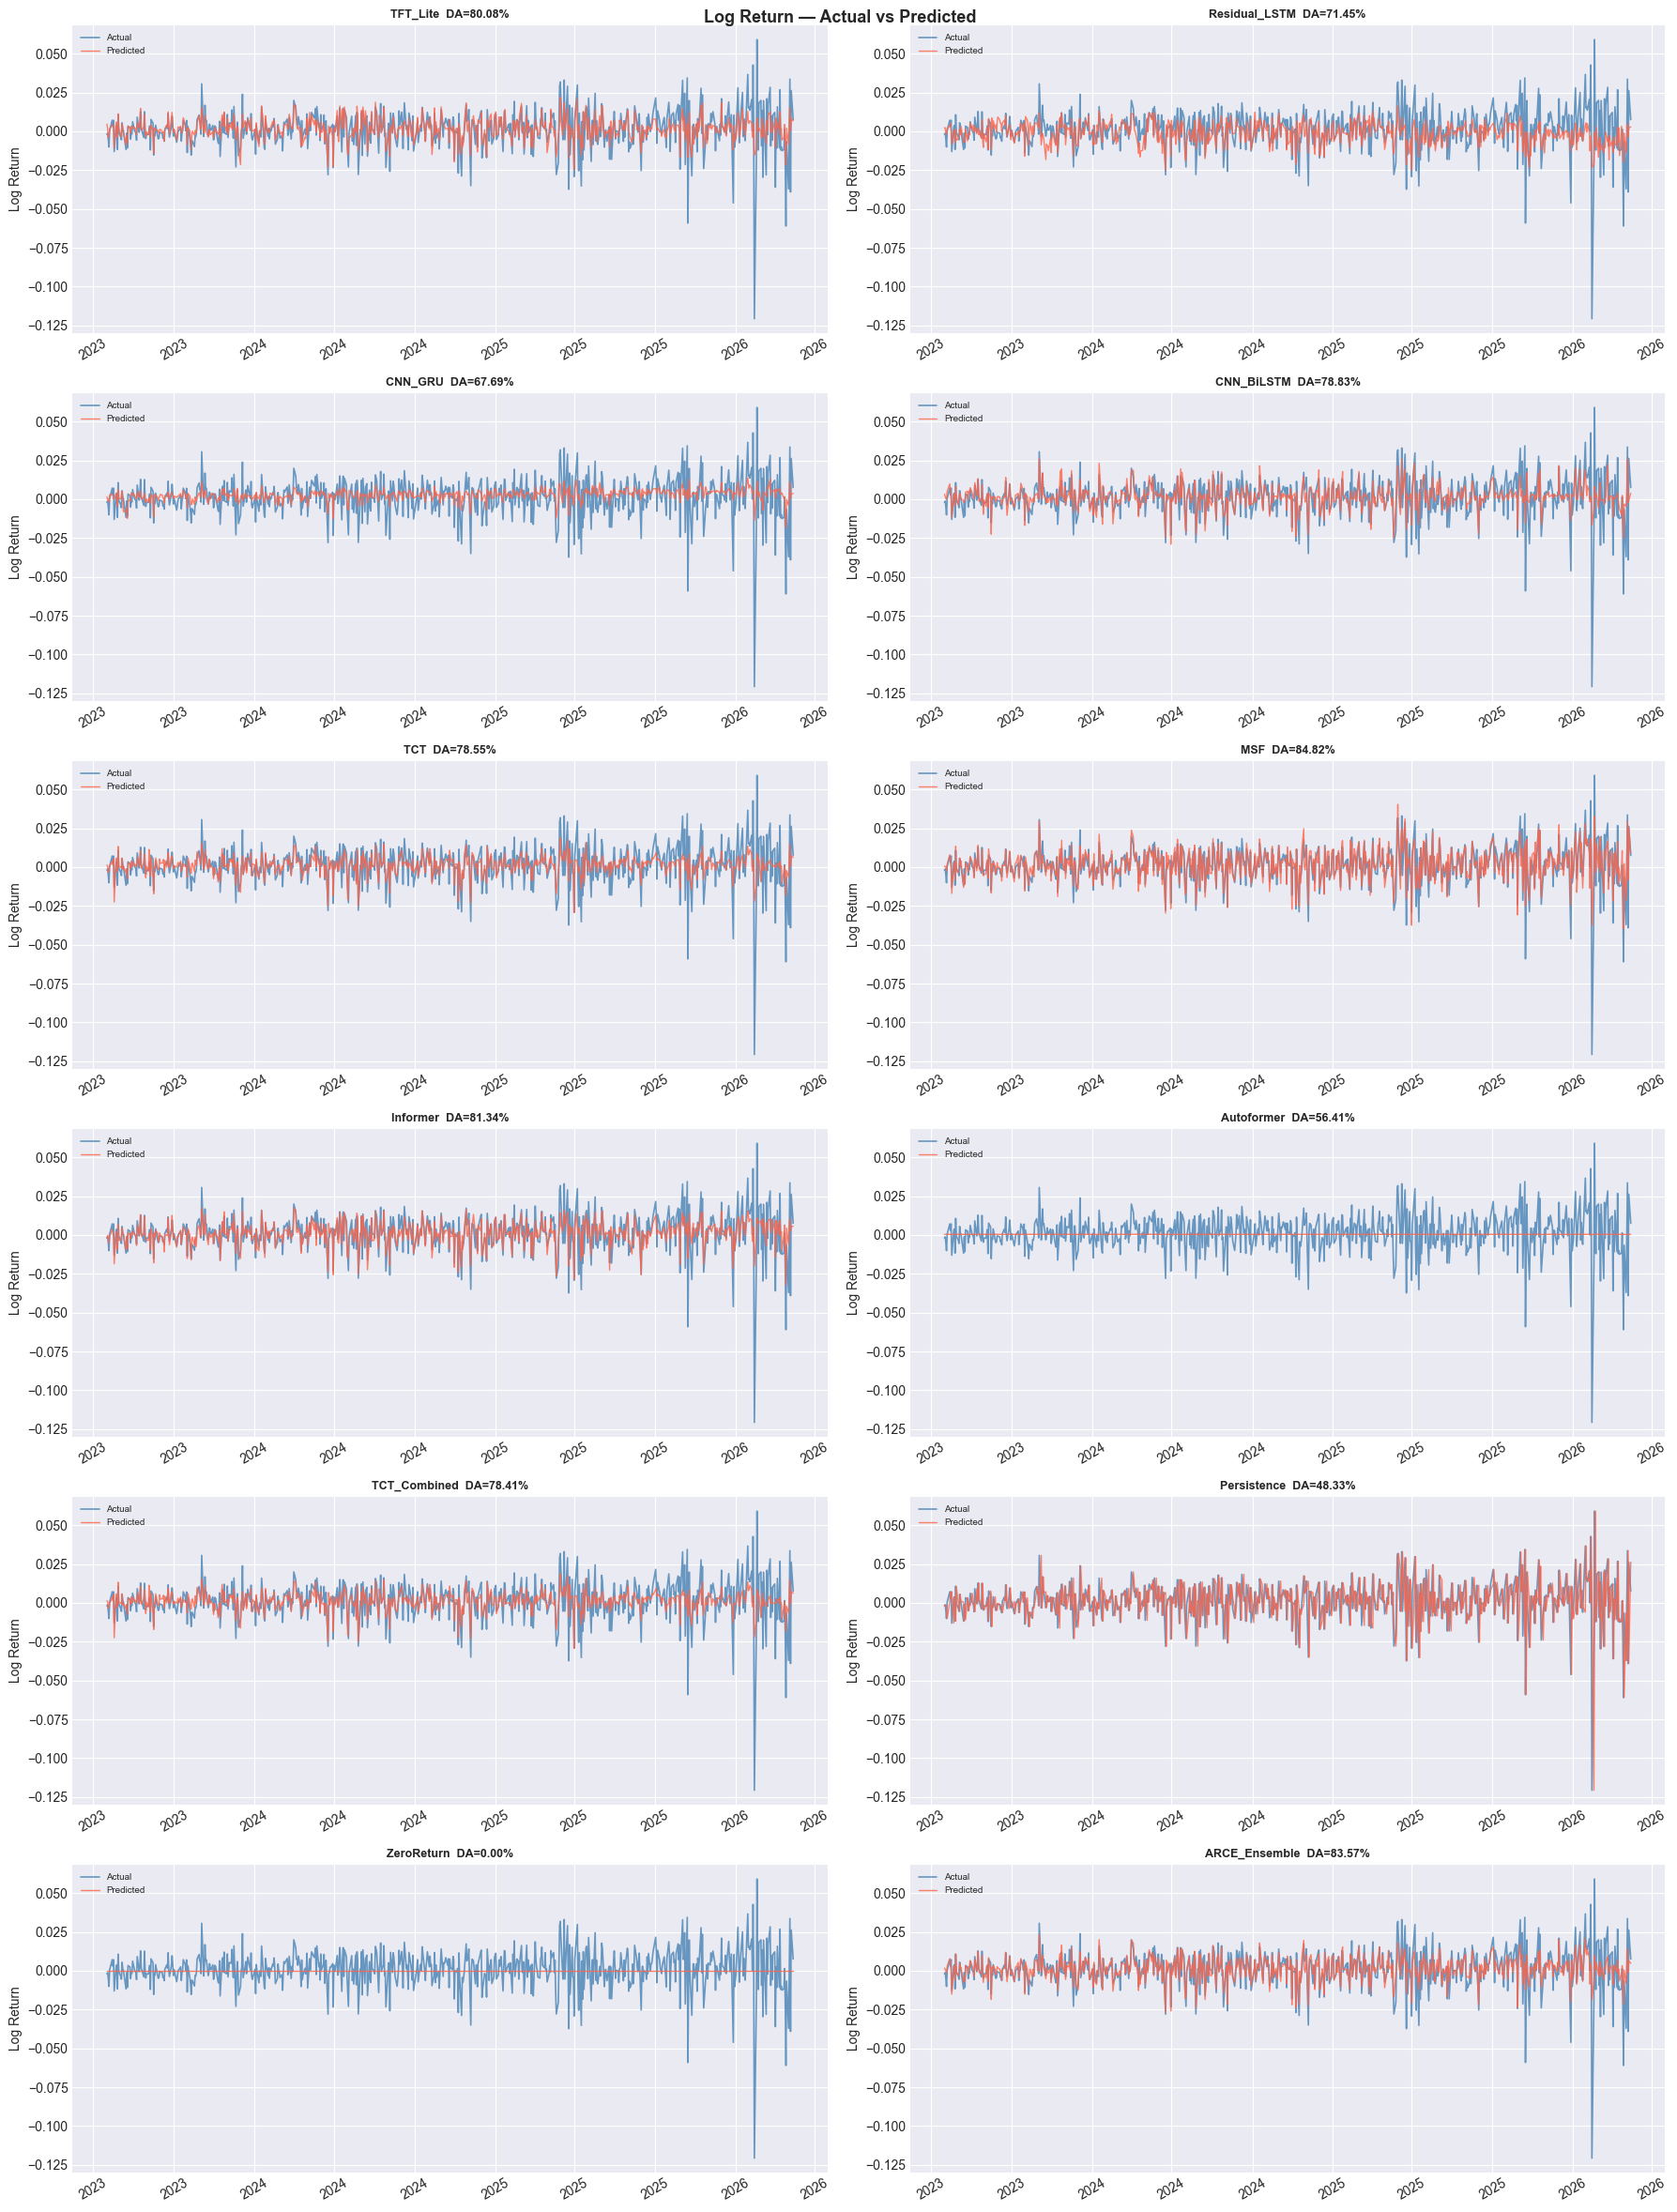

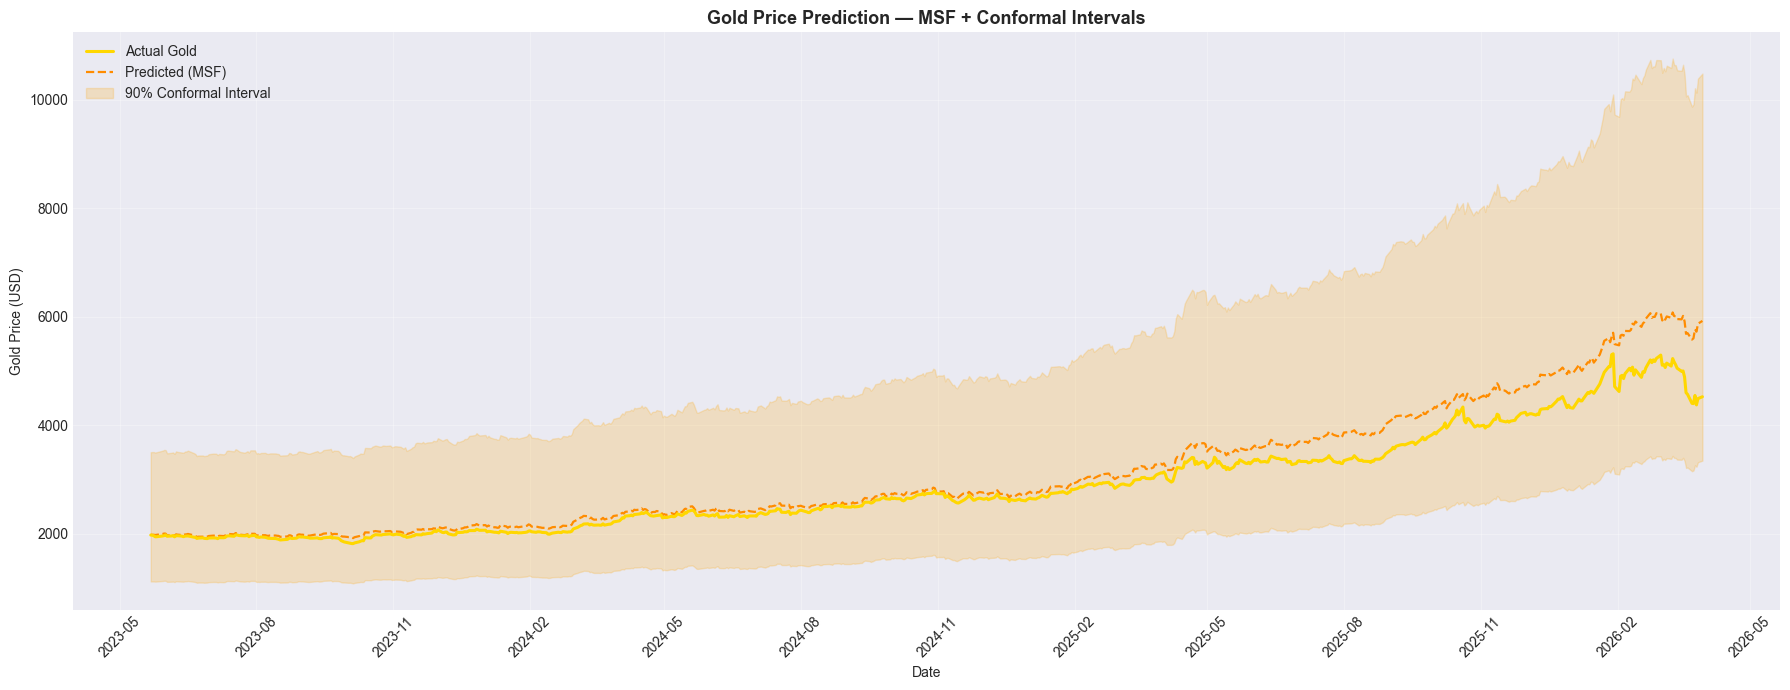

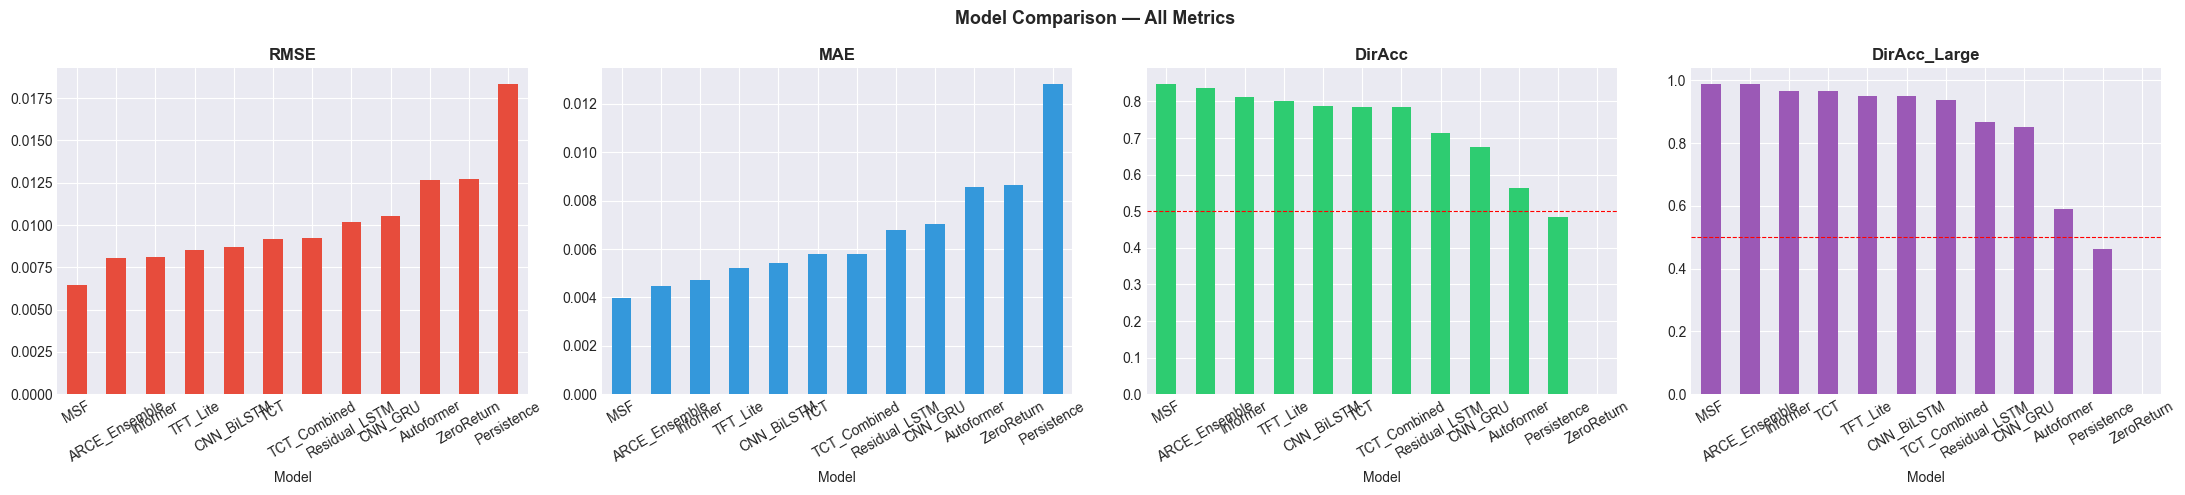

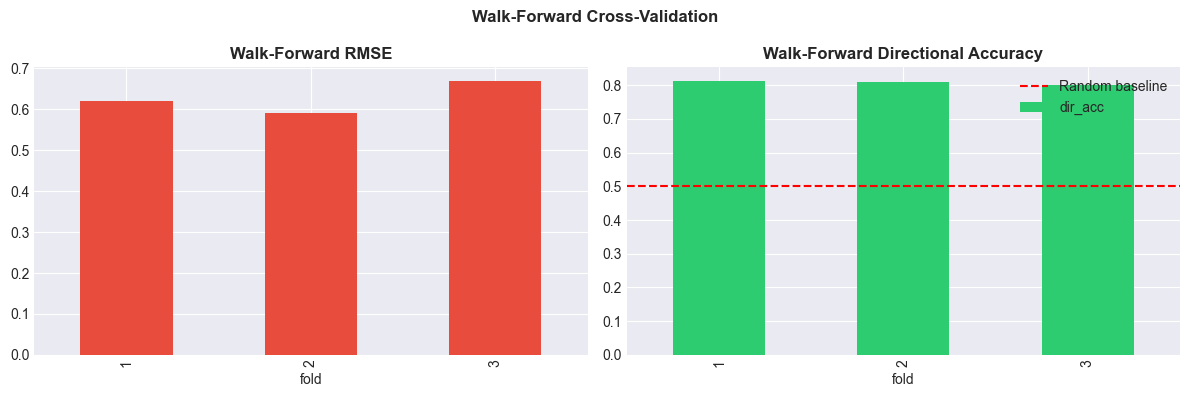

[Plots] All figures displayed inline.


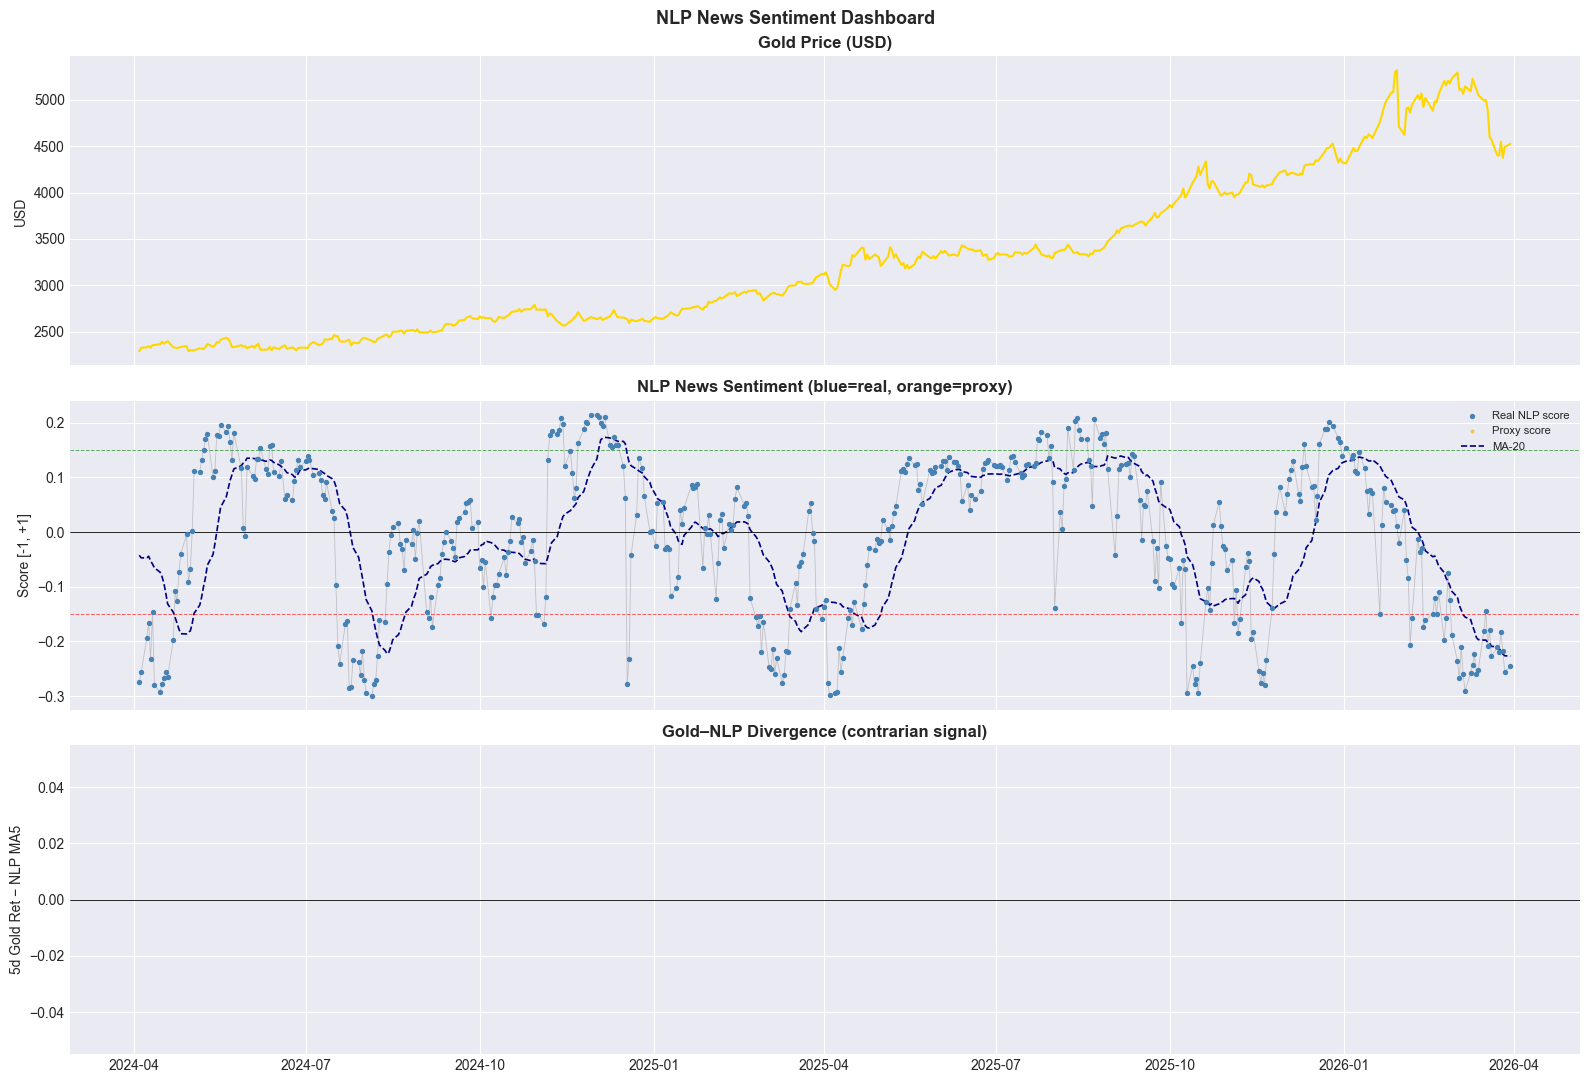

[NLP] Sentiment dashboard plotted.


In [29]:
# ── 13. Price Reconstruction ──────────────────────────────────────
test_start_idx = LOOKBACK + n_train + n_val + HORIZON - 1
test_dates     = df.index[test_start_idx: test_start_idx + len(y_test)]
start_price    = df['Gold_Close'].iloc[test_start_idx - 1]

def lr_to_price(lr_arr, start_p):
        return start_p * np.exp(np.cumsum(lr_arr))

actual_prices = lr_to_price(actuals_inv, start_price)
pred_prices   = {n: lr_to_price(r['preds'], start_price)
                     for n, r in results.items()}

# ── 14. Plots ─────────────────────────────────────────────────────
plot_all(df, results, histories, wf_df, perf_df, conformal,
             test_dates, actual_prices, pred_prices, top_features,
             actuals_inv, best_name, trained_models)

# ── 14b. NLP Sentiment Plot
plot_nlp_sentiment(df, last_n_days=500)

### 17.5 · Save Results


STATISTICAL TESTS SUMMARY
                 Model   N   DirAcc       BinomP BinomSig DM_Benchmark       DM         DM_p DM_Sig         PT         PT_p PT_Sig      t_ret_p t_ret_Sig     Sharpe_p Sharpe_Sig
              TFT_Lite 718 0.800836 1.700123e-62      ***          MSF 3.232899 1.225408e-03    ***  14.693013 0.000000e+00    *** 6.642057e-61       *** 3.240042e-46        ***
         Residual_LSTM 718 0.714485 1.246324e-31      ***          MSF 5.094797 3.491153e-07    ***  11.612094 0.000000e+00    *** 3.751319e-34       *** 2.820957e-36        ***
               CNN_GRU 718 0.676880 6.932220e-22      ***          MSF 5.748100 9.025190e-09    ***   5.801215 6.583599e-09    *** 8.193947e-30       *** 5.978425e-25        ***
            CNN_BiLSTM 718 0.788301 3.310807e-57      ***          MSF 3.336543 8.482739e-04    ***  13.654561 0.000000e+00    *** 1.984276e-58       *** 3.175696e-41        ***
                   TCT 718 0.785515 4.521066e-56      ***          MSF 4.390910 1.1

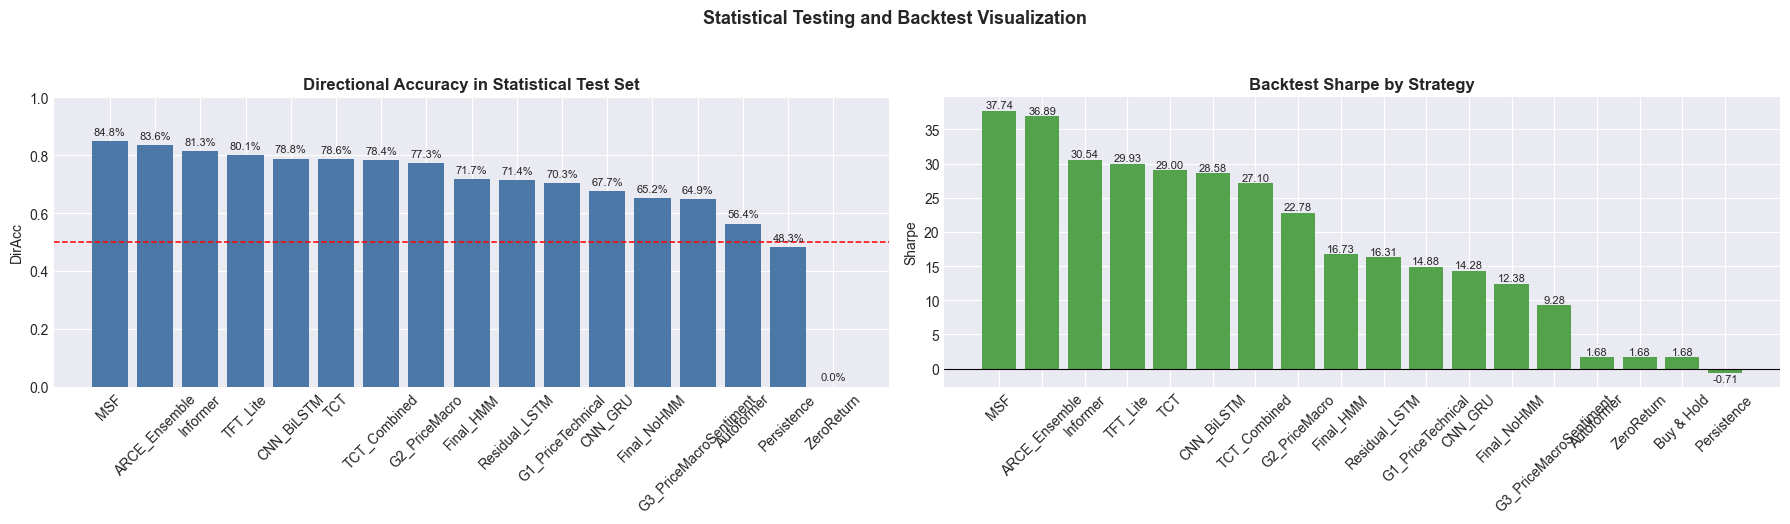

In [30]:
# ── 17. Statistical Significance Tests + Backtest + Save Results ──
from scipy import stats as scipy_stats

def newey_west_se(x, lags=10):
    """Heteroskedasticity & autocorrelation consistent (HAC) SE."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n == 0:
        return np.nan
    mu = x.mean()
    e = x - mu
    var = np.dot(e, e) / n
    for lag in range(1, min(lags, n - 1) + 1):
        w = 1 - lag / (lags + 1)
        cov_lag = np.dot(e[lag:], e[:-lag]) / n
        var += 2 * w * cov_lag
    return np.sqrt(max(var, 1e-12) / n)

def diebold_mariano(e_model, e_benchmark):
    """H0: equal predictive accuracy based on squared-error loss."""
    e_model = np.asarray(e_model, dtype=float)
    e_benchmark = np.asarray(e_benchmark, dtype=float)
    n = min(len(e_model), len(e_benchmark))
    d = np.square(e_model[-n:]) - np.square(e_benchmark[-n:])
    se = newey_west_se(d, lags=int(np.ceil(n ** (1/3))))
    dm_stat = d.mean() / (se + 1e-12)
    p_val = 2 * scipy_stats.norm.sf(abs(dm_stat))
    return float(dm_stat), float(p_val)

def pesaran_timmermann(y_true, y_pred):
    """PT market-timing test for directional forecasting skill."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    n = min(len(y_true), len(y_pred))
    y_true = y_true[-n:]
    y_pred = y_pred[-n:]
    hit = (np.sign(y_true) == np.sign(y_pred)).astype(float)
    p = hit.mean()
    py = np.mean(y_true > 0)
    pp = np.mean(y_pred > 0)
    p_star = py * pp + (1 - py) * (1 - pp)
    v_star = (py * (1 - py) * (1 - 2 * pp) ** 2 + pp * (1 - pp) * (1 - 2 * py) ** 2) / max(n, 1)
    v = p_star * (1 - p_star) / max(n, 1)
    stat = (p - p_star) / np.sqrt(max(v + v_star, 1e-12))
    p_val = 2 * (1 - scipy_stats.norm.cdf(abs(stat)))
    return float(stat), float(p_val)

def sig_star(p):
    if p < 0.01:
        return '***'
    if p < 0.05:
        return '**'
    if p < 0.10:
        return '*'
    return ''

def backtest_metrics(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    n = min(len(y_true), len(y_pred))
    y_true = y_true[-n:]
    y_pred = y_pred[-n:]
    signal = np.sign(y_pred)
    signal[signal == 0] = 1
    strat_ret = signal * y_true
    cum_ret = np.exp(np.sum(strat_ret)) - 1
    ann_ret = np.exp(np.mean(strat_ret) * 252) - 1
    ann_vol = np.std(strat_ret, ddof=1) * np.sqrt(252) if n > 1 else np.nan
    sharpe = ann_ret / ann_vol if ann_vol and ann_vol > 0 else np.nan
    equity = np.exp(np.cumsum(strat_ret))
    running_max = np.maximum.accumulate(equity)
    max_dd = np.min((equity - running_max) / running_max) if len(equity) else np.nan
    calmar = ann_ret / abs(max_dd) if max_dd and max_dd < 0 else np.nan
    return {
        'Strategy': label,
        'Cum_Return': cum_ret,
        'Ann_Return': ann_ret,
        'Ann_Vol': ann_vol,
        'Sharpe': sharpe,
        'Max_Drawdown': max_dd,
        'Calmar': calmar,
        'N': n,
    }

# Main-model statistical tests against the best-by-RMSE individual model.
all_prediction_sets = {k: v for k, v in results.items()}
all_prediction_sets.update(globals().get('validation_prediction_sets', {}))

main_benchmark_name = best_by_rmse if 'best_by_rmse' in globals() else min(
    results, key=lambda n: np.sqrt(mean_squared_error(results[n]['actuals'], results[n]['preds']))
)
e_benchmark = results[main_benchmark_name]['actuals'] - results[main_benchmark_name]['preds']

stat_rows = []
print("\n" + "="*90)
print("STATISTICAL TESTS SUMMARY")
print("="*90)
for model_name, res in all_prediction_sets.items():
    try:
        actuals_i = np.asarray(res['actuals'])
        preds_i = np.asarray(res['preds'])
        n = min(len(actuals_i), len(preds_i))
        actuals_i = actuals_i[-n:]
        preds_i = preds_i[-n:]
        errors_i = actuals_i - preds_i
        correct = np.sign(preds_i) == np.sign(actuals_i)
        n_correct = int(correct.sum())
        binom_p = scipy_stats.binomtest(n_correct, n, 0.5, alternative='greater').pvalue
        dm_stat, dm_p = diebold_mariano(errors_i, e_benchmark)
        pt_stat, pt_p = pesaran_timmermann(actuals_i, preds_i)
        strat_ret = np.sign(preds_i) * actuals_i
        strat_ret[np.sign(preds_i) == 0] = actuals_i[np.sign(preds_i) == 0]
        t_stat, t_two = scipy_stats.ttest_1samp(strat_ret, 0.0)
        t_ret_p = t_two / 2 if t_stat > 0 else 1.0
        nw_se = newey_west_se(strat_ret, lags=10)
        sharpe_t = strat_ret.mean() / (nw_se + 1e-12)
        sharpe_p = float(scipy_stats.norm.sf(sharpe_t))
        stat_rows.append({
            'Model': model_name,
            'N': n,
            'DirAcc': n_correct / n,
            'BinomP': binom_p,
            'BinomSig': sig_star(binom_p),
            'DM_Benchmark': main_benchmark_name,
            'DM': dm_stat,
            'DM_p': dm_p,
            'DM_Sig': sig_star(dm_p),
            'PT': pt_stat,
            'PT_p': pt_p,
            'PT_Sig': sig_star(pt_p),
            't_ret_p': t_ret_p,
            't_ret_Sig': sig_star(t_ret_p),
            'Sharpe_p': sharpe_p,
            'Sharpe_Sig': sig_star(sharpe_p),
        })
    except Exception as exc:
        stat_rows.append({'Model': model_name, 'Error': str(exc)})

statistical_tests_df = pd.DataFrame(stat_rows)
print(statistical_tests_df.to_string(index=False))
statistical_tests_df.to_csv('statistical_tests_summary.csv', index=False)

# Backtest table: main models + validation models + buy-and-hold.
backtest_rows = []
if len(actuals_inv):
    backtest_rows.append(backtest_metrics(actuals_inv, np.ones_like(actuals_inv), 'Buy & Hold'))

for model_name, res in all_prediction_sets.items():
    try:
        backtest_rows.append(backtest_metrics(res['actuals'], res['preds'], model_name))
    except Exception as exc:
        print(f"[Backtest warning] {model_name}: {exc}")

backtest_df = pd.DataFrame(backtest_rows)
print("\n" + "="*90)
print("BACKTEST RESULTS")
print("="*90)
print(backtest_df.to_string(index=False))
backtest_df.to_csv('backtest_results.csv', index=False)

# Final compact performance table.
display_cols = ['Model', 'RMSE', 'MAE', 'DirAcc', 'DirAcc_Large', 'DirAcc_RW',
                'IC_Pearson', 'IC_Spearman', 'Q5_Q1_Spread',
                'Sharpe', 'MaxDD', 'Calmar']
display_cols = [c for c in display_cols if c in perf_df.columns]
perf_df[display_cols].to_csv('results_summary.csv', index=False)

print("\n[Saved outputs]")
print("  results_summary.csv")
print("  statistical_tests_summary.csv")
print("  backtest_results.csv")
print("  G1_G2_G3_validation_results.csv")
print("  hmm_ablation_results.csv")
print(f"\nBest by DirAcc : {best_by_diracc}")
print(f"Best by RMSE   : {best_by_rmse}")
print(f"Best by Sharpe : {best_by_sharpe}")


# ── 17b. Visualize statistical tests and backtest results ─────────────────────
try:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    stat_plot_df = statistical_tests_df.copy()
    stat_plot_df = stat_plot_df[pd.to_numeric(stat_plot_df.get('DirAcc'), errors='coerce').notna()].copy()
    stat_plot_df['DirAcc'] = pd.to_numeric(stat_plot_df['DirAcc'], errors='coerce')
    stat_plot_df = stat_plot_df.sort_values('DirAcc', ascending=False)
    bars = axes[0].bar(stat_plot_df['Model'], stat_plot_df['DirAcc'], color='#4c78a8')
    axes[0].axhline(0.5, color='red', linestyle='--', lw=1.1)
    axes[0].set_title('Directional Accuracy in Statistical Test Set', fontweight='bold')
    axes[0].set_ylabel('DirAcc')
    axes[0].set_ylim(0.0, 1.0)
    axes[0].tick_params(axis='x', rotation=45)
    for bar in bars:
        y = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, y + 0.015, f"{y:.1%}", ha='center', va='bottom', fontsize=8)

    sharpe_plot_df = backtest_df.copy()
    sharpe_plot_df = sharpe_plot_df[pd.to_numeric(sharpe_plot_df.get('Sharpe'), errors='coerce').notna()].copy()
    sharpe_plot_df['Sharpe'] = pd.to_numeric(sharpe_plot_df['Sharpe'], errors='coerce')
    sharpe_plot_df = sharpe_plot_df.sort_values('Sharpe', ascending=False)
    bars = axes[1].bar(sharpe_plot_df['Strategy'], sharpe_plot_df['Sharpe'], color='#54a24b')
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title('Backtest Sharpe by Strategy', fontweight='bold')
    axes[1].set_ylabel('Sharpe')
    axes[1].tick_params(axis='x', rotation=45)
    for bar in bars:
        y = bar.get_height()
        offset = 0.08 if y >= 0 else -0.14
        axes[1].text(bar.get_x() + bar.get_width()/2, y + offset, f"{y:.2f}", ha='center', va='bottom' if y >= 0 else 'top', fontsize=8)

    plt.suptitle('Statistical Testing and Backtest Visualization', fontsize=13, fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"[Plot warning] Statistical/backtest visualization skipped: {exc}")


---
## §19 · Final Discussion

This final pipeline uses a runtime-controlled high-capacity model set with CNN/RNN, attention, multi-scale, and transformer-inspired architectures for a complete architecture comparison. The main walk-forward stage therefore evaluates `TFT_Lite`, `Residual_LSTM`, `CNN_GRU`, `CNN_BiLSTM`, `TCT`, `MSF`, `Informer`, and `Autoformer` under the same data split and training protocol. The primary results should still be reported with complementary rankings because the best model by directional accuracy, RMSE, and Sharpe may differ.

The lightweight validation section tests the main feature-group hypotheses. `G1` tests whether price/technical features alone are sufficient, `G2` adds macro/geopolitical/cross-asset information, and `G3` adds the broader sentiment/behavioral block including NLP/FearGreed-style variables and positioning or demand variables such as COT and central-bank reserve features. These comparisons are run with a single lightweight `Residual_LSTM` so that the validation is rigorous but does not dominate runtime.

The HMM ablation separately compares `Final_NoHMM` against `Final_HMM`, avoiding a full expensive experiment matrix while still testing whether explicit regime information improves the final model. Statistical tests and sign-based backtests are then applied to the main models and validation models, with tables and visualizations saved/displayed for easier interpretation.

Together, this notebook combines broad macro/behavioral input coverage, an eight-model comparison, G1/G2/G3 hypothesis validation, HMM ablation, statistical testing, backtesting, and a reproducible setup.
